# Exercise 3: Time series with ARIMA

## Do not start the exercise until you fully understand the submission guidelines.

- The homework assignments are executed automatically.
- Failure to comply with the following instructions will result in a significant penalty.
- Appeals regarding your failure to read these instructions will be denied.
- Kind reminder: the homework assignments contribute 60% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your ID as the file name. For example, `hw1_123456789_987654321.zip` if you submitted in pairs and `hw1_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.

Please use only a **zip** file in your submission.

---

---

## Please sign that you have read and understood the instructions:

316492776
318900016

---

---


In [1]:
!pip3 install statsmodels
!pip3 install seaborn
!pip3 install numpy
!pip3 install pandas
!pip3 install tqdm
!pip3 install scikit-learn
!pip3 install yfinance

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
sns.set_theme()
np.random.seed(42)

# Design your algorithm

Make sure to describe the algorithm, its limitations, and describe use-cases.


# Your implementations

You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.


In [26]:
class ARMACustom:
    def __init__(self, X: np.ndarray, order: tuple = (None, None, None), verbose: bool = True, ac_thresh: float = 0.1):
        self.verbose = verbose
        self.ac_thresh = ac_thresh
        self.X = X
        self.order = order
        self.set_params()

    def set_params(self):
        self.p, self.q = self.order

    def fit(self) -> None:
        self.find_p()
        self.find_q()
        self.fit_AR()
        self.fit_MA()

    def find_p(self) -> None:
        if self.p:
            return None
        X_pacf = pacf(self.X)
        p = np.argmax(np.abs(X_pacf) < self.ac_thresh)
        if self.verbose:
            print(f"p: {p}")
            print(f"pacf: {X_pacf}")
        assert 0 < p < len(self.X), "Cannot fit AR model to the given data"
        self.p = p

    def find_q(self) -> None:
        if self.q:
            return None
        X_acf = acf(self.X)
        q = np.argmax(np.abs(X_acf) < self.ac_thresh)
        if self.verbose:
            print(f"q: {q}")
            print(f"acf: {X_acf}")
        assert 0 < q < len(self.X), "Cannot fit MA model to the given data"
        self.q = q

    def fit_AR(self) -> None:
        data = np.vstack([self.X[i-self.p:i] for i in range(self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.p: len(self.X)])
        self.phi_ = reg.coef_

    def fit_MA(self) -> None:
        w = np.zeros(len(self.X))
        for i in range(self.p, len(self.X)):
            ar = (self.phi_ * self.X[i-self.p:i]).sum()
            w[i] = self.X[i] - ar
        # we start from p+q since it is the first index that allows full derivation of errors looking back in time
        data = np.vstack([w[i-self.q:i] for i in range(self.q + self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.q + self.p: len(self.X)])
        self.theta_ = reg.coef_
    
    def forecast(self, steps: int) -> np.ndarray:
        n = len(self.X)
        preds = np.concatenate([self.X, np.zeros(steps)])
        noise_preds = np.zeros_like(preds) # same size for vectorization
        for i in range(n - self.p, n + steps): # we go back p steps to estimate the noise
        # for i in range(self.q+ self.p, n + steps): # we go back p steps to estimate the noise
            ar = (self.phi_ * preds[i-self.p:i]).sum()
            ma = (self.theta_ * noise_preds[i-self.q:i]).sum()
            if i >= n:
                preds[i] = ar + ma  # we change only future indexes
            else:
                noise_preds[i] = preds[i] - ar - ma # will be 0 for new indexes, since we don't know X[i] for i >= n
        return preds[n:] 



class ARIMACustom(ARMACustom):
    def __init__(self, X: np.ndarray, order: tuple = (None, None, None), verbose = True, ac_thresh: float = 0.1, stationarity_conf: float = 0.05):
        super().__init__(X, order, verbose, ac_thresh)
        self.stationarity_conf = stationarity_conf

    
    def set_params(self):
        self.p, self.d, self.q = self.order

    def find_d(self) -> None:
        if self.d:
            return None
        for d in [0,1,2]: # no more than a second derivative
            p_val = adfuller(np.diff(self.X, d))[1] # p-value
            if p_val < self.stationarity_conf:
                if self.verbose:
                    print(f"d: {d}")
                self.d = d
                return None
        raise Exception("Data is not stationary, even after differentiating twice")
    
    def fit_I(self) -> None:
        self.Z = self.X # to maintain inheritance
        self.X = np.diff(self.X, self.d)
    
    def fit(self) -> None:
        self.find_d()
        self.fit_I()
        super().fit()

    def forecast(self, steps: int) -> np.ndarray:
        return super().forecast(steps).cumsum() + self.Z[-1]

# Generate data

Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.


For the data generation. We chose to use the IRIS dataset
The IRIS Flower dataset is a well known dataset that works well with boosting algorithms, easy to classify and it contains 4 features:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

And 3 classes (labels): Setosa, Versicolor, Virginica that marked as 0, 1, 2

For sampling our implementation, we disabled one of the classes of IRIS in order to handle a binary-labeled dataset


In [27]:
path = './sample_dataset.csv'

sample_dataset = pd.read_csv(path)

sample_dataset.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [28]:
X = sample_dataset["value"].values
a = ARIMACustom(X)

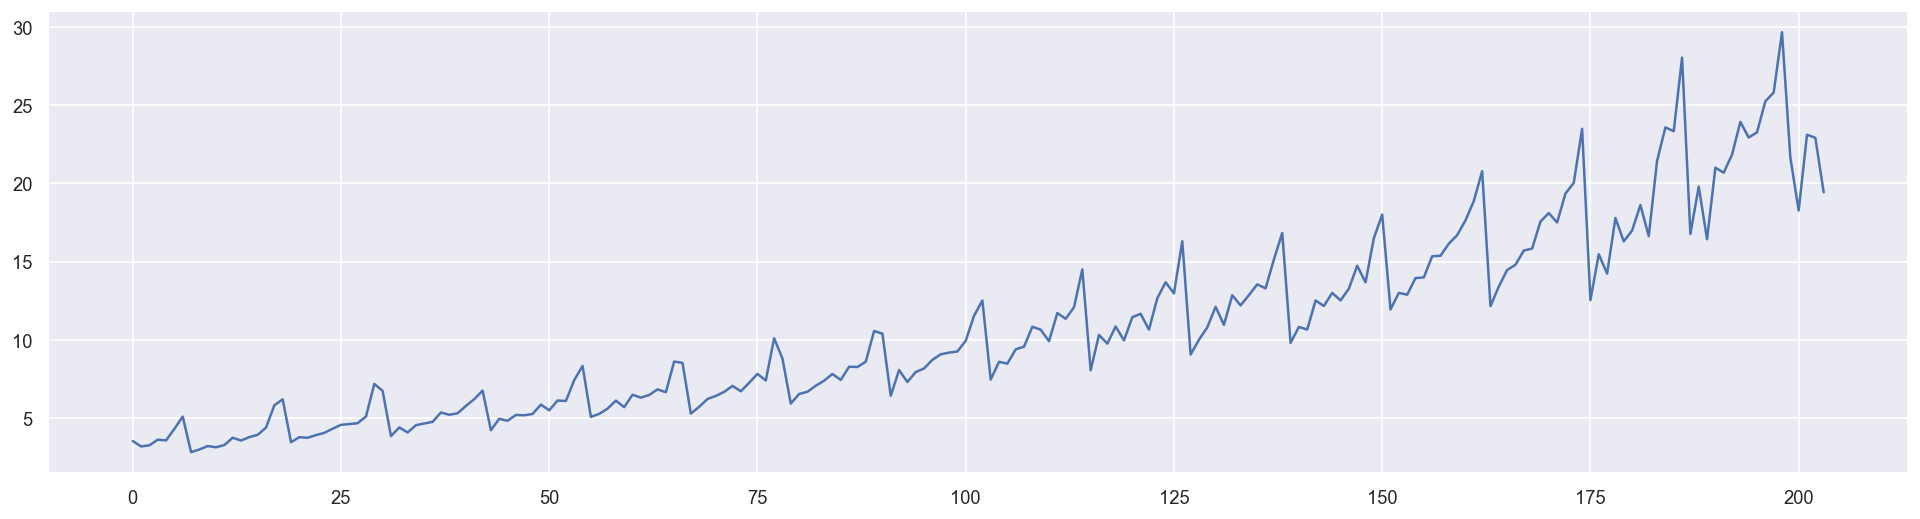

In [29]:
plt.plot(X)

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


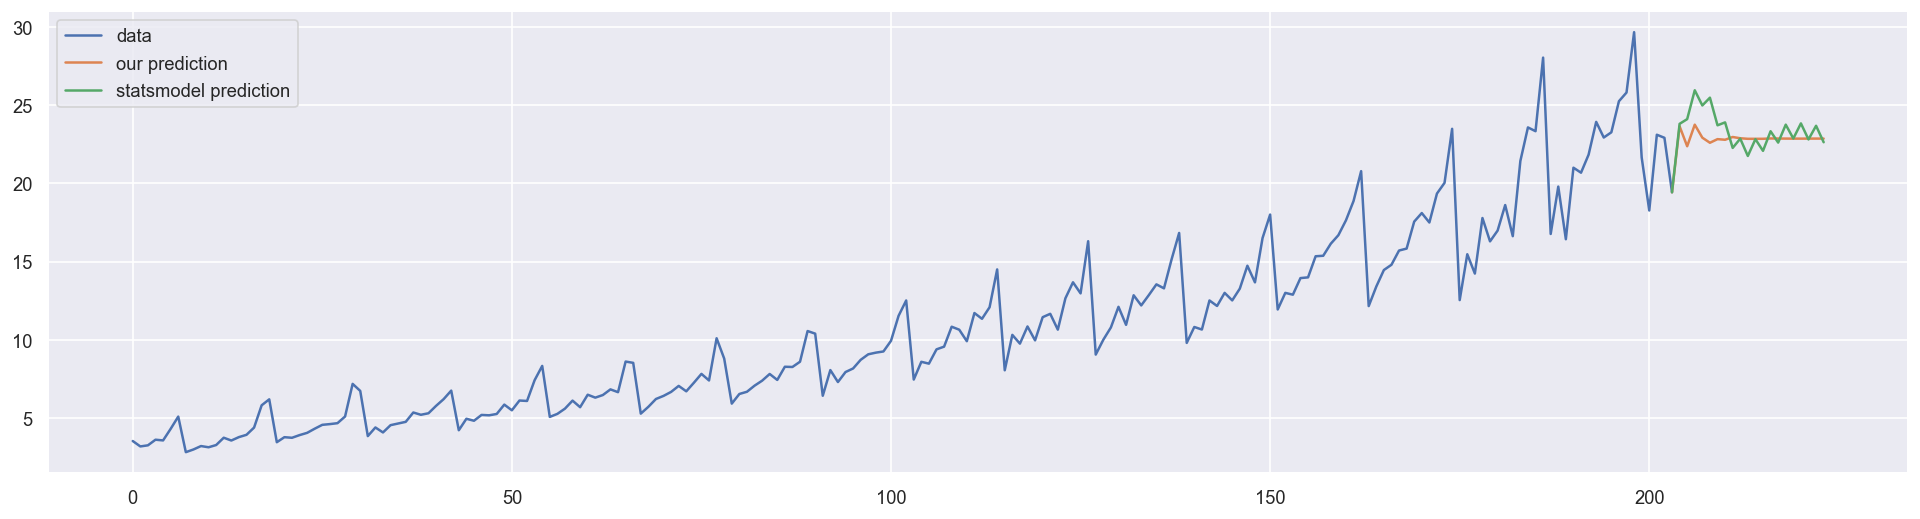

In [30]:
# our_model = ARIMACustom(X)
our_model = ARIMACustom(X, order=(4,1,3))
our_model.fit()
statsmodel_model = ARIMA(X, order=(our_model.p, our_model.d, our_model.q))
statsmodel_model = statsmodel_model.fit()
steps = 20

our_forecast = our_model.forecast(steps)
statsmodel_forecast = statsmodel_model.get_forecast(steps).predicted_mean
plt.plot(X, label="data")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(our_forecast, 0, X[-1]), label="our prediction")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(statsmodel_forecast, 0, X[-1]), label="statsmodel prediction")
plt.legend()

In [31]:
model = ARIMA(X, order=(8,2,3))
model_fit = model.fit()
steps = 20

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [32]:
model_fit.params

array([-1.15190341, -1.43305966, -0.95591579, -0.76443298, -0.63646882,
       -0.54289551, -0.46903398, -0.33631475, -0.30395726,  0.24378543,
       -0.93038149,  3.16903245])

In [33]:
Y = np.diff(X, 1)

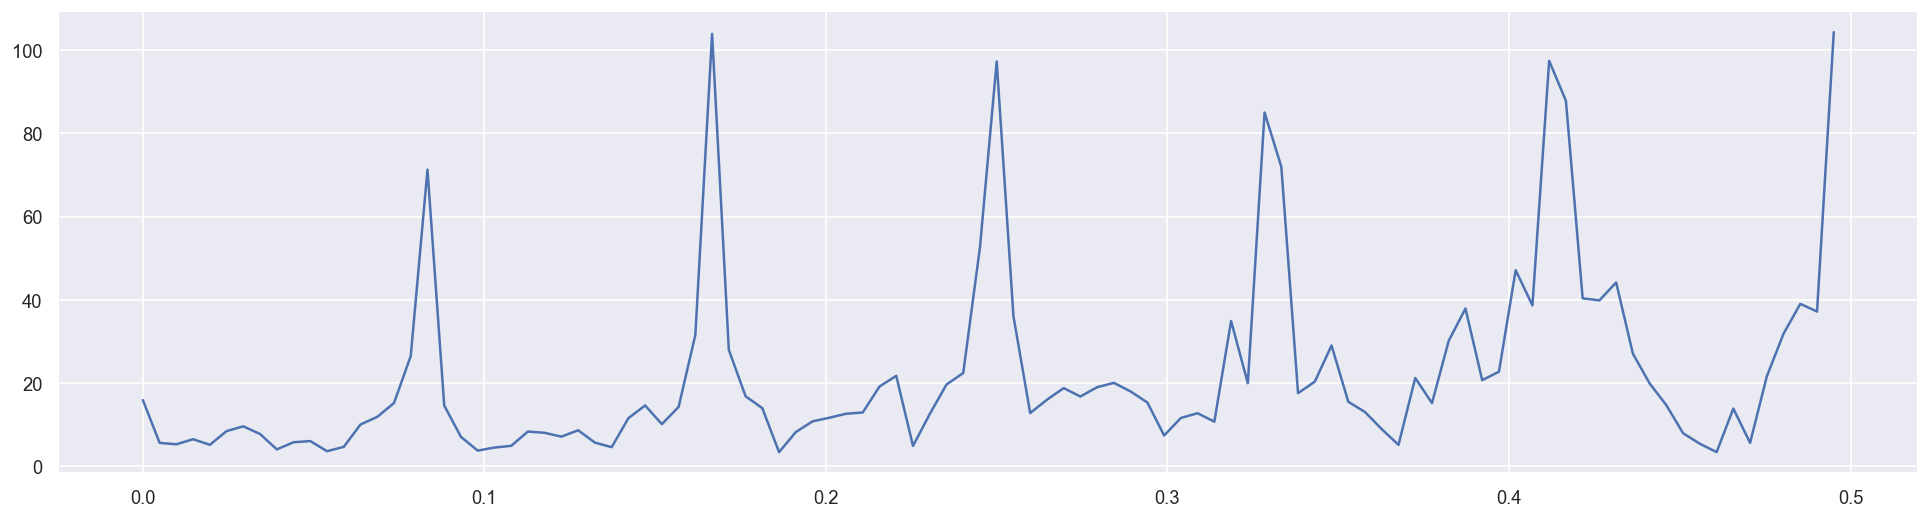

In [34]:
import numpy as np
from scipy.fftpack import fft

n = len(X)
freqs = np.fft.fftfreq(n)
fft_values = np.abs(fft(np.diff(X,1)))

plt.plot(freqs[:n//2], fft_values[:n//2])  # Plot only positive frequencies
plt.show()

In [35]:
fft_values[:n//2]

array([ 15.905149  ,   5.63352294,   5.28814947,   6.50914796,
         5.164294  ,   8.45616801,   9.60479997,   7.75813759,
         4.06930965,   5.77636183,   6.0661944 ,   3.62343095,
         4.68067989,  10.04528239,  11.87429769,  15.19894268,
        26.49989657,  71.25420541,  14.59926585,   7.06192397,
         3.7697075 ,   4.50981684,   4.91290629,   8.34839316,
         8.04416696,   7.11769621,   8.66190419,   5.69061044,
         4.59900996,  11.55236055,  14.61538701,  10.12676733,
        14.26217991,  31.55881177, 103.86410074,  27.97104687,
        16.83129203,  13.96464305,   3.39736536,   8.23030489,
        10.79984159,  11.6632275 ,  12.6206298 ,  12.93819423,
        19.16798263,  21.73478534,   4.89566133,  12.54486541,
        19.64802467,  22.40933379,  52.58783383,  97.25892386,
        36.064247  ,  12.79966995,  15.98800218,  18.78386544,
        16.76410162,  19.00834334,  20.03752282,  17.97611552,
        15.32121497,   7.40753943,  11.61116251,  12.74

In [36]:
Y

array([ -0.3457    ,   0.07133   ,   0.358782  ,  -0.045134  ,
         0.740502  ,   0.781964  ,  -2.273815  ,   0.171291  ,
         0.218969  ,  -0.077202  ,   0.142945  ,   0.46732782,
        -0.17907473,   0.21842564,   0.14728869,   0.4620405 ,
         1.42401825,   0.38151852,  -2.7412107 ,   0.32144987,
        -0.03800396,   0.17109602,   0.14428822,   0.26587838,
         0.24661903,   0.04647748,   0.05918926,   0.42599016,
         2.08612075,  -0.44848912,  -2.8901955 ,   0.55279799,
        -0.31873484,   0.46530417,   0.10497018,   0.10699145,
         0.59799814,  -0.14614983,   0.09719646,   0.47209086,
         0.43085132,   0.54489034,  -2.53341647,   0.73328211,
        -0.12630456,   0.37170929,  -0.02396708,   0.08595446,
         0.59853572,  -0.36454828,   0.62456422,  -0.02682039,
         1.32812508,   0.9128542 ,  -3.25965627,   0.19276082,
         0.33456961,   0.51316972,  -0.42113516,   0.79768849,
        -0.18628   ,   0.16690641,   0.36115365,  -0.17

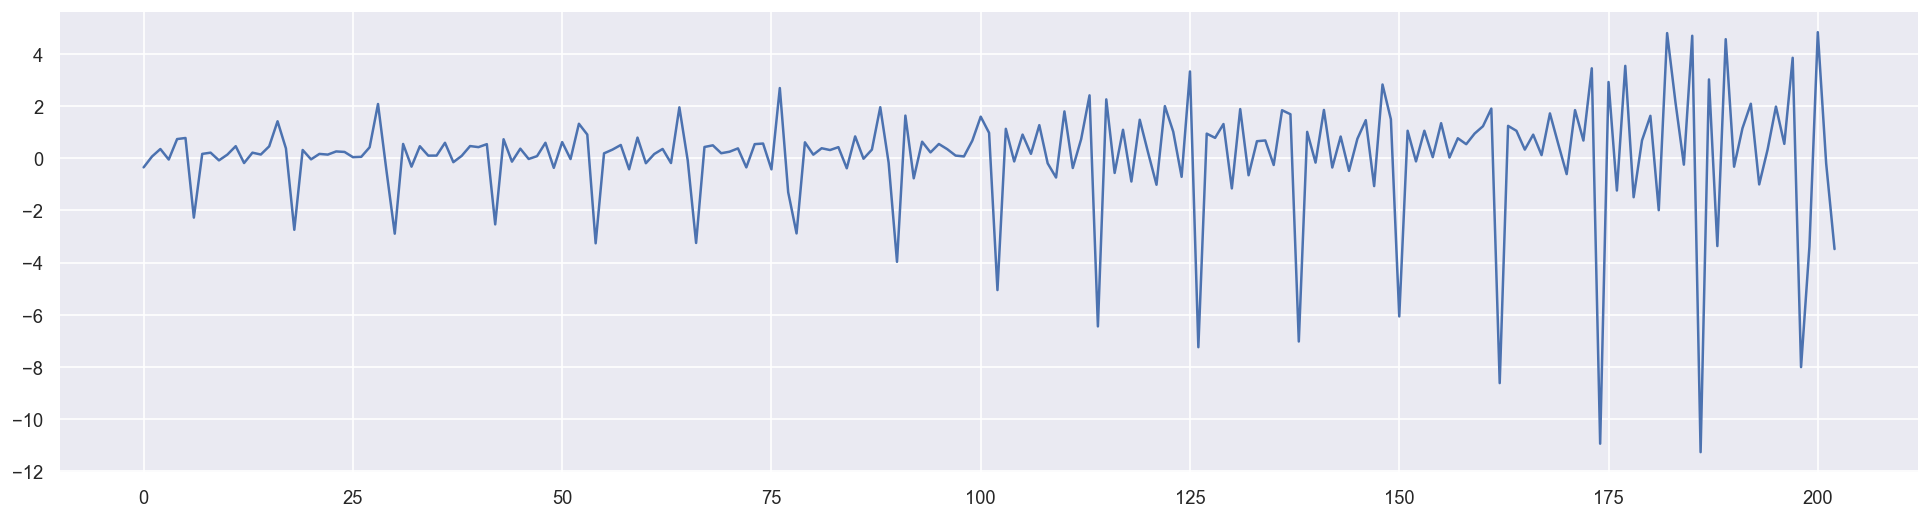

In [37]:
plt.plot(Y)

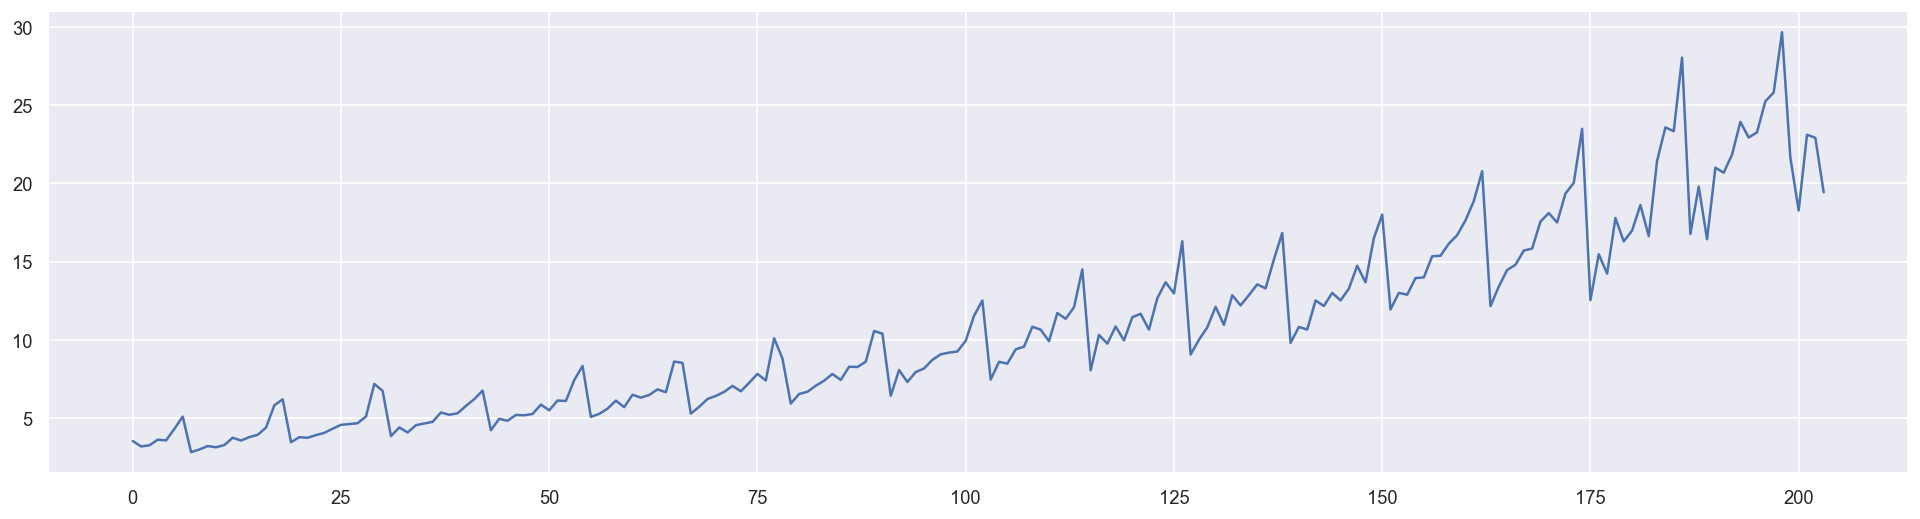

In [38]:
plt.plot(X)

In [39]:
date_filter = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]
date_filter

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object

In [40]:
result = adfuller(sample_dataset.value.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 3.145185689306743
p-value: 1.0


In [41]:
def plot_acf(values, title):
    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    # Original Series ACF
    axes.plot(values)
    axes.set_title(title)

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values, ax=axes[0])
    tsaplots.plot_pacf(values, ax=axes[1])
    
    # 1st Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff())
    axes.set_title(f'{title} - 1st Order Differencing')

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().dropna(), ax=axes[0])
    tsaplots.plot_pacf(values.diff().dropna(), ax=axes[1])

    
    # 2nd Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff().diff())
    axes.set_title(f'{title} - 2nd Order Differencing')
    
    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().diff().dropna(), ax=axes[0])
    tsaplots.plot_pacf(values.diff().diff().dropna(), ax=axes[1])
    
    plt.show()

# Arima demonstration

Demonstrate your Arima implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the statsmodels implementation. Hint: you can look at the documentation.


In order to demonstrate our result, we chose to use the following comparisons:

1. Comparison between the methods:
   - We made a comparison between the SKLearn Model and the Custom Model, while comparing the true labels / predicted labels of each one of the models using a confusion matrix, and also compare between their accuracies (In the bottom of the notebook, a comparison of all our experiments)
   - The accuracies are compared both for train set and both for test set
   - Since IRIS dataset is a well known dataset exact for these models, we've found a very high accuracy for both models
2. Comparison between the features:
   - The IRIS dataset has 4 features, and we compared the accuracy between all the possible feature pairs
   - Also, we built a boundry graph for each one of the pairs (A boundry graph can be built just for 2 features)
   - We found that the best combination are when one feature is Sepal and the other is Petal


In [42]:
def run_arima(dataset, param, date_label):
    print("Training based on:")
    for k, v in param.items():
        print(f"{k} -> {v}")
        
    model = ARIMA(dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.predict()
    forecast_df = pd.DataFrame({'date':dataset['date'], 'value':forecast.values})
    print(type(forecast))
    plt.plot(list(dataset['date']), list(forecast), label = "forecast")
    plt.plot(list(dataset['date']), list(dataset['value']), label = "actual")
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Actual vs forecast')
    plt.show()

    return forecast_df

In [65]:
def run_arima_train_test(dataset, param, date_label):
    print("Train / Test based on:")

    split = int(len(dataset)*param["train_rate"])
    train_dataset = dataset[:split]
    test_dataset = dataset[split:]
    
    for k, v in param.items():
        print(f"{k} -> {v}")
    
    model = ARIMA(train_dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    custom_model = ARIMACustom(train_dataset.value.values, order=param["order"])
    custom_model.fit()
    
    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.get_forecast((len(dataset) - split), alpha=0.05)  # 95% conf
    forecast_df = pd.DataFrame({'date':test_dataset['date'], 'value': forecast.predicted_mean})
    
    custom_forecast = custom_model.forecast((len(dataset) - split))
    custom_forecast_df = pd.DataFrame({'date':test_dataset['date'], 'value': custom_forecast})
    
    #print(type(forecast))
    plt.plot(list(train_dataset['date']), list(train_dataset['value']), label = "training")
    plt.plot(list(test_dataset['date']), list(test_dataset['value']), label = "actual")
    plt.plot(list(forecast_df['date']), list(forecast_df['value']), label = "forecast - statsmodel")
    plt.plot(list(custom_forecast_df['date']), list(custom_forecast_df['value']), label = "forecast - custom")
    plt.fill_between(list(forecast_df['date']), 
                 forecast.conf_int().iloc[:, 0], 
                 forecast.conf_int().iloc[:, 1], 
                 color='k', alpha=.15)
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Training / Actual vs forecast')
    plt.show()

    return forecast_df

ACF / PACF of original data


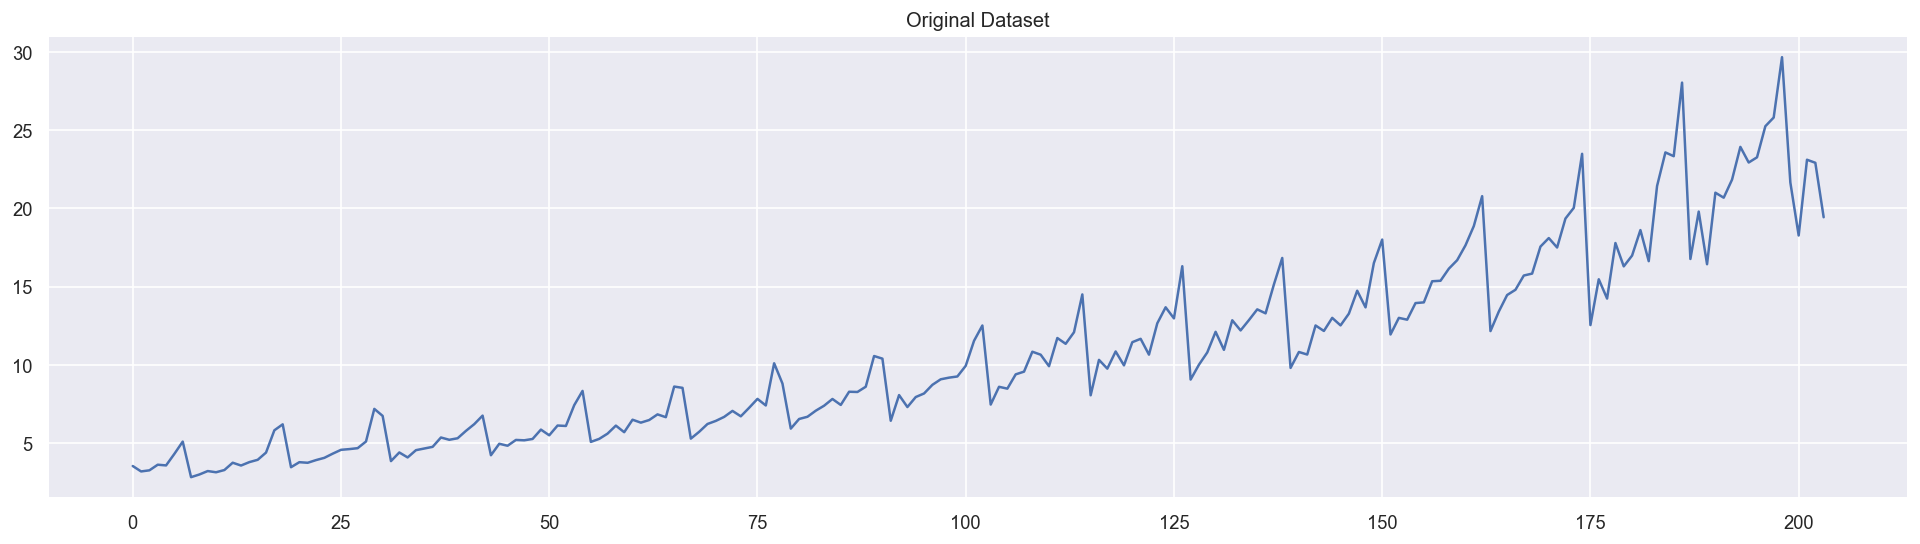

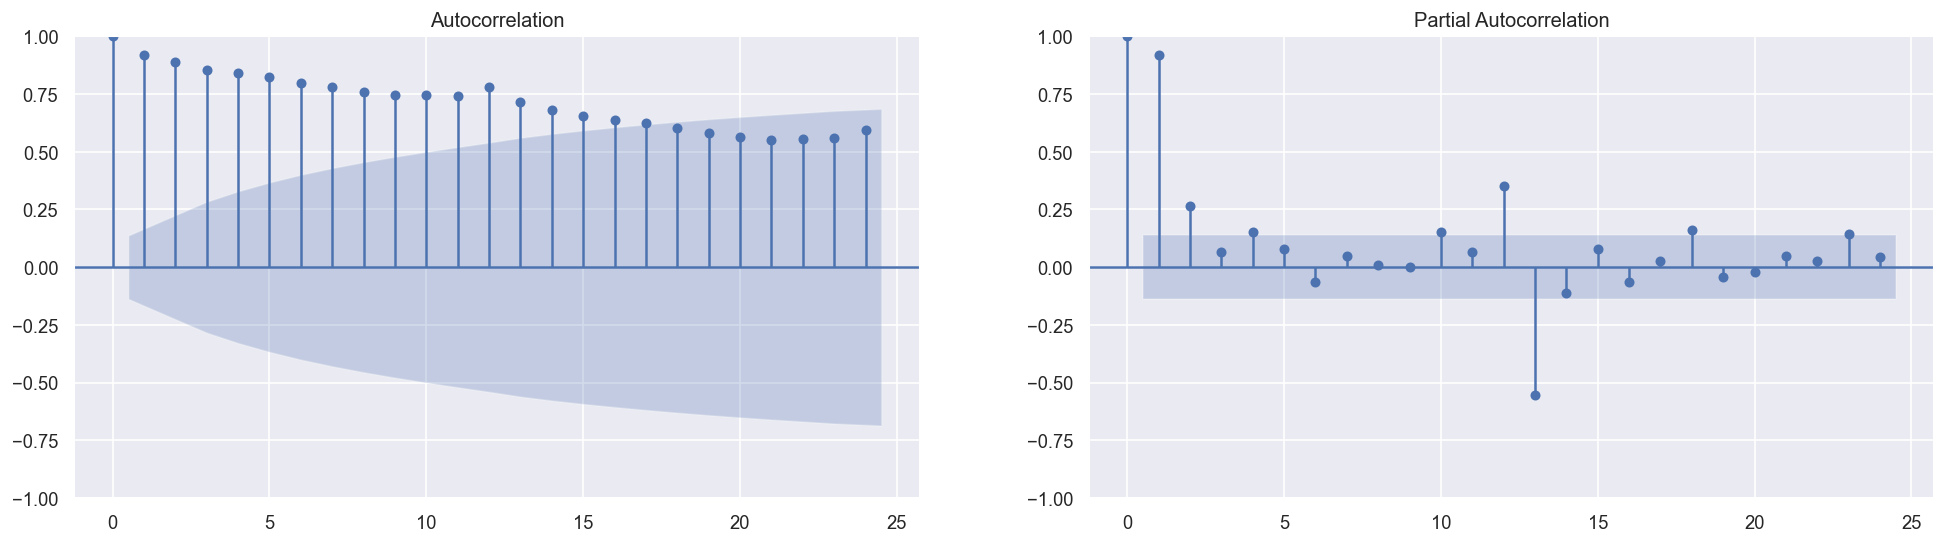

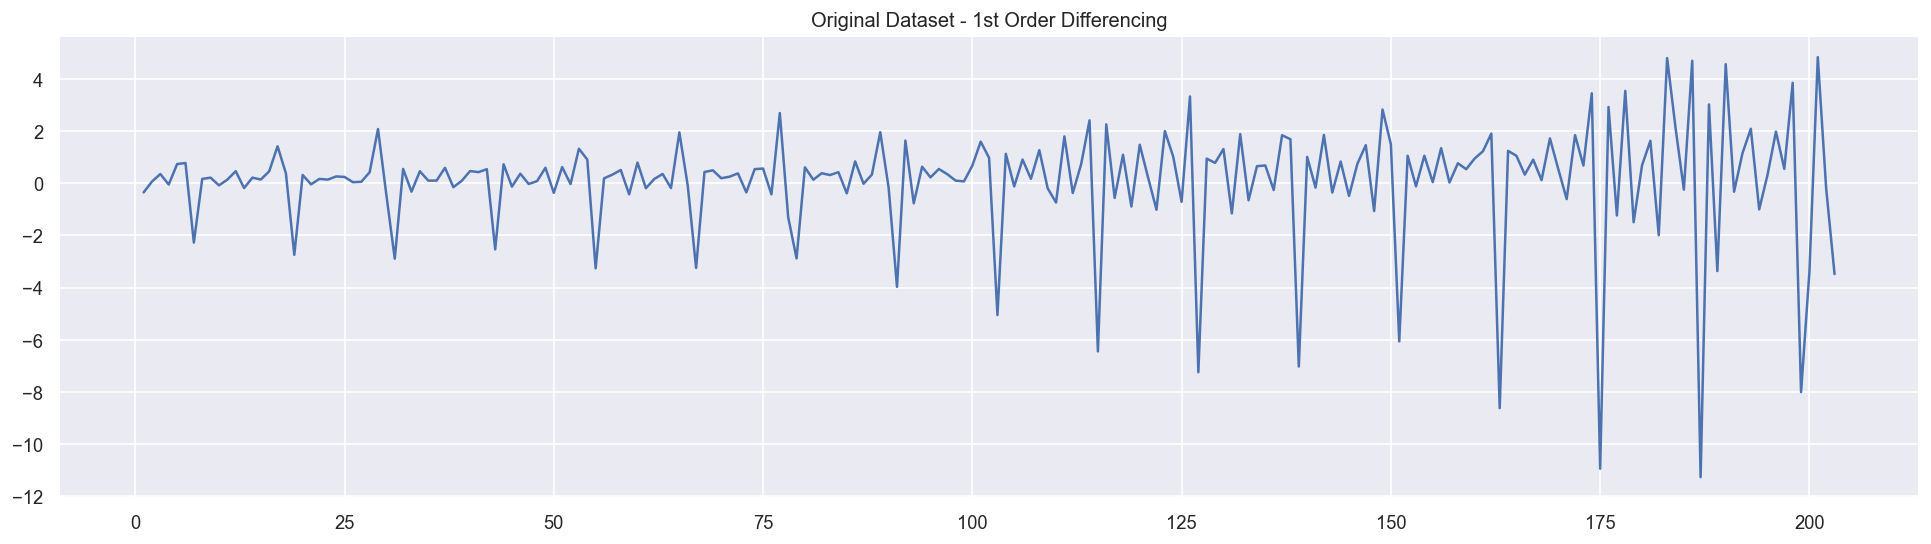

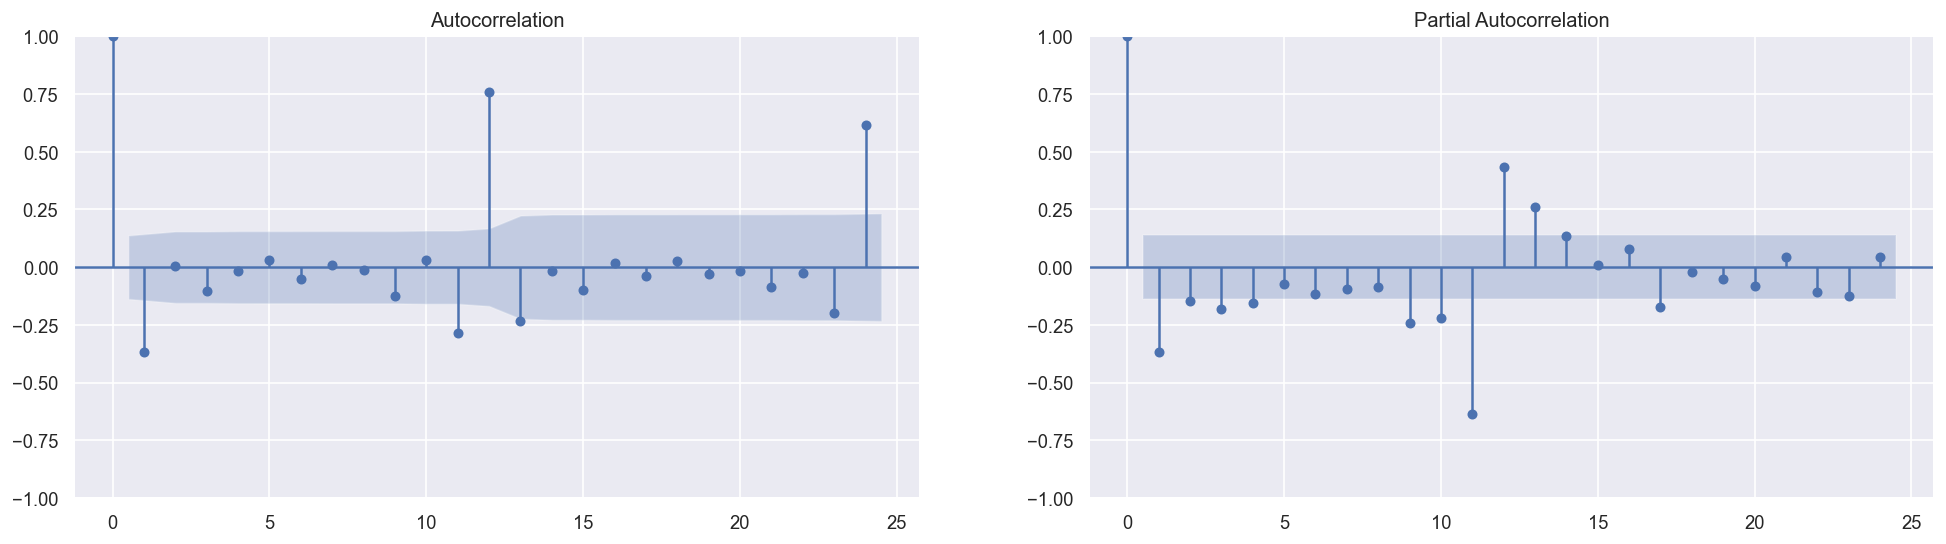

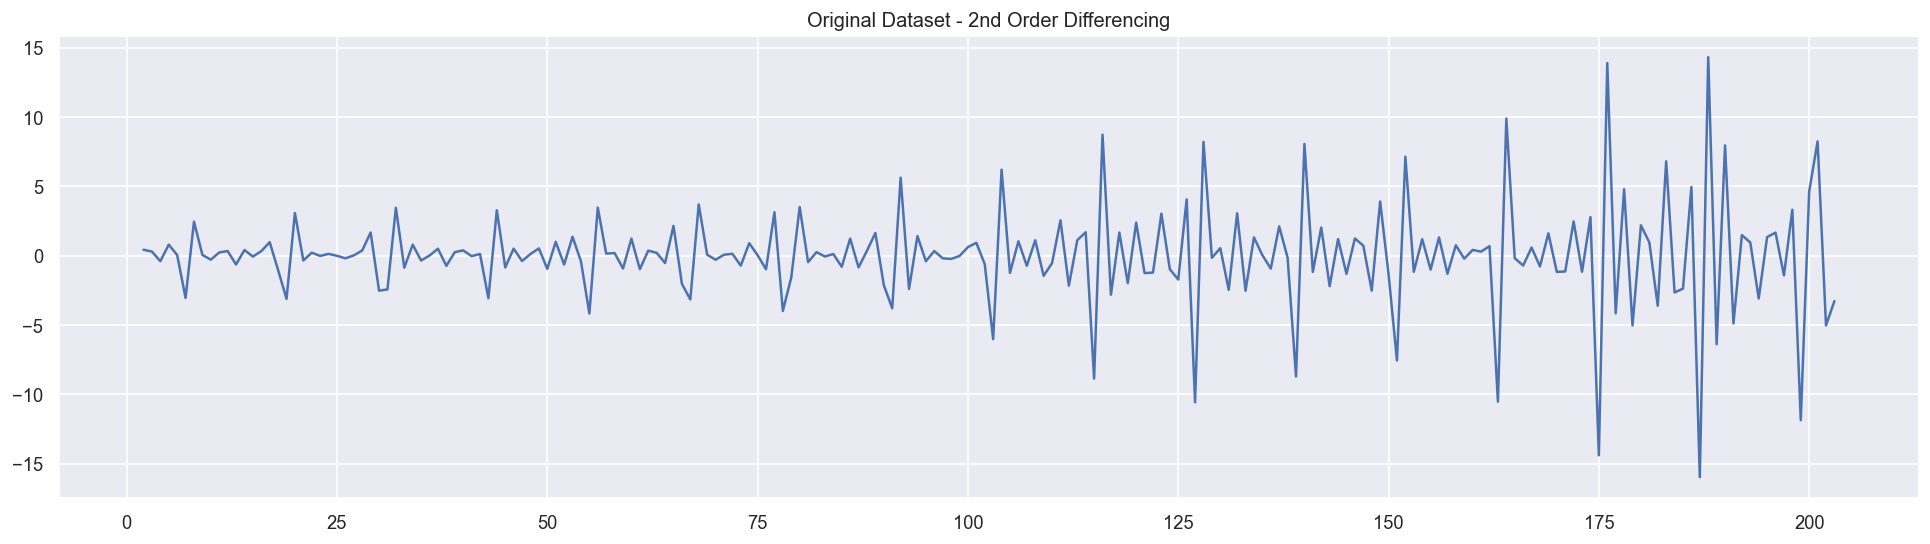

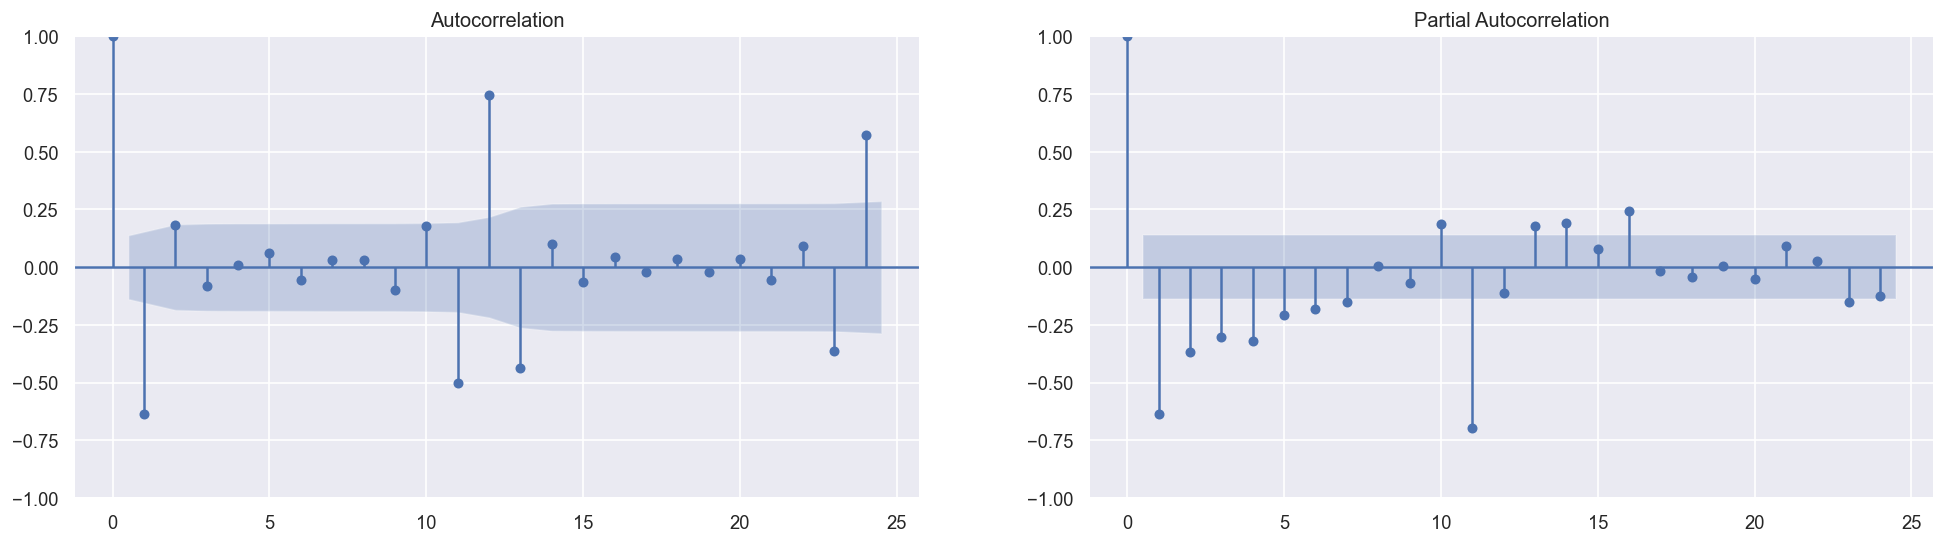

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object
Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -251.244
Date:                Wed, 12 Mar 2025   AIC                            512.488
Time:                        15:39:44   BIC                            527.196
Sample:                             0   HQIC                           518.465
                                - 142                                         
Covariance Type:                  opg                  

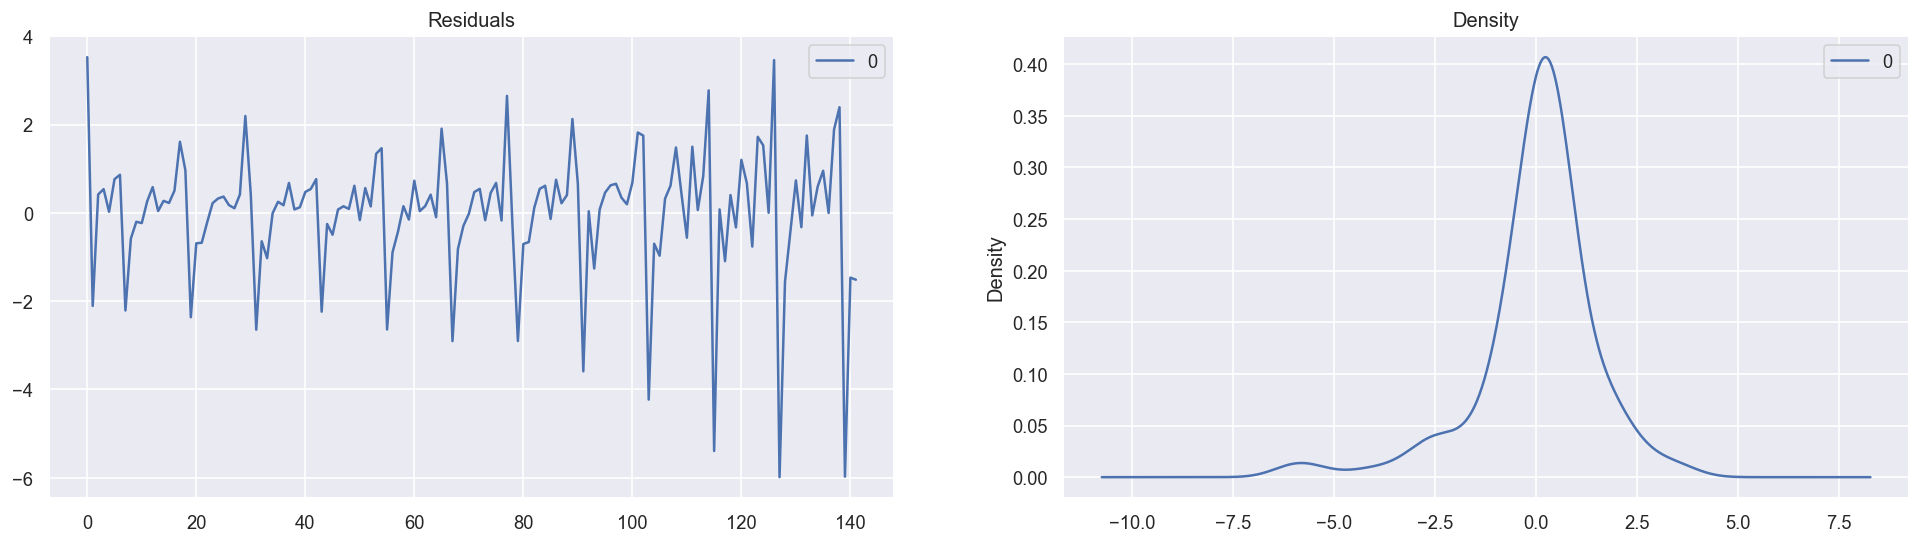

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


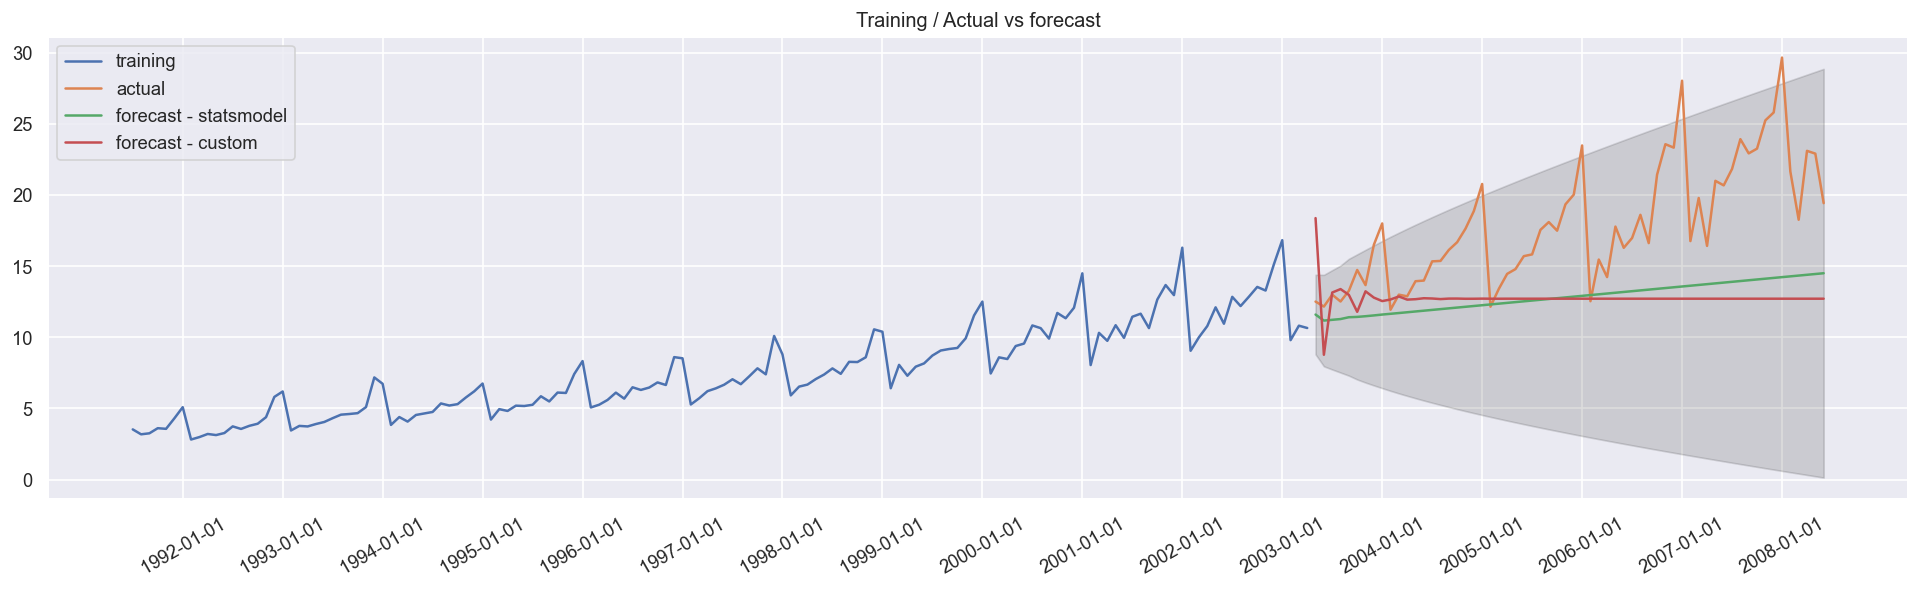

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -242.893
Date:                Wed, 12 Mar 2025   AIC                            493.786
Time:                        15:39:44   BIC                            505.581
Sample:                             0   HQIC                           498.579
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2453      0.591      0.415      0.678      -0.914       1.404
ma.L1         -0.8013      0.569     -1.408      0.159      -1.917     

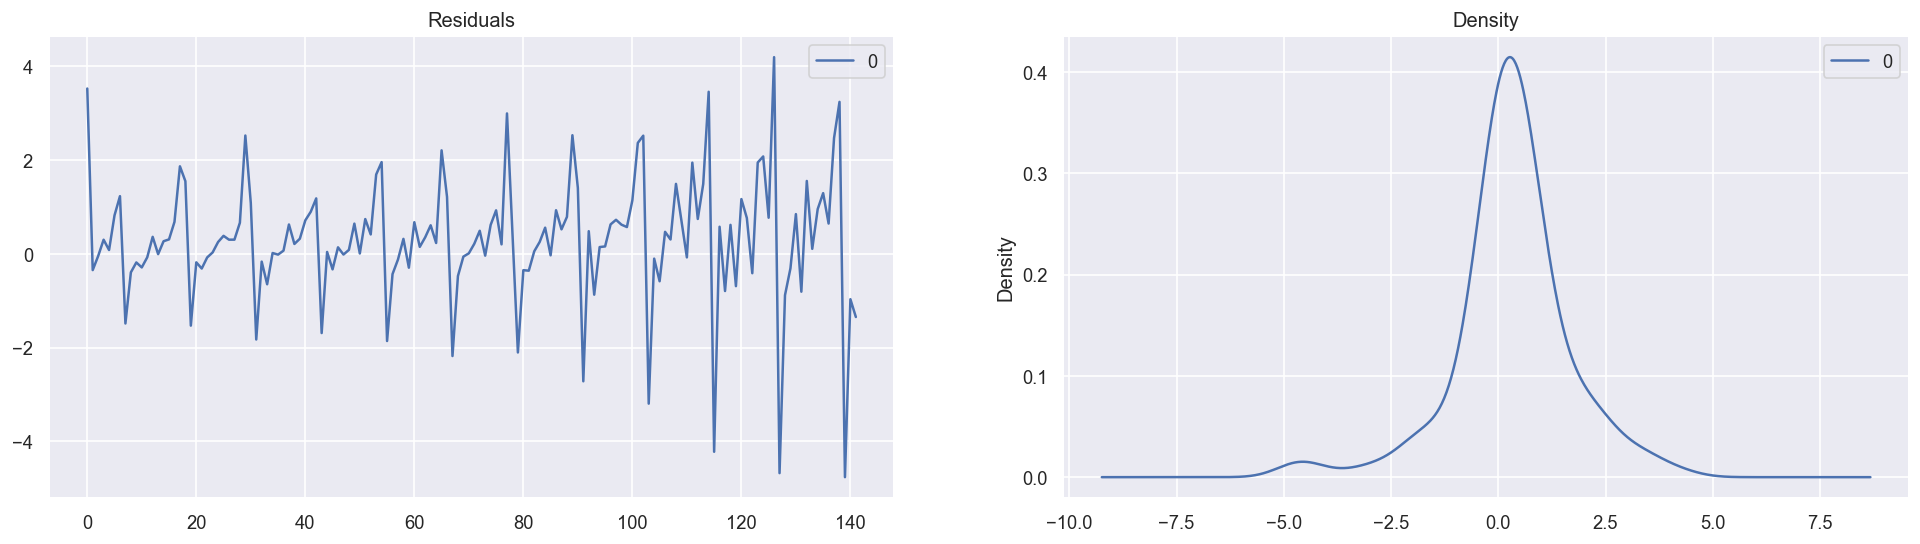

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


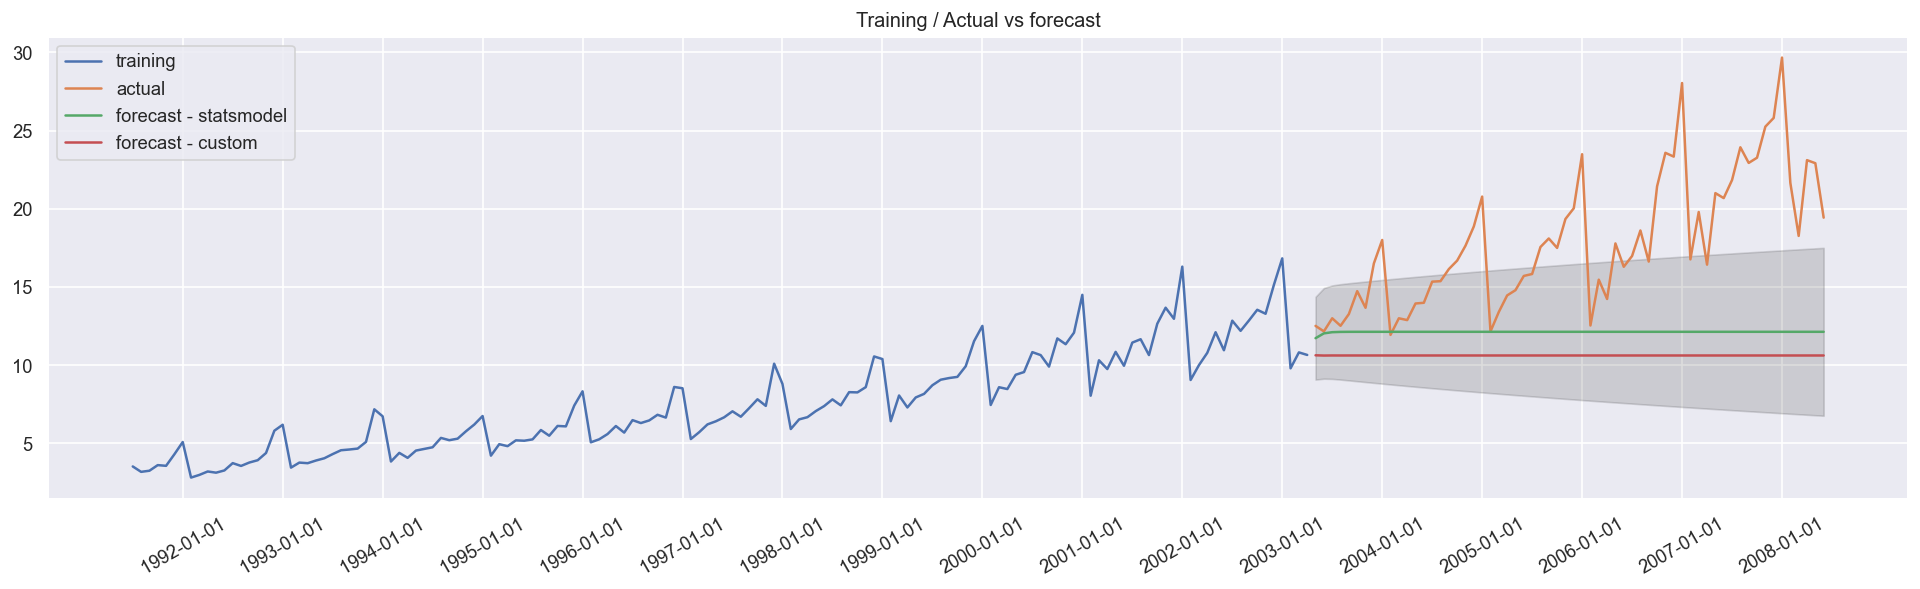

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -242.904
Date:                Wed, 12 Mar 2025   AIC                            491.808
Time:                        15:39:45   BIC                            500.654
Sample:                             0   HQIC                           495.402
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2844      0.185      1.539      0.124      -0.078       0.647
ma.L1         -0.8431      0.089     -9.435      0.000      -1.018     

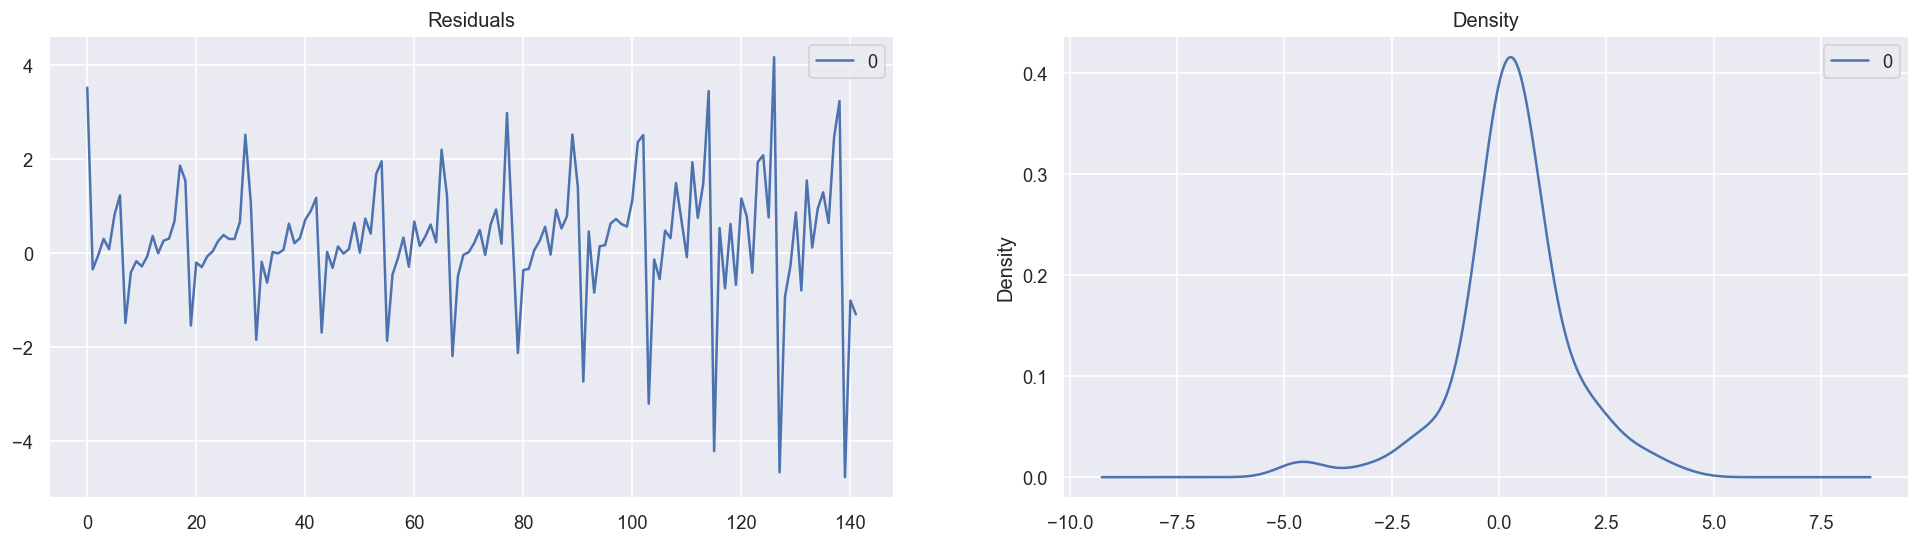

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


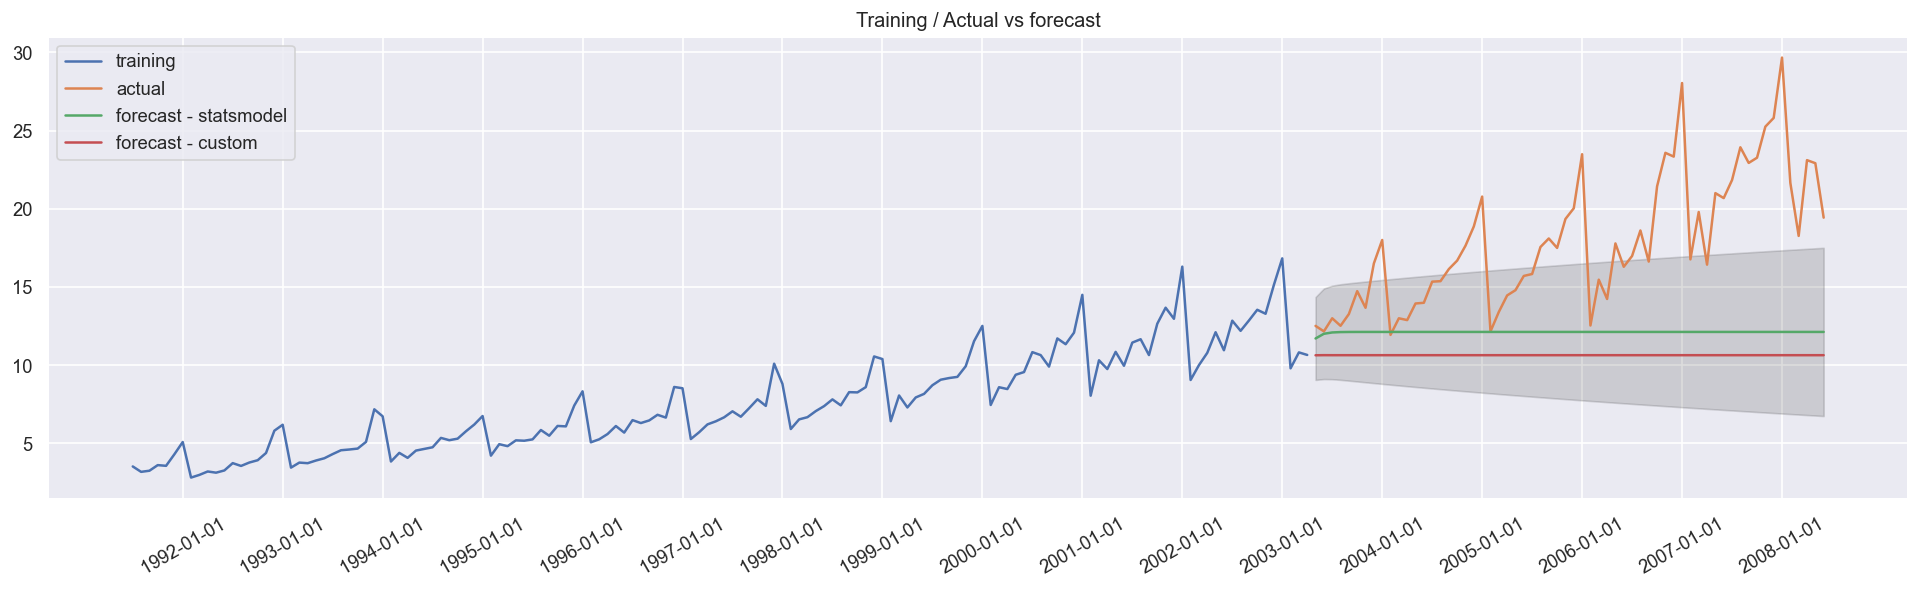

In [66]:
hyperparams = [{
    "order": (3, 2, 1),
     "train_rate": 0.7
},{
    "order": (1, 1, 2),
     "train_rate": 0.7
},{
    "order": (1, 1, 1),
     "train_rate": 0.7
}]

print("ACF / PACF of original data")
plot_acf(sample_dataset.value, "Original Dataset")
print("==================================================================================================")
date_label = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]

print(date_label)
for idx, param in enumerate(hyperparams):
    #predicted_dataset = run_arima(sample_dataset, param, date_label)
    #print("==================================================================================================")
    predicted_dataset = run_arima_train_test(sample_dataset, param, date_label)
    print("==================================================================================================")

# AMZN Dataset


In [21]:
path = './AMZN_data_1999_2022.csv'

amzn_dataset_original = pd.read_csv(path)

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-04,2.730729,2.966667,2.665625,2.957813,2.957813,785844000
1,1999-01-05,2.739063,3.243750,2.662500,3.112500,3.112500,1257464000
2,1999-01-06,3.409375,3.509375,3.350000,3.450000,3.450000,723532000
3,1999-01-07,3.428125,4.006250,3.325000,3.971875,3.971875,945492000
4,1999-01-08,4.606250,4.978125,3.800000,4.006250,4.006250,1333244000


In [67]:
ticker = yf.Ticker('AMZN')

amzn_dataset_original = ticker.history(period="max").reset_index() 
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].astype(str)
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].str.split().str[0]

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [68]:
mean_list = np.mean( np.array([ amzn_dataset_original['Low'], amzn_dataset_original['High'] ]), axis=0 )
datasets = {
    #'open': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Open']}),
    #'close': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Close']}),
    #'high': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['High']}),
    #'low': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Low']}),
    'mean': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':mean_list}),
    'volume': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Volume']})
}

In [69]:
def get_date_labels_amzn(dataset):
    date_filter = dataset.loc[dataset['date'].str.endswith('01-02') ^ dataset['date'].str.endswith('01-03') ^ dataset['date'].str.endswith('01-04')]
    date_filter['year'] = date_filter['date'].str.split('-').str[0]
    date_filter.loc[0] = dataset.iloc[0]
    date_filter.at[0, 'year'] = 'first'
    date_filter.loc[len(dataset)-1] = dataset.iloc[-1]
    date_filter.at[len(dataset)-1, 'year'] = 'last'
    date_filter = date_filter.drop_duplicates(subset=['year'], keep='first')
    date_filter = date_filter.loc[:, 'date']
    date_filter = date_filter.sort_index()
    
    return date_filter

/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: 

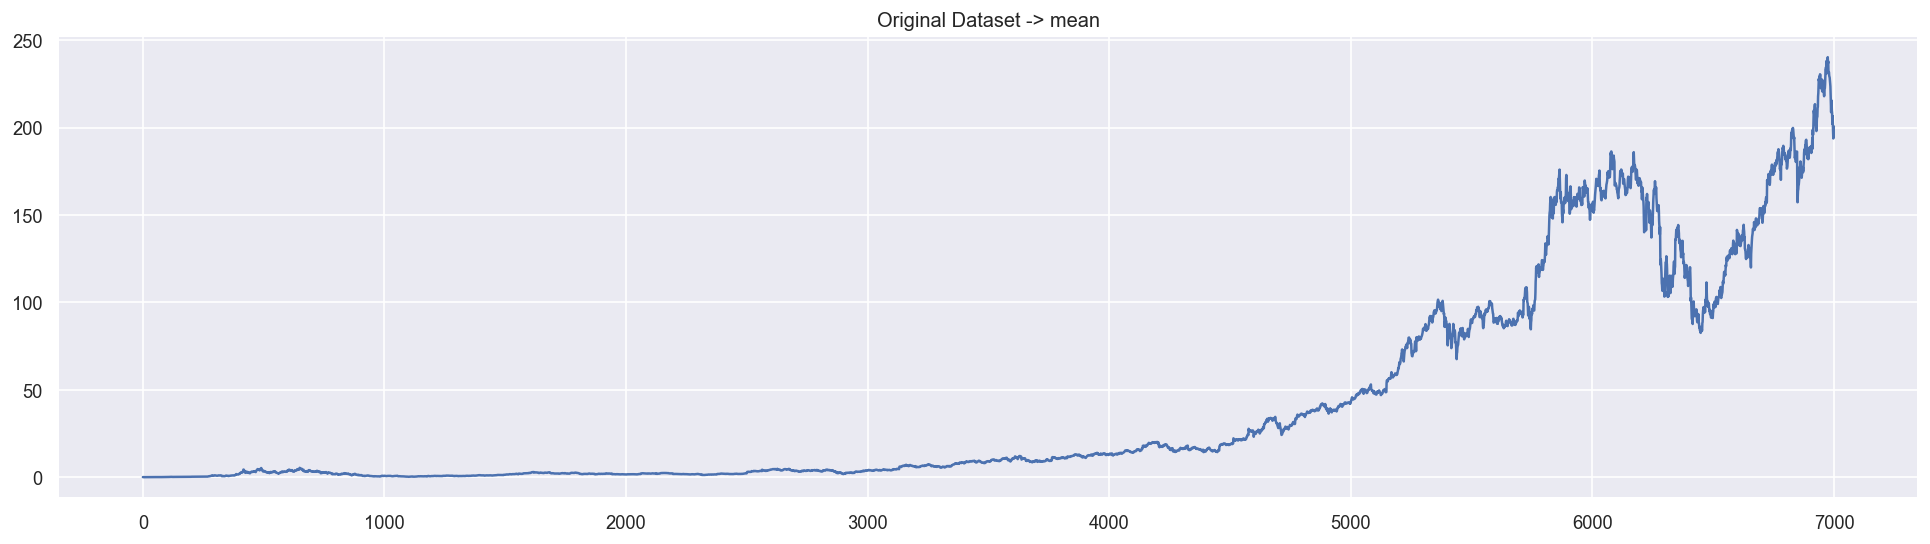

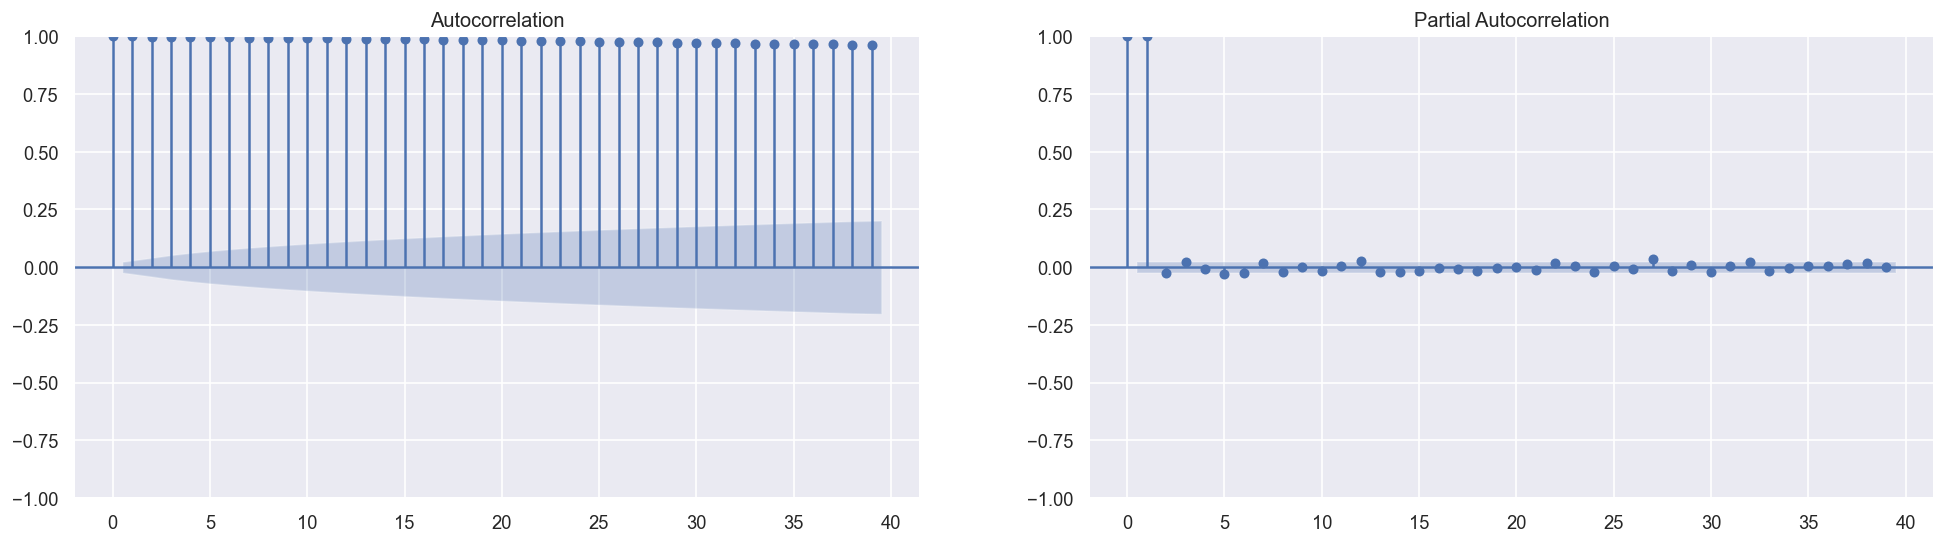

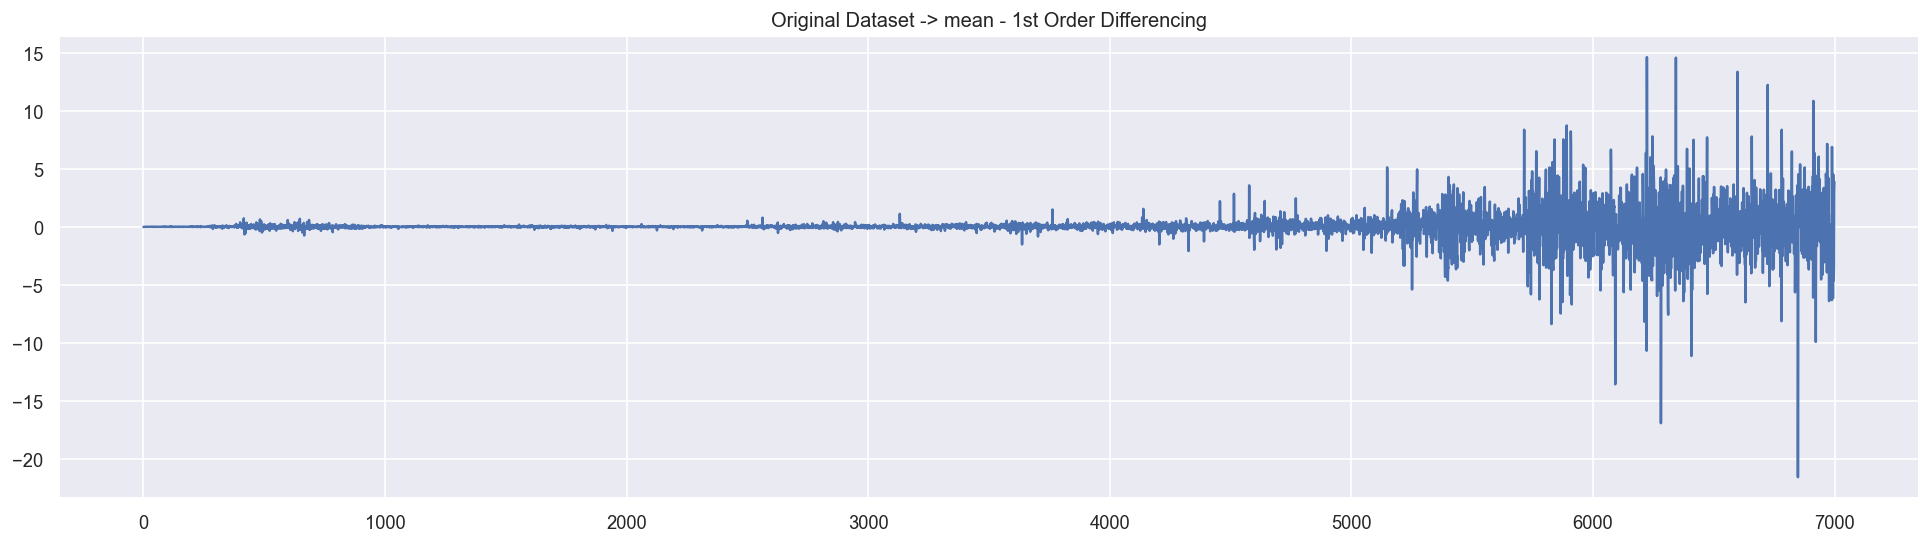

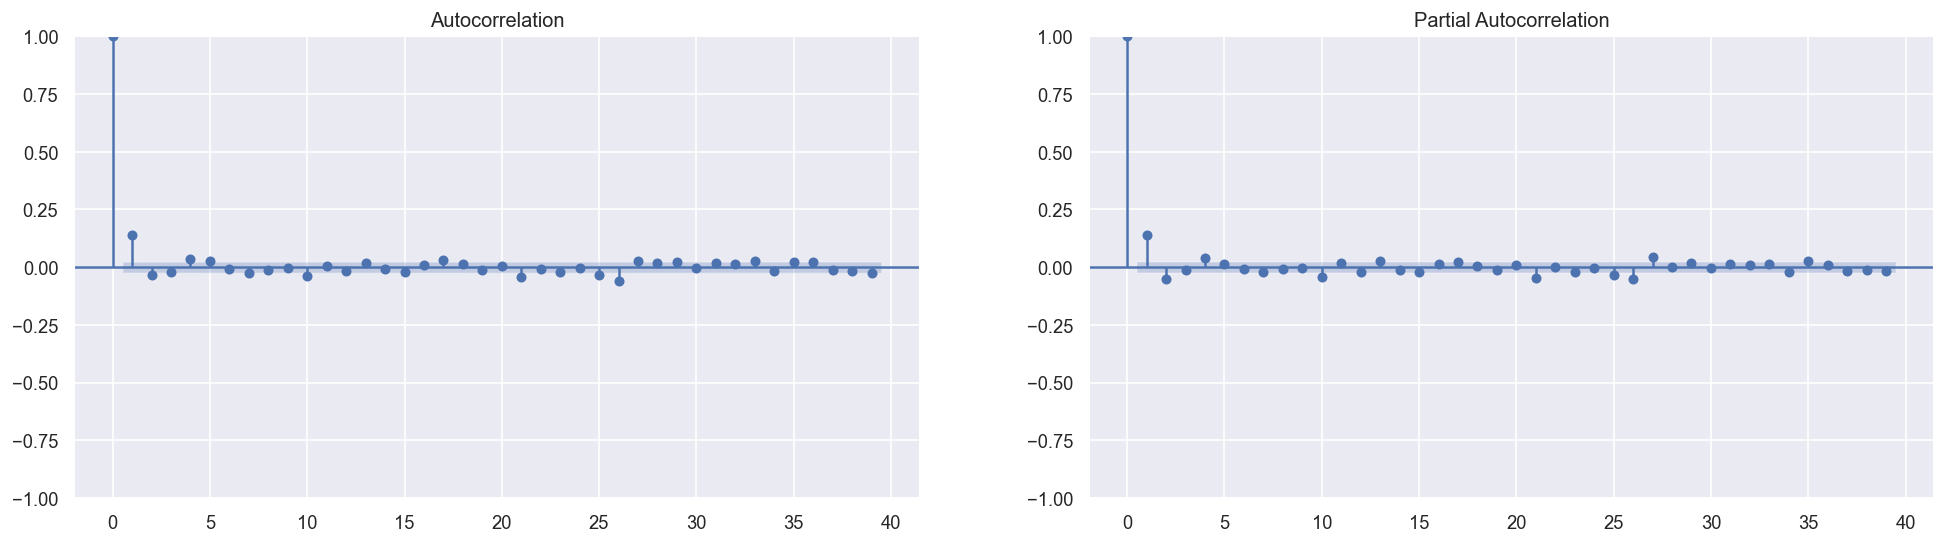

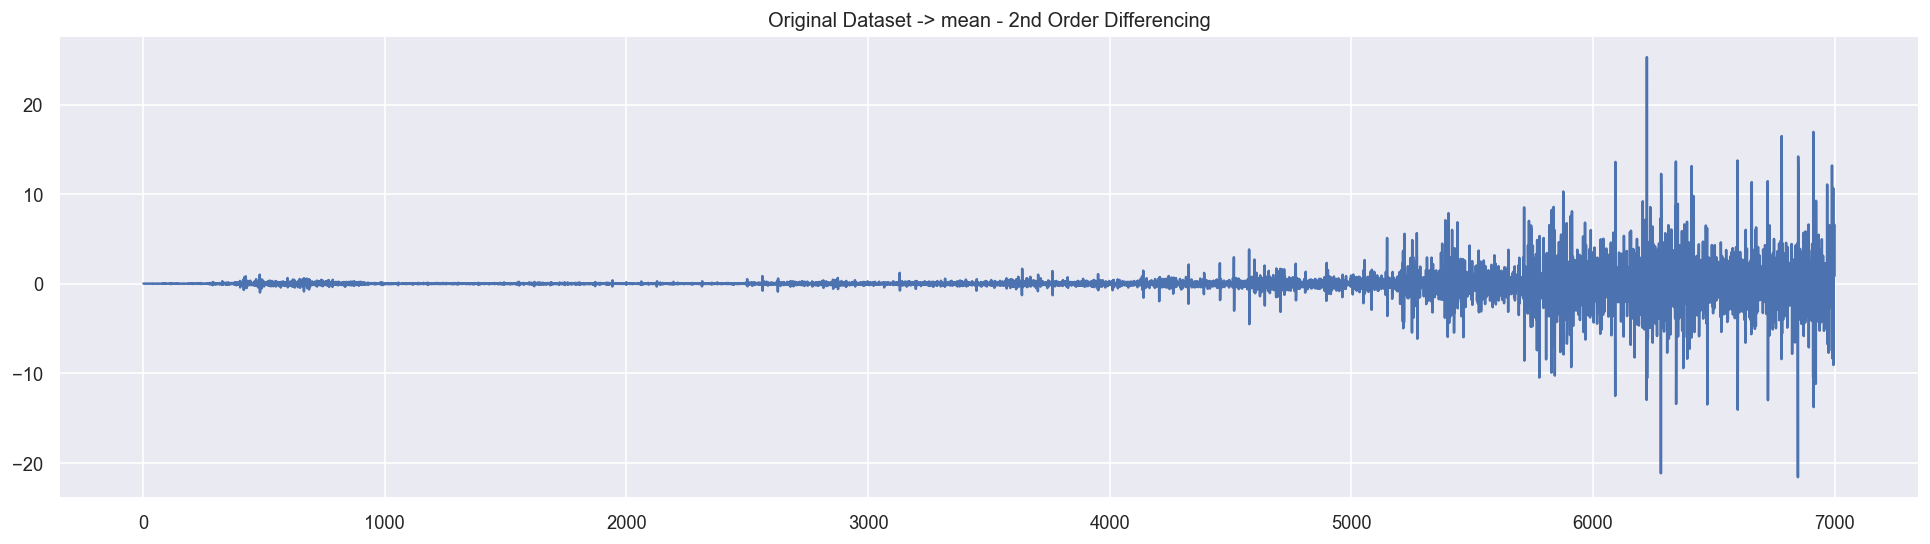

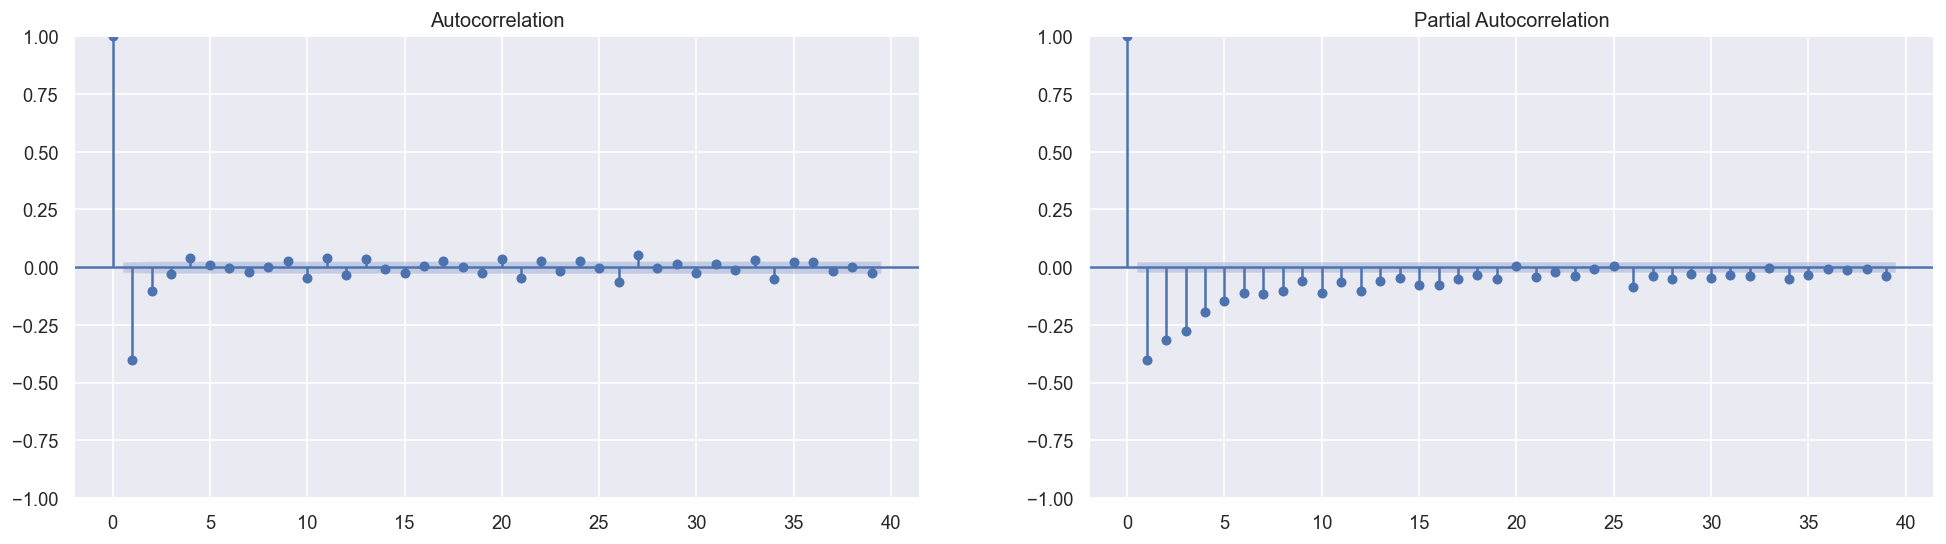

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 2)   Log Likelihood                1021.279
Date:                Wed, 12 Mar 2025   AIC                          -2034.558
Time:                        15:43:16   BIC                          -2008.571
Sample:                             0   HQIC                         -2025.441
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6411      0.211      3.033      0.002       0.227       1.055
ma.L1         -0.5016      0.210     -2.383      0.017      -0.914     

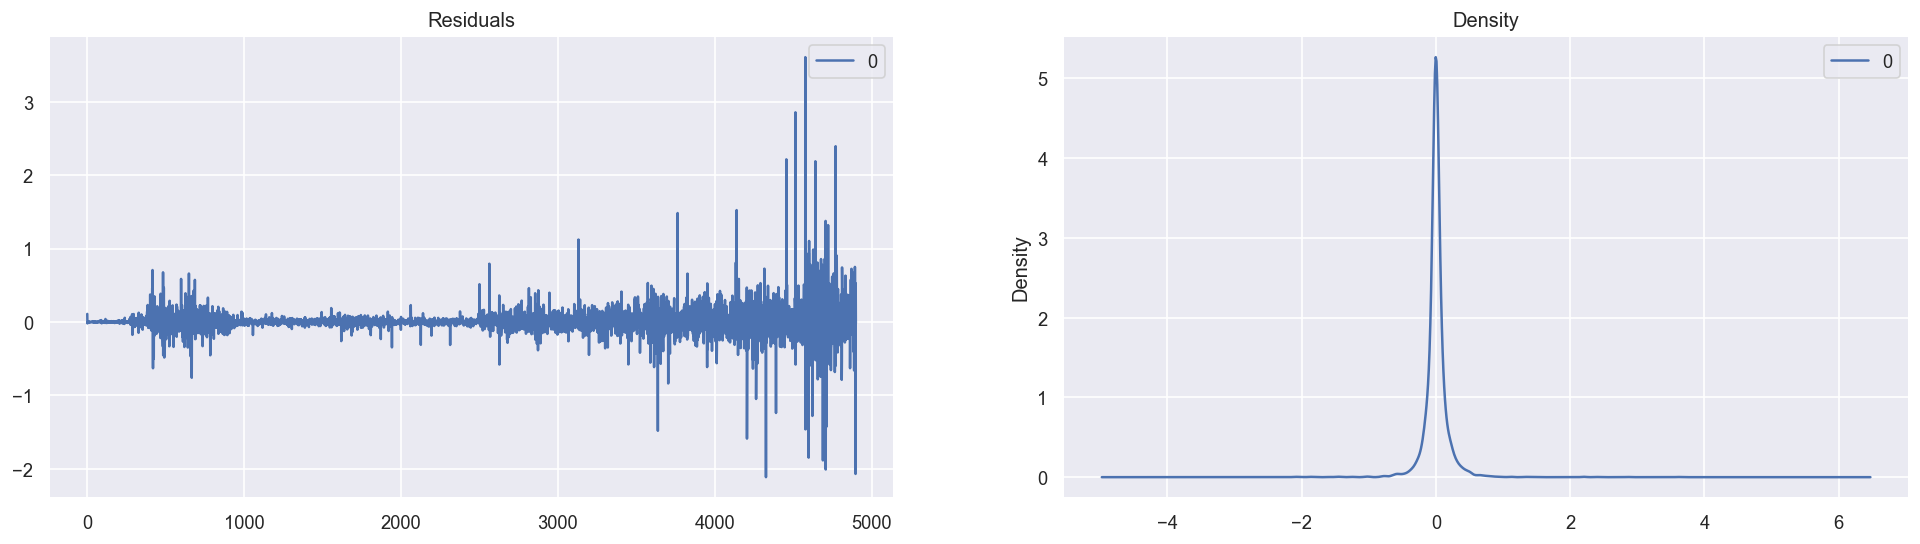

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


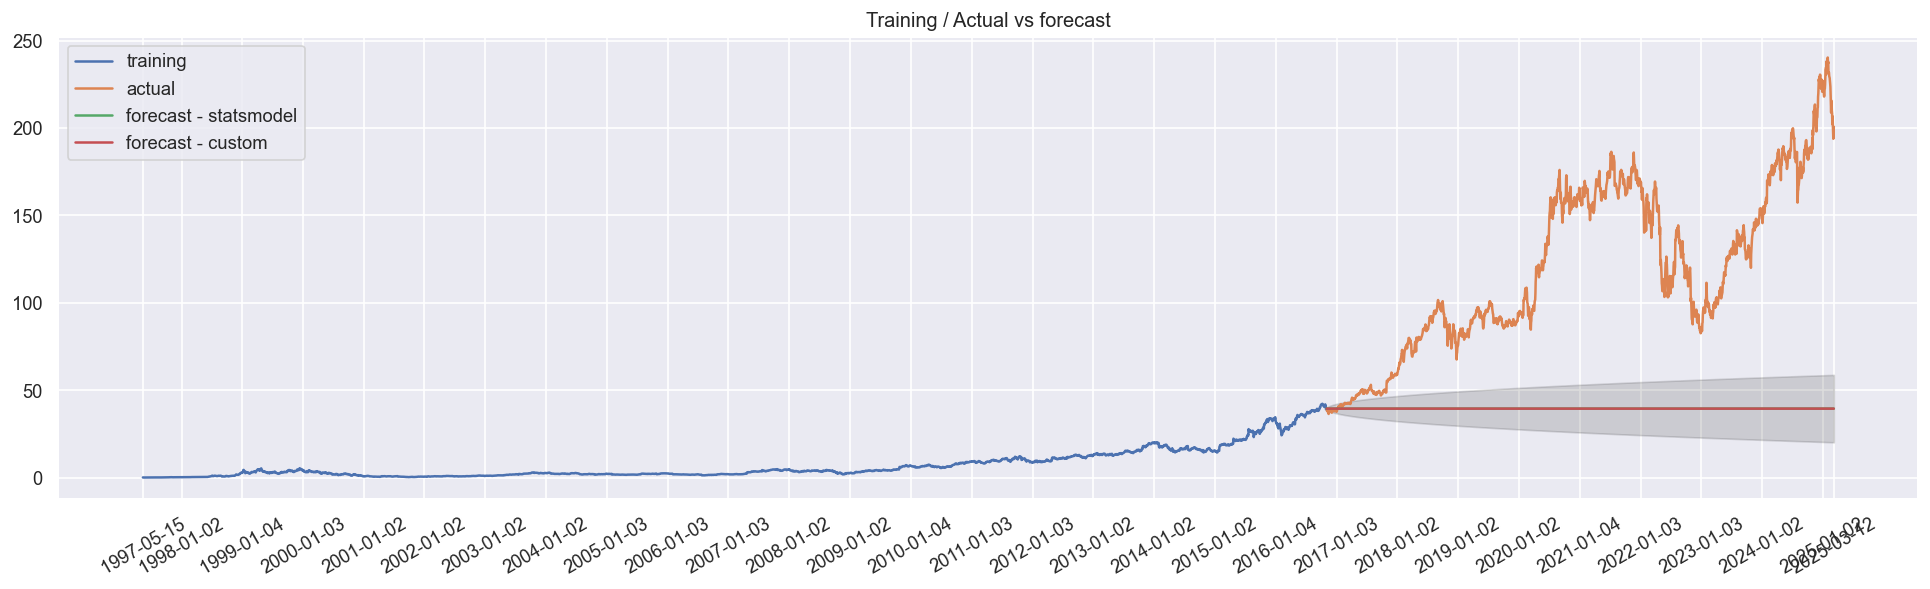

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1020.264
Date:                Wed, 12 Mar 2025   AIC                          -2034.528
Time:                        15:43:17   BIC                          -2015.037
Sample:                             0   HQIC                         -2027.690
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0001      0.055     -0.003      0.998      -0.108       0.108
ma.L1          0.1429      0.055      2.614      0.009       0.036     

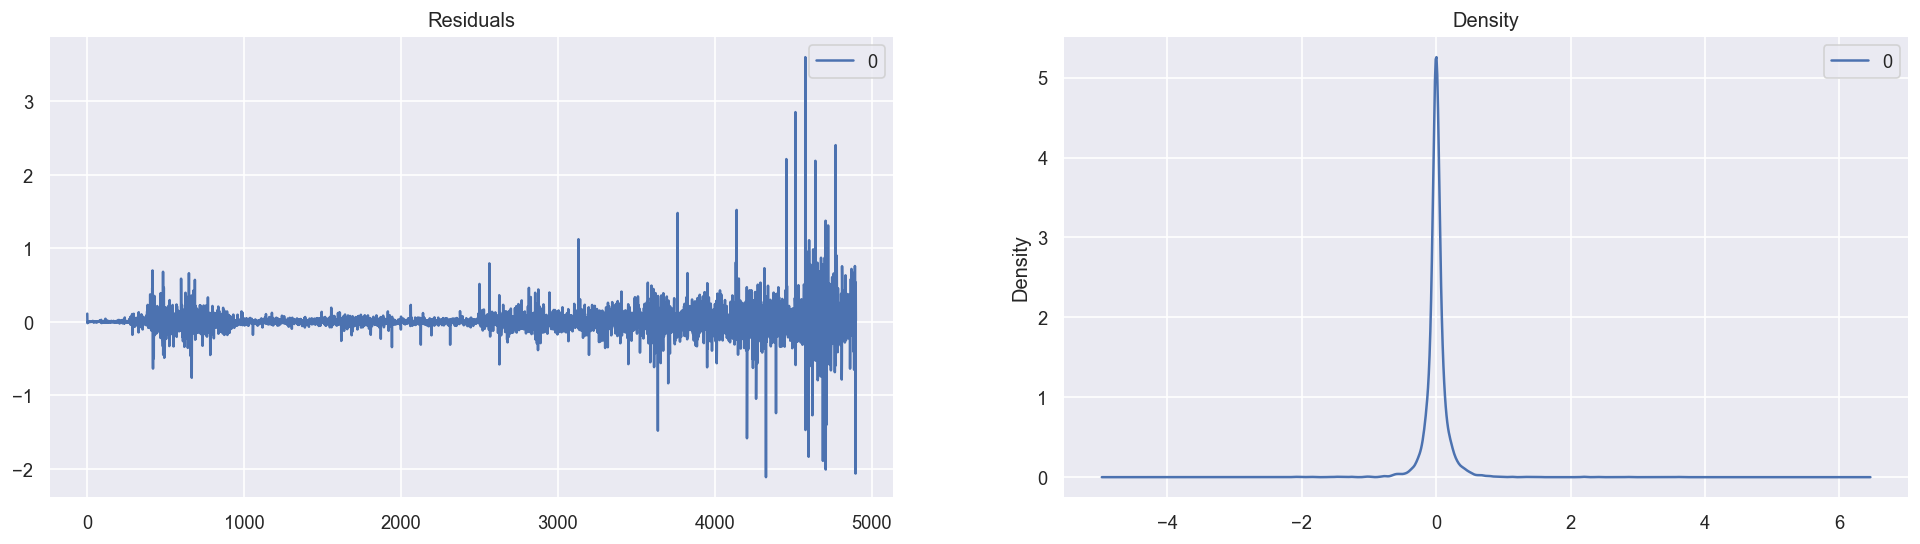

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


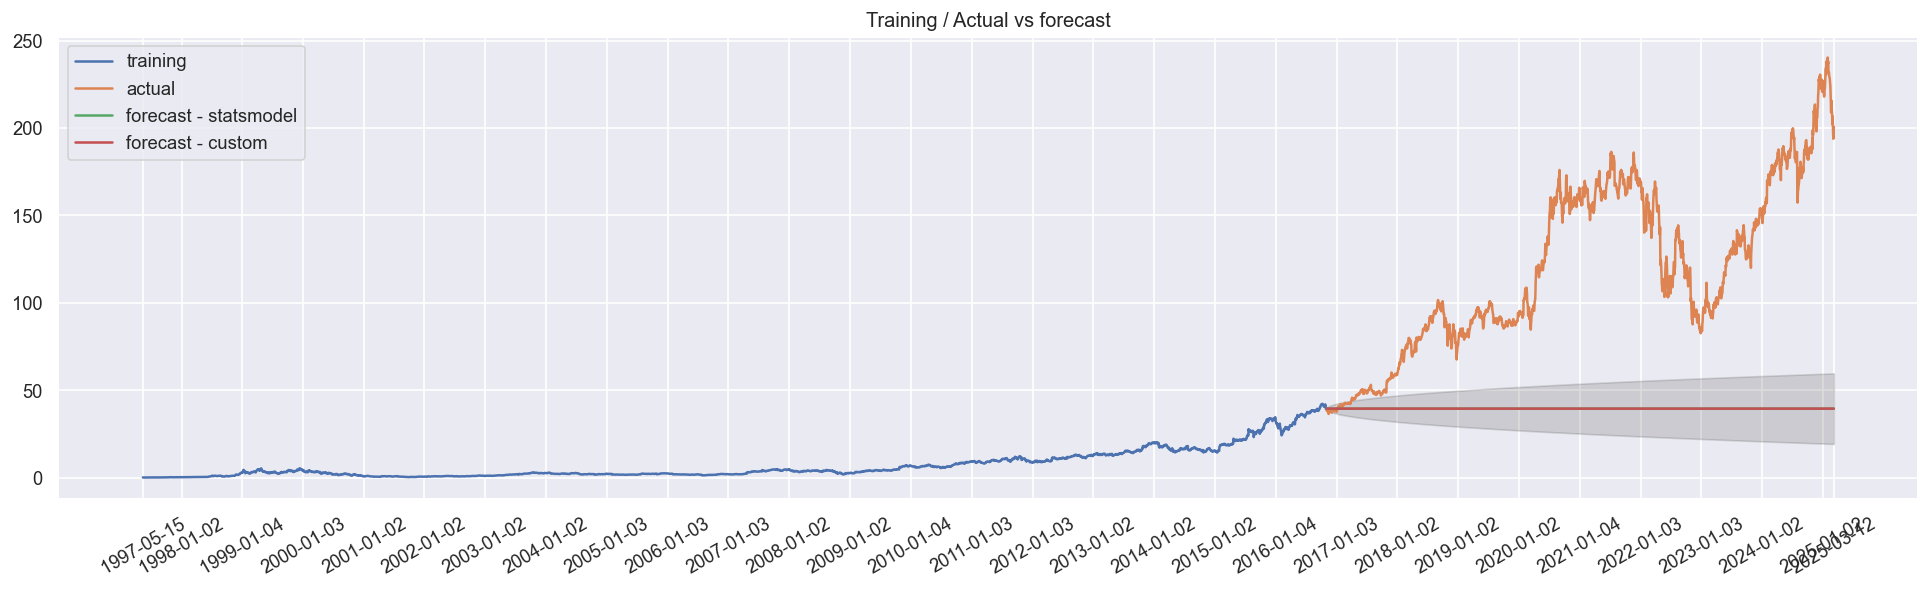

Train / Test based on:
order -> (3, 3, 3)
train_rate -> 0.7


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 3, 3)   Log Likelihood                1013.410
Date:                Wed, 12 Mar 2025   AIC                          -2012.820
Time:                        15:43:21   BIC                          -1967.346
Sample:                             0   HQIC                         -1996.865
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8646      0.006   -142.558      0.000      -0.877      -0.853
ar.L2          0.1091      0.009     11.569      0.000       0.091       0.128
ar.L3         -0.0252      0.008     -3.061      0.0

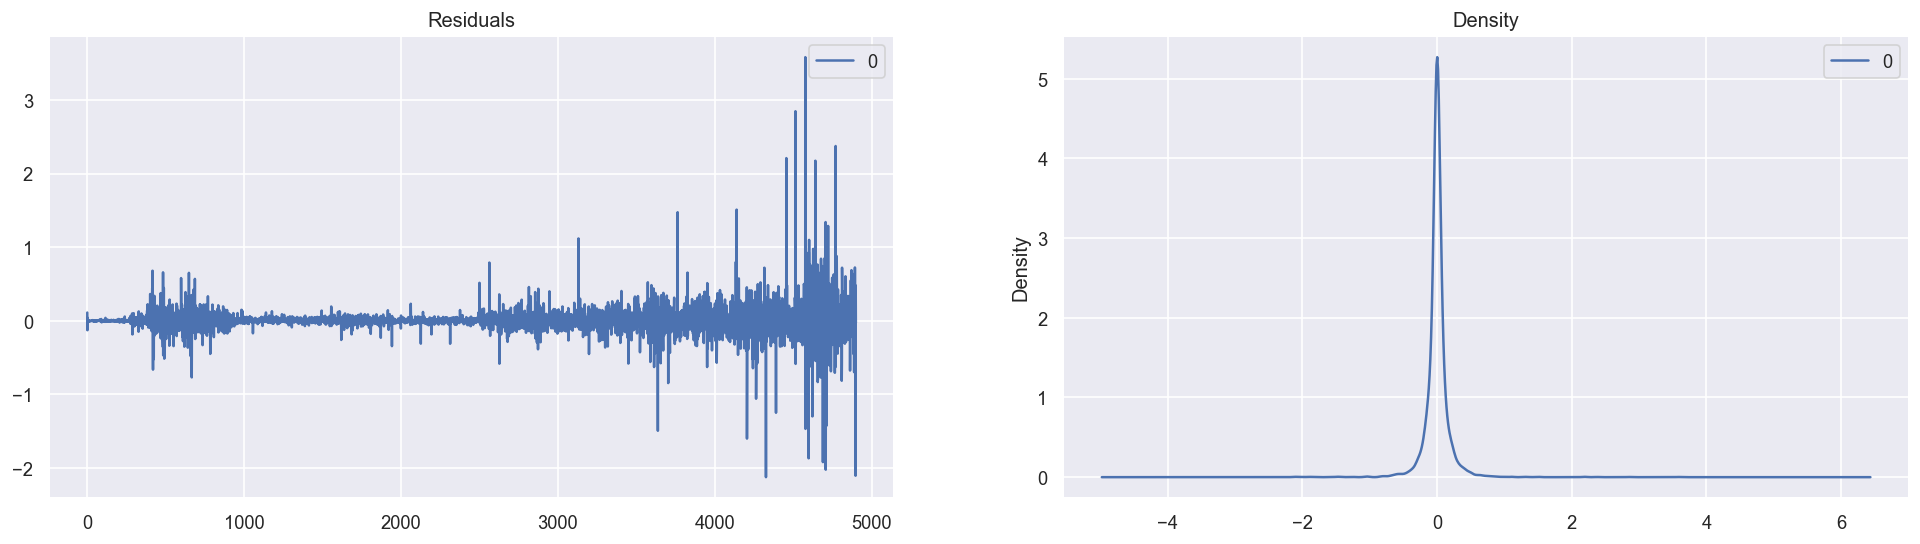

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


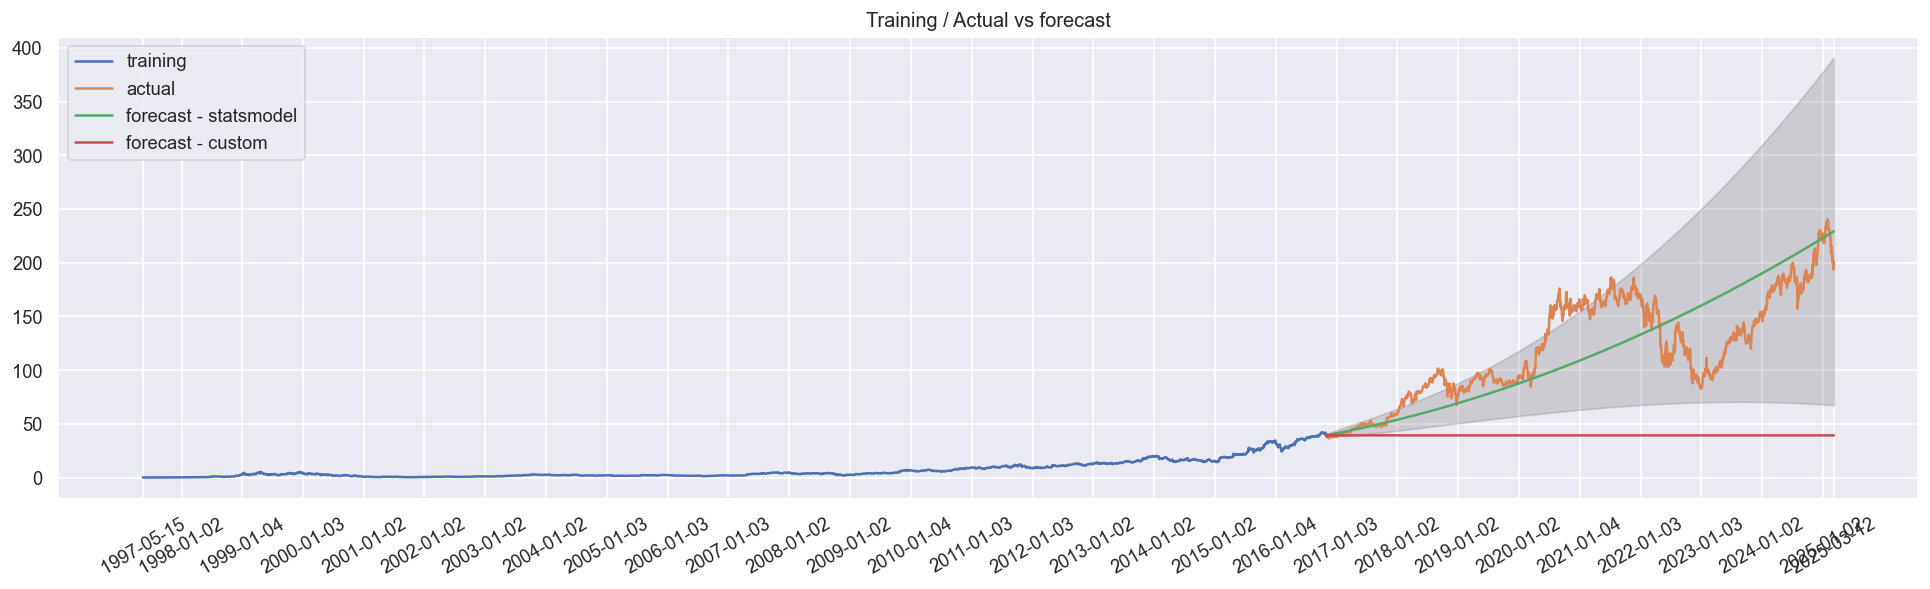

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 1)   Log Likelihood                1025.530
Date:                Wed, 12 Mar 2025   AIC                          -2041.060
Time:                        15:43:23   BIC                          -2008.577
Sample:                             0   HQIC                         -2029.664
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1394      0.005     28.648      0.000       0.130       0.149
ar.L2         -0.0250      0.008     -3.073      0.002      -0.041     

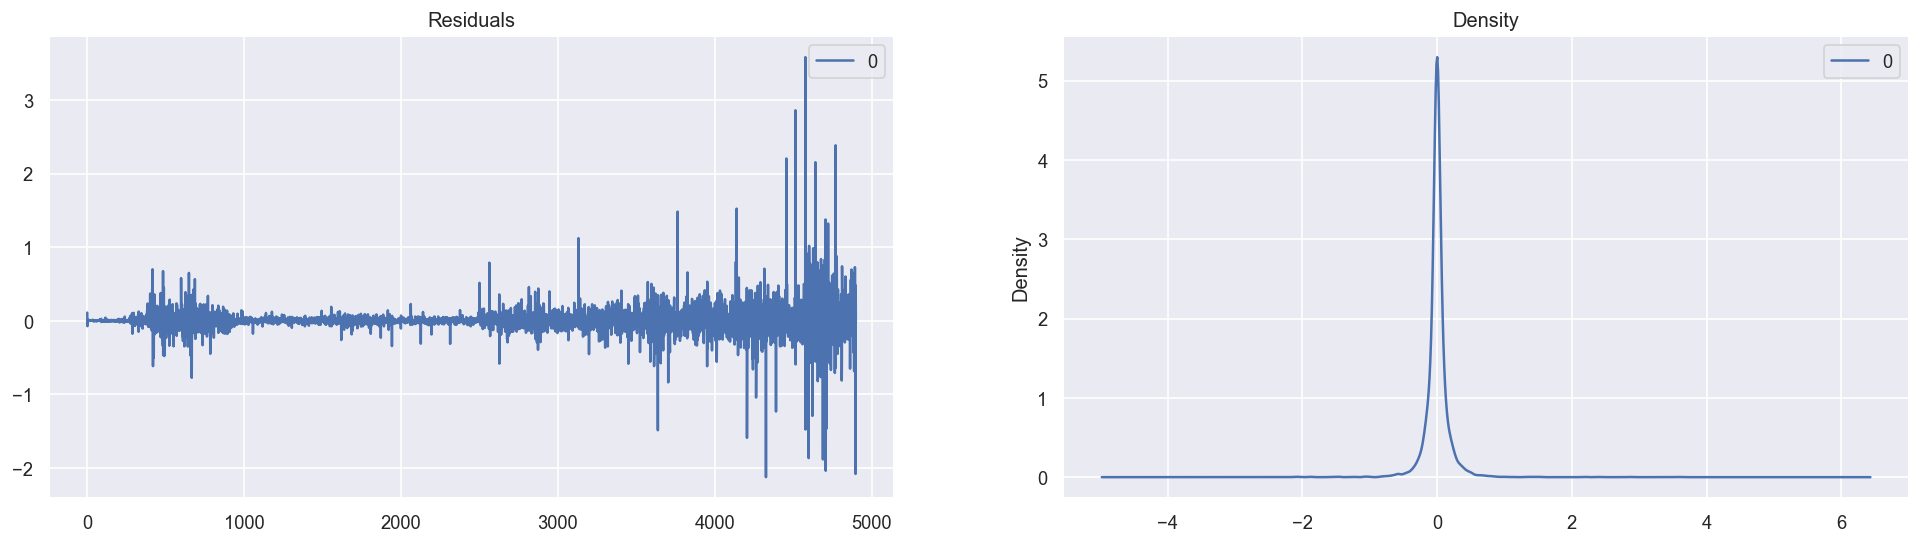

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


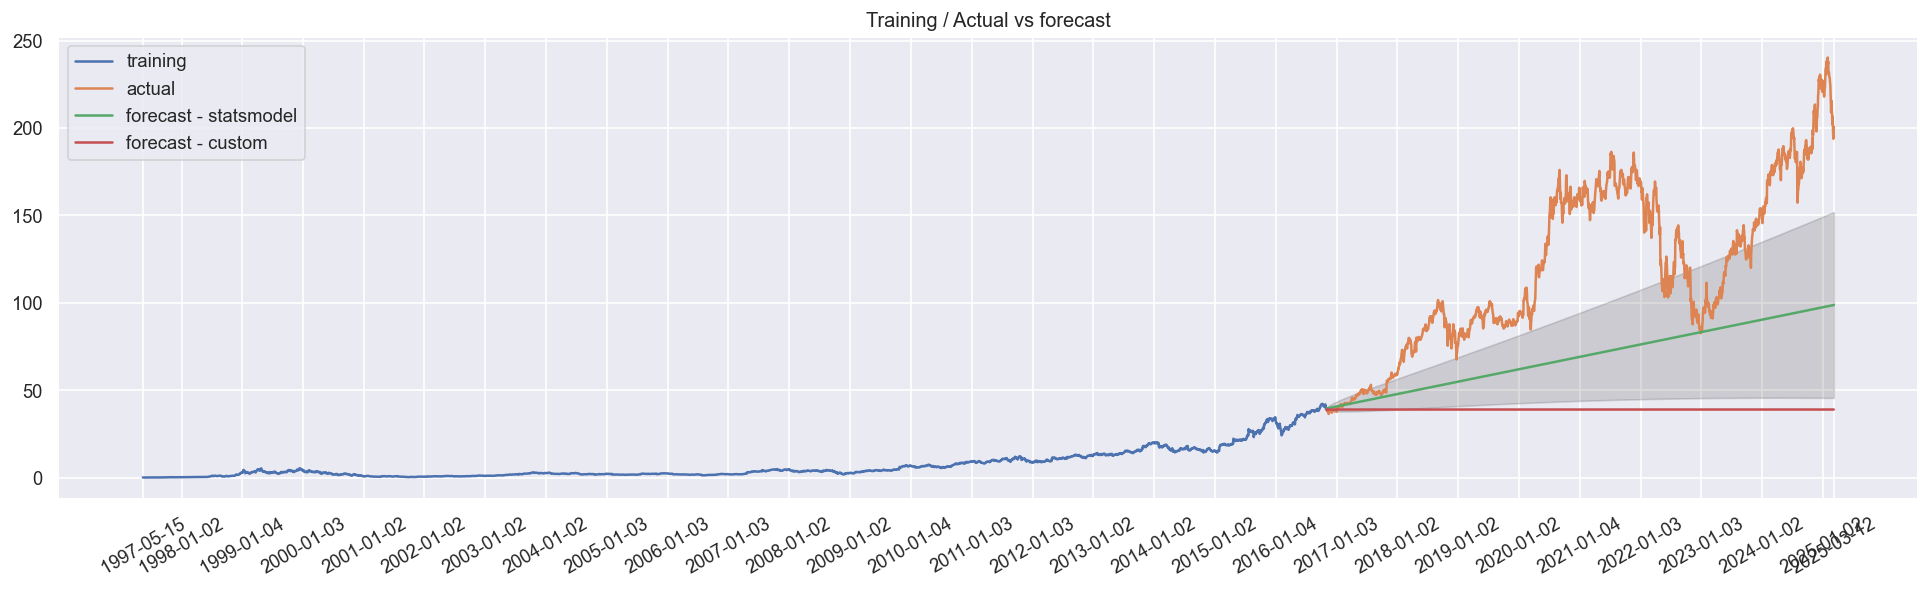

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.7


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(4, 1, 3)   Log Likelihood                1063.821
Date:                Wed, 12 Mar 2025   AIC                          -2111.642
Time:                        15:43:27   BIC                          -2059.668
Sample:                             0   HQIC                         -2093.407
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6563      0.056     11.764      0.000       0.547       0.766
ar.L2          0.3695      0.088      4.197      0.000       0.197       0.542
ar.L3         -1.0226      0.063    -16.118      0.0

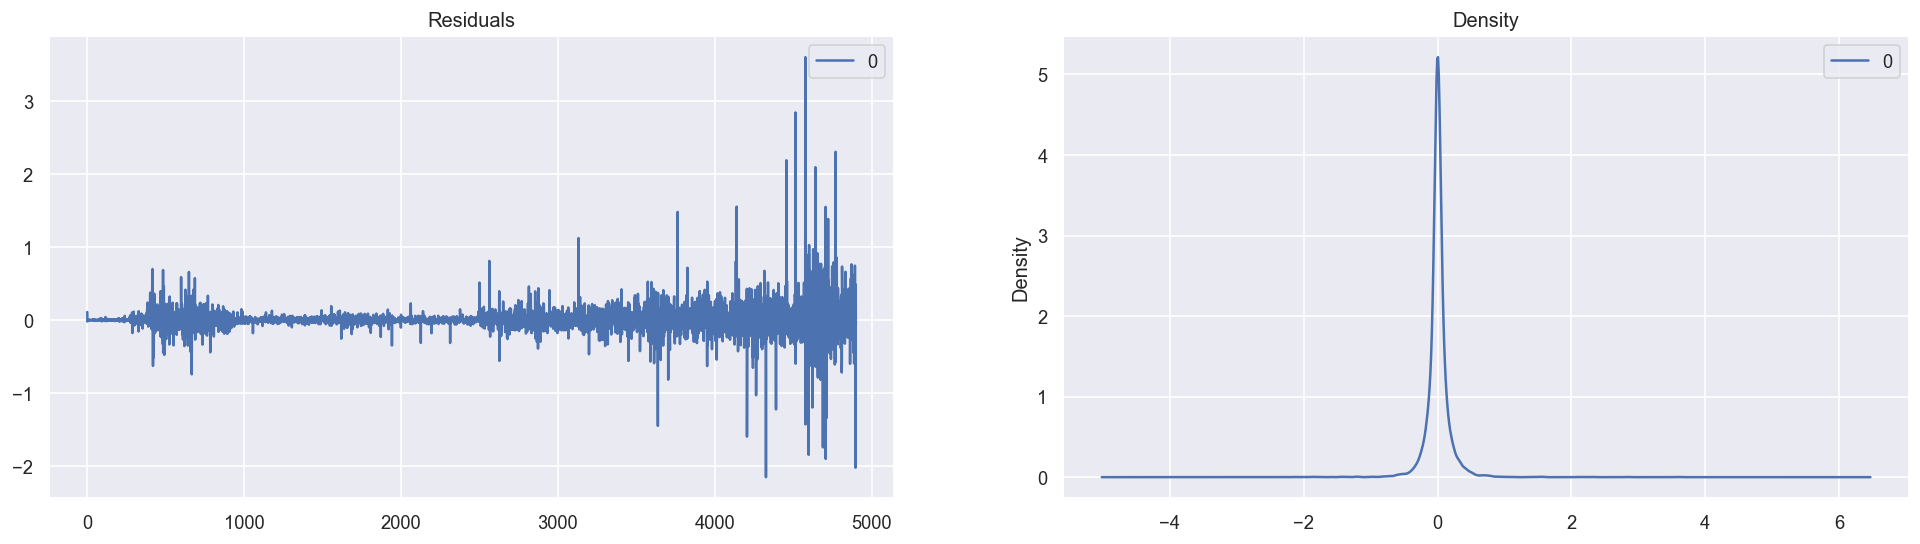

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


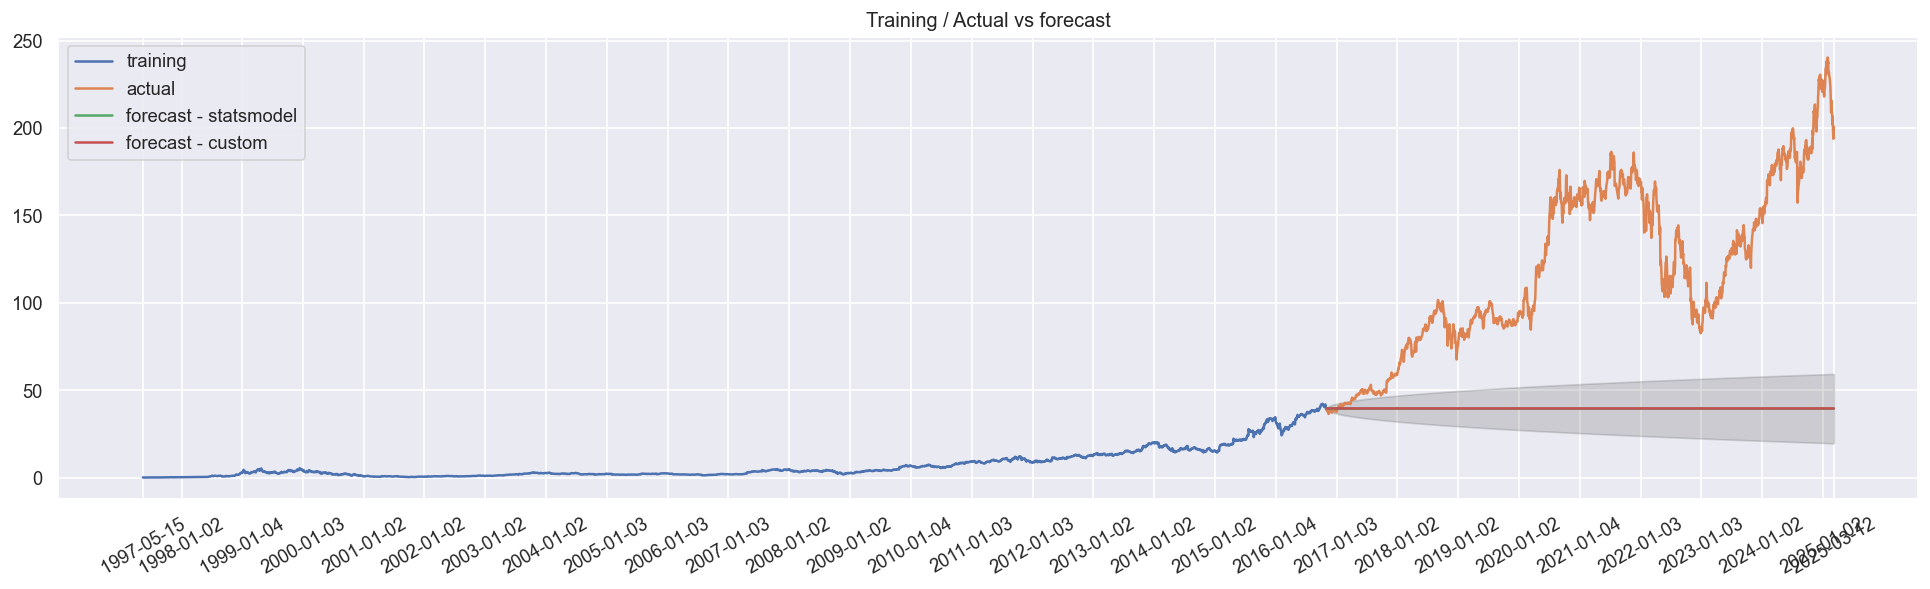

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -3409.538
Date:                Wed, 12 Mar 2025   AIC                           6829.076
Time:                        15:43:29   BIC                           6862.227
Sample:                             0   HQIC                          6840.629
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1708      0.004     46.594      0.000       0.164       0.178
ar.L2         -0.0547      0.004    -13.338      0.000      -0.063     

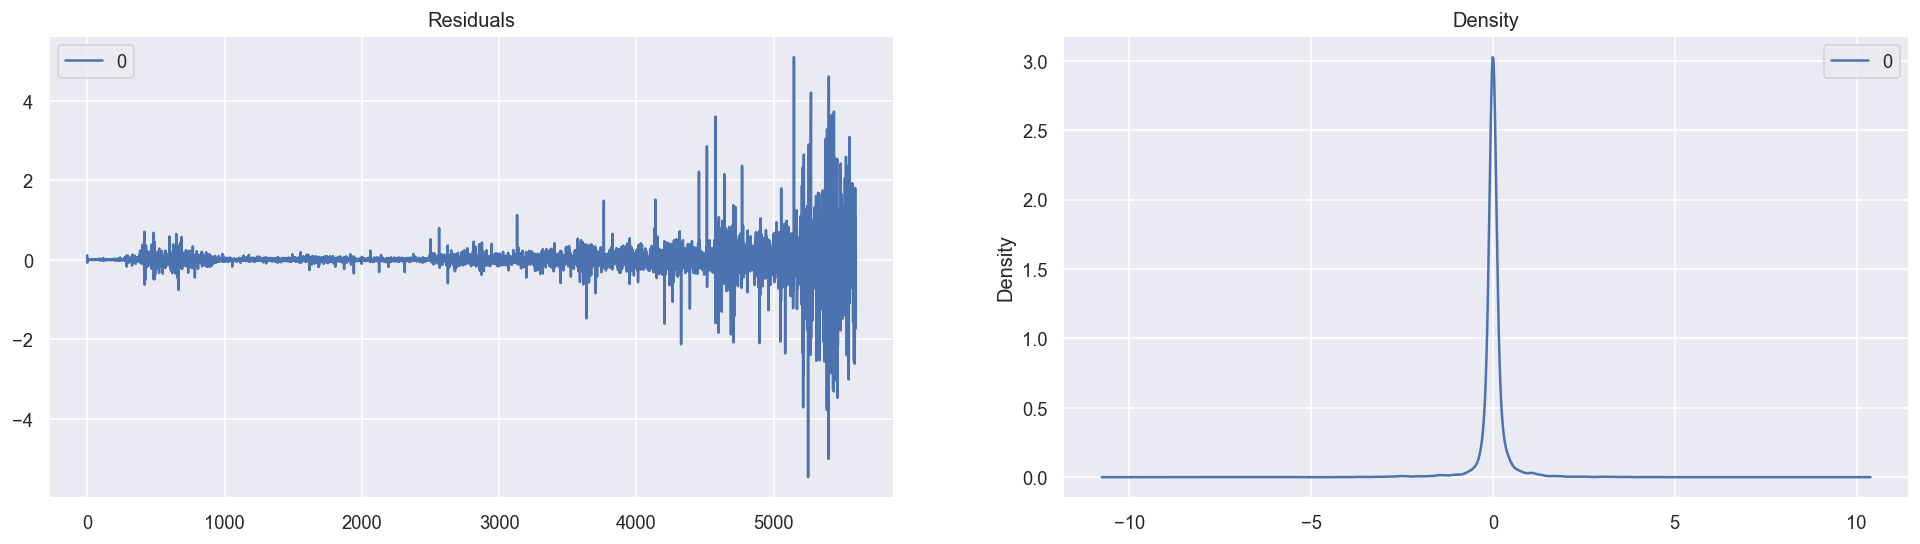

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


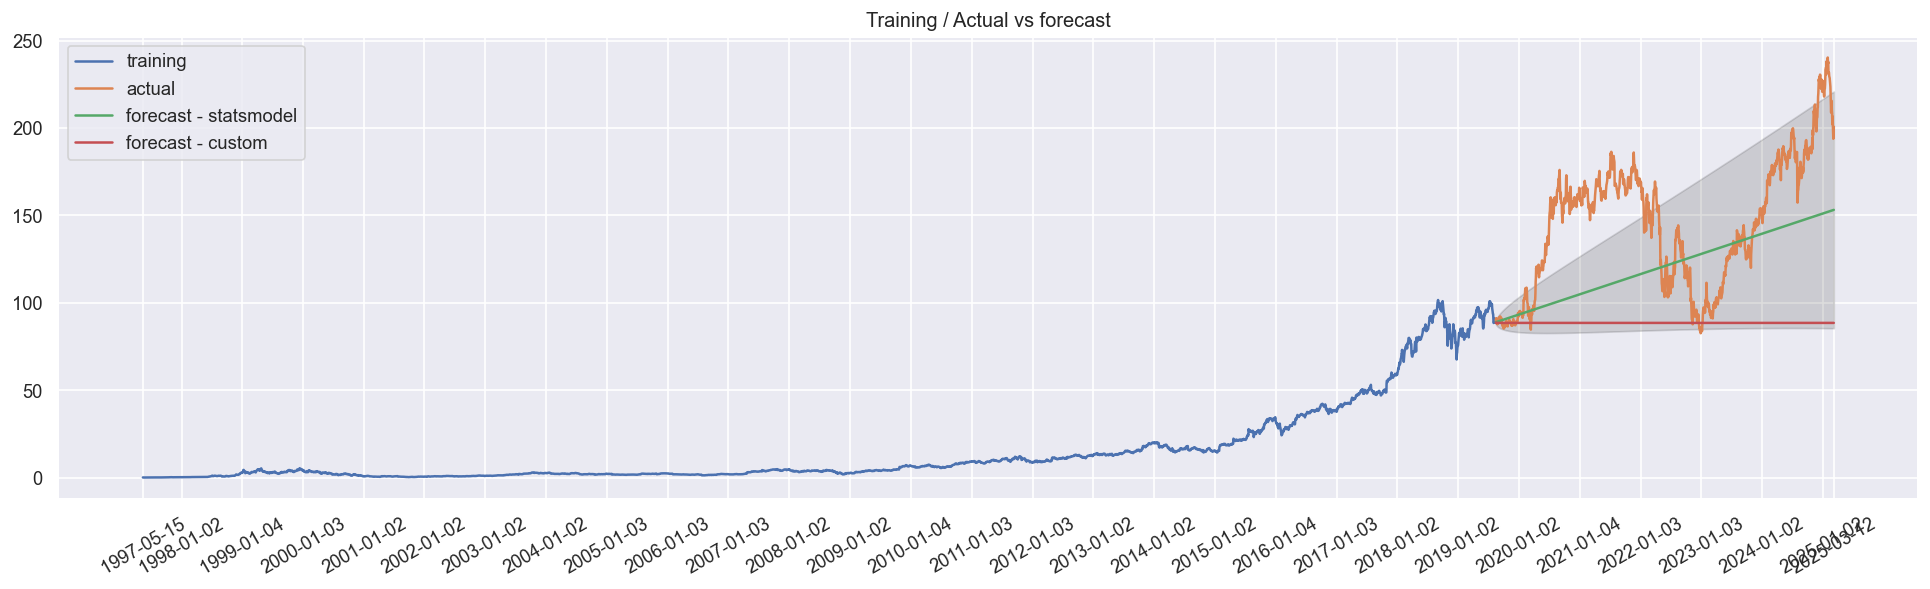

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.8


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(4, 1, 3)   Log Likelihood               -3387.653
Date:                Wed, 12 Mar 2025   AIC                           6791.306
Time:                        15:43:33   BIC                           6844.349
Sample:                             0   HQIC                          6809.790
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0149      0.008     -1.811      0.070      -0.031       0.001
ar.L2         -0.1700      0.007    -23.000      0.000      -0.185      -0.156
ar.L3         -0.9454      0.008   -115.028      0.0

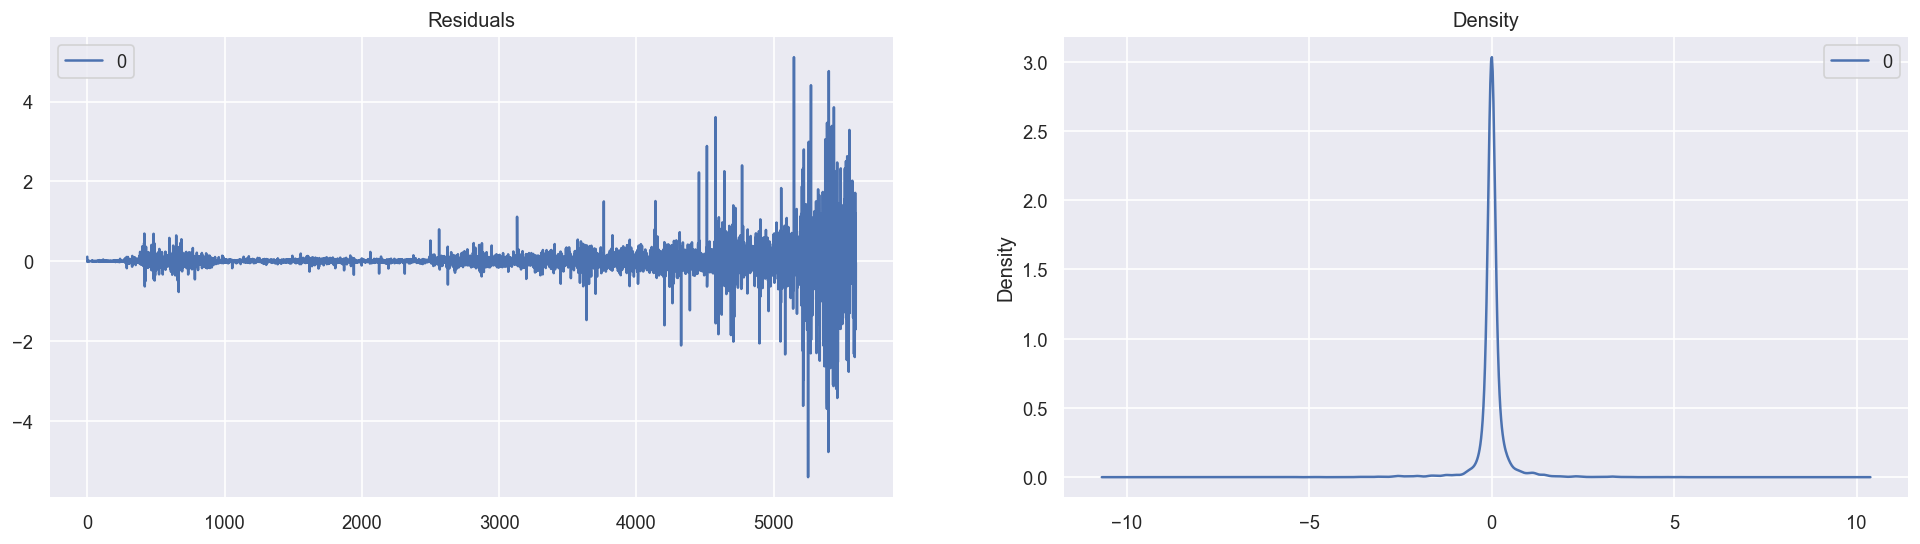

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


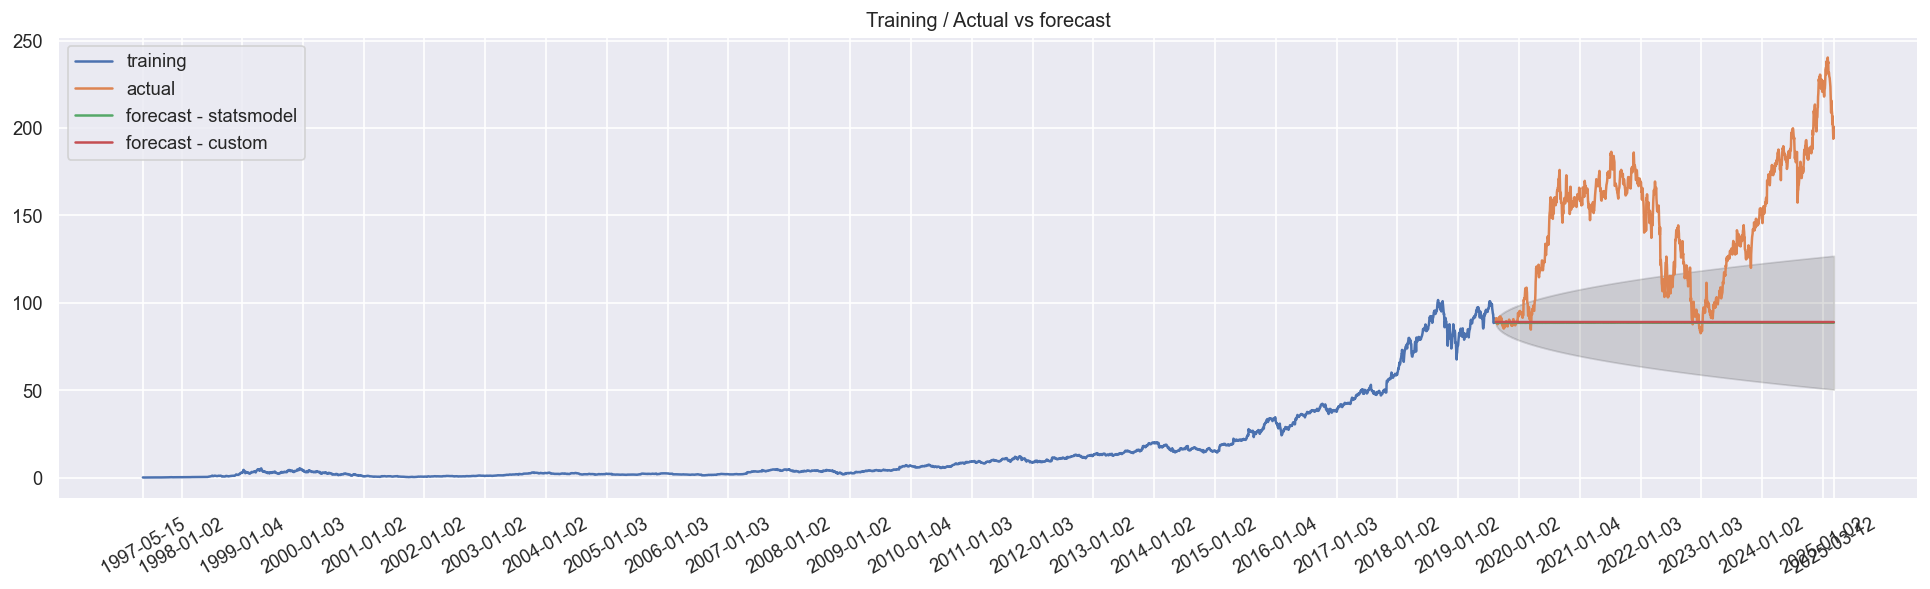

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6300
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -8542.729
Date:                Wed, 12 Mar 2025   AIC                          17095.457
Time:                        15:43:35   BIC                          17129.197
Sample:                             0   HQIC                         17107.145
                               - 6300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1928      0.004     48.084      0.000       0.185       0.201
ar.L2         -0.0792      0.005    -14.697      0.000      -0.090     

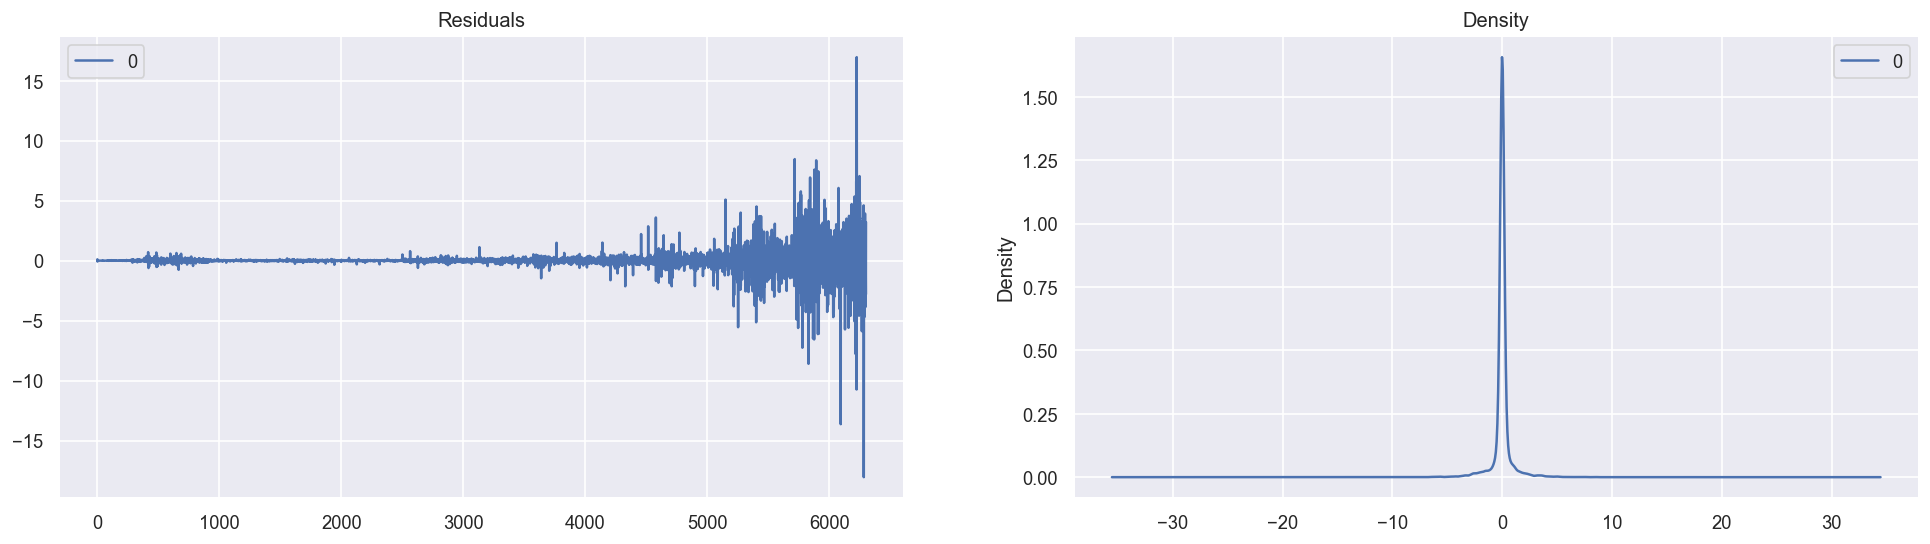

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


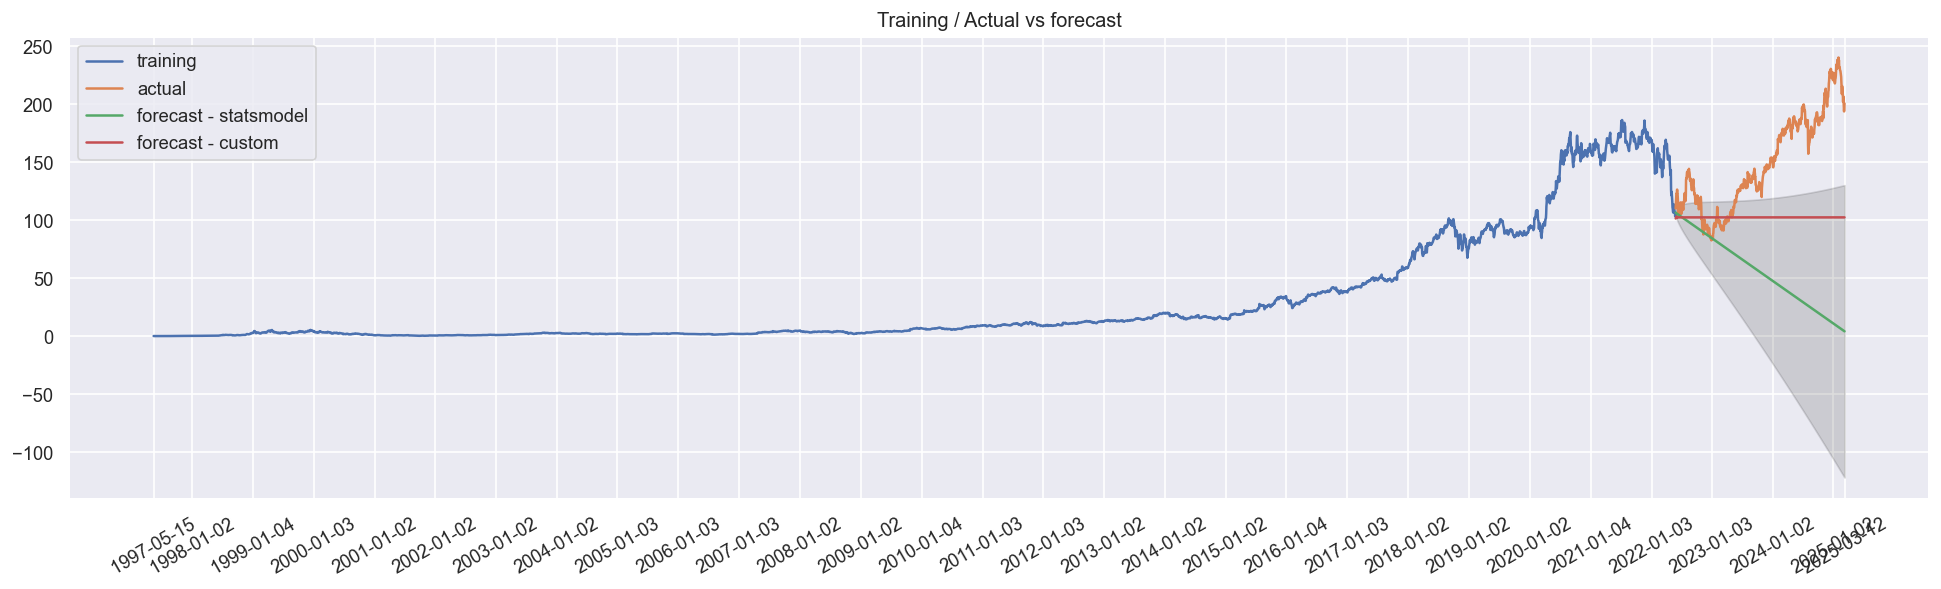

/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
/var/folders/04/b5_9lzx5797dzscx6rwj46k80000gr/T/ipykernel_11433/2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: 

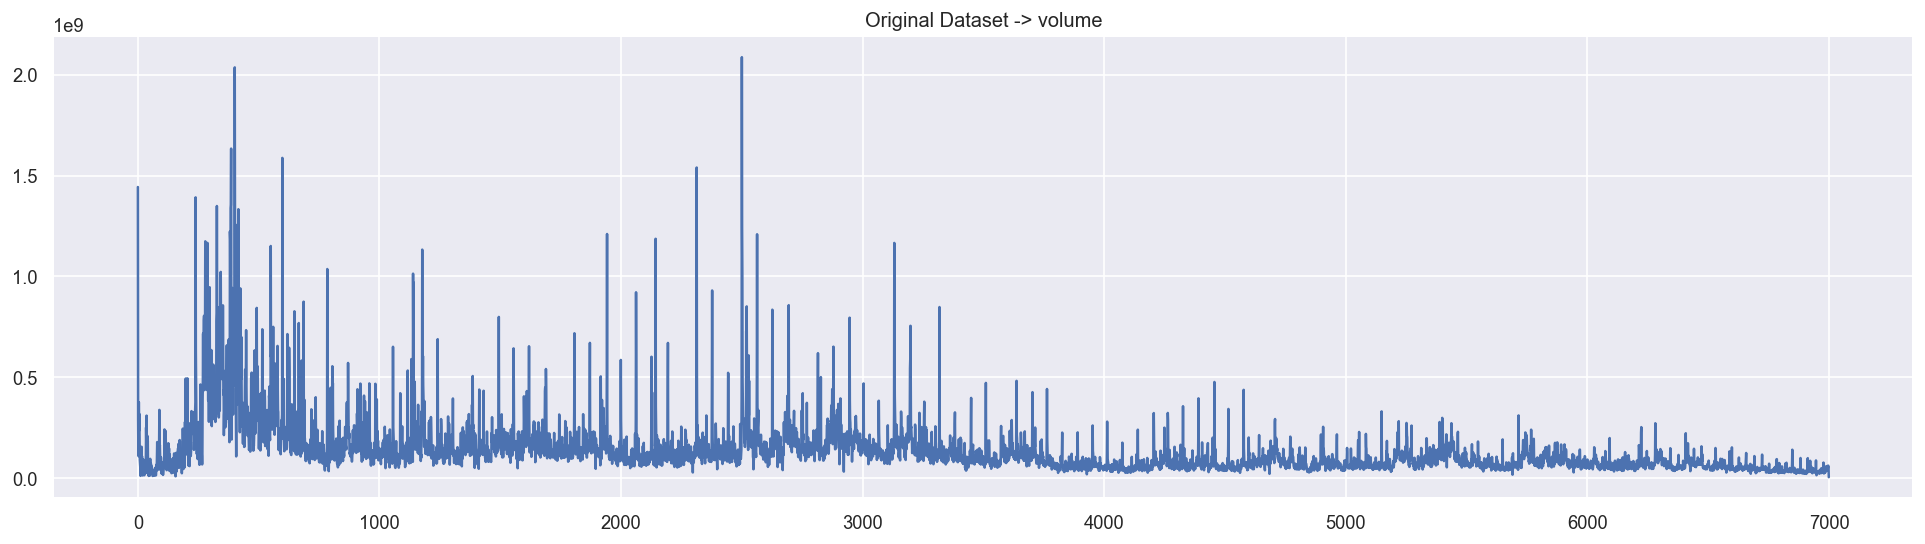

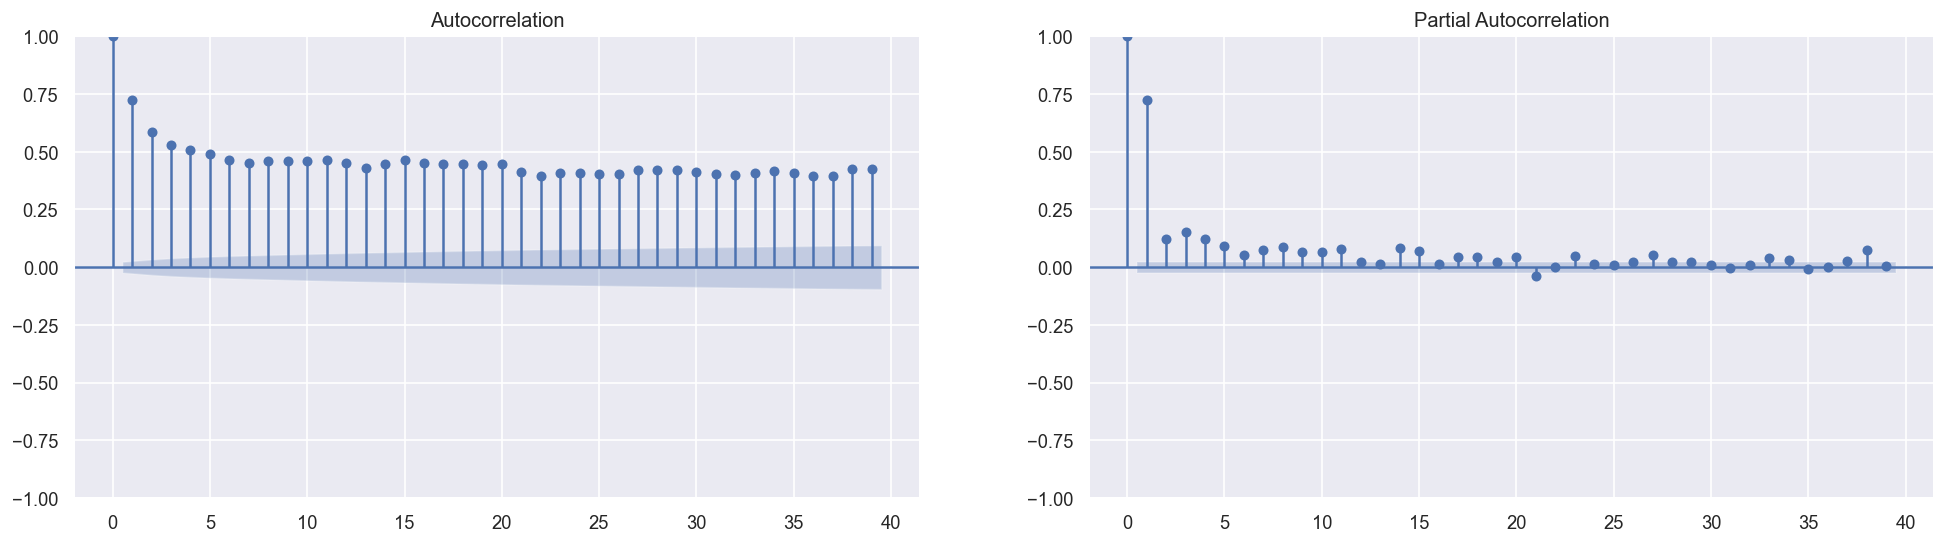

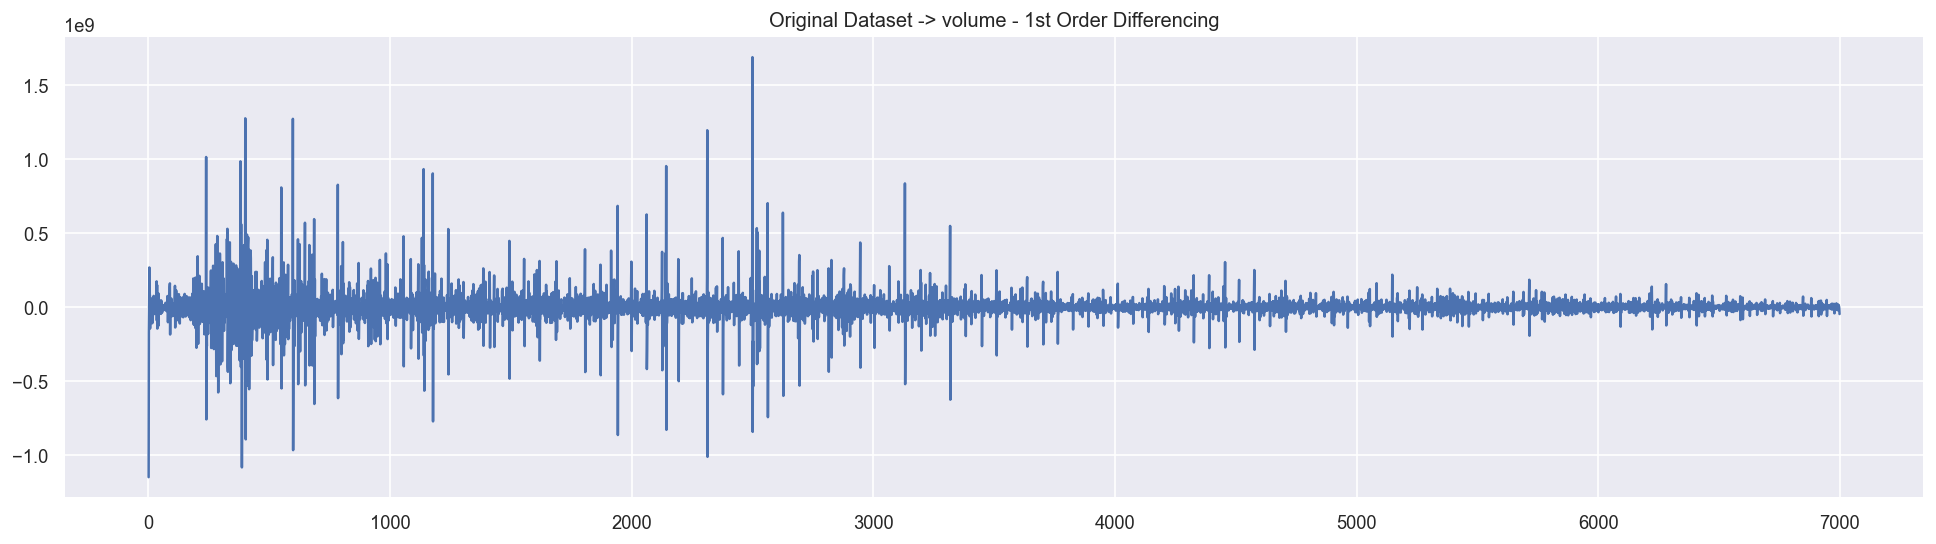

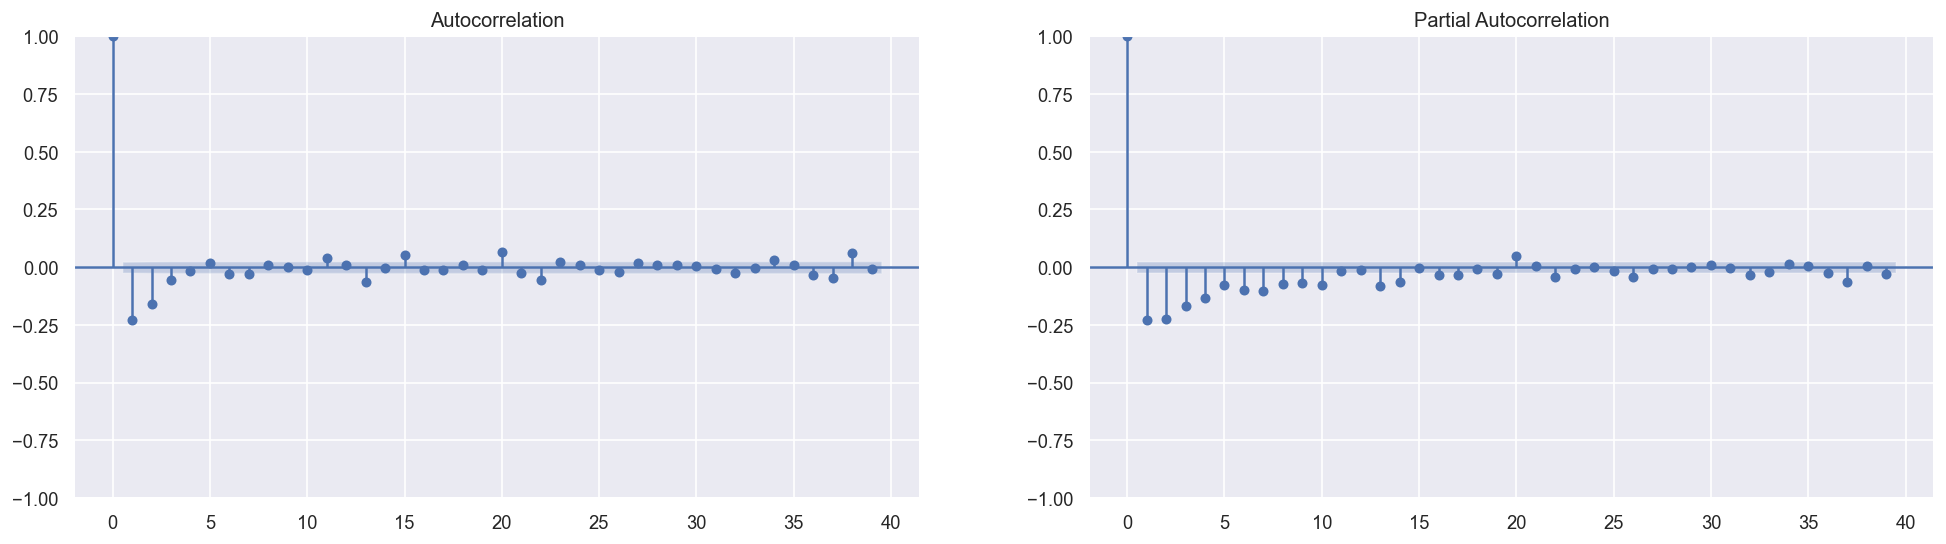

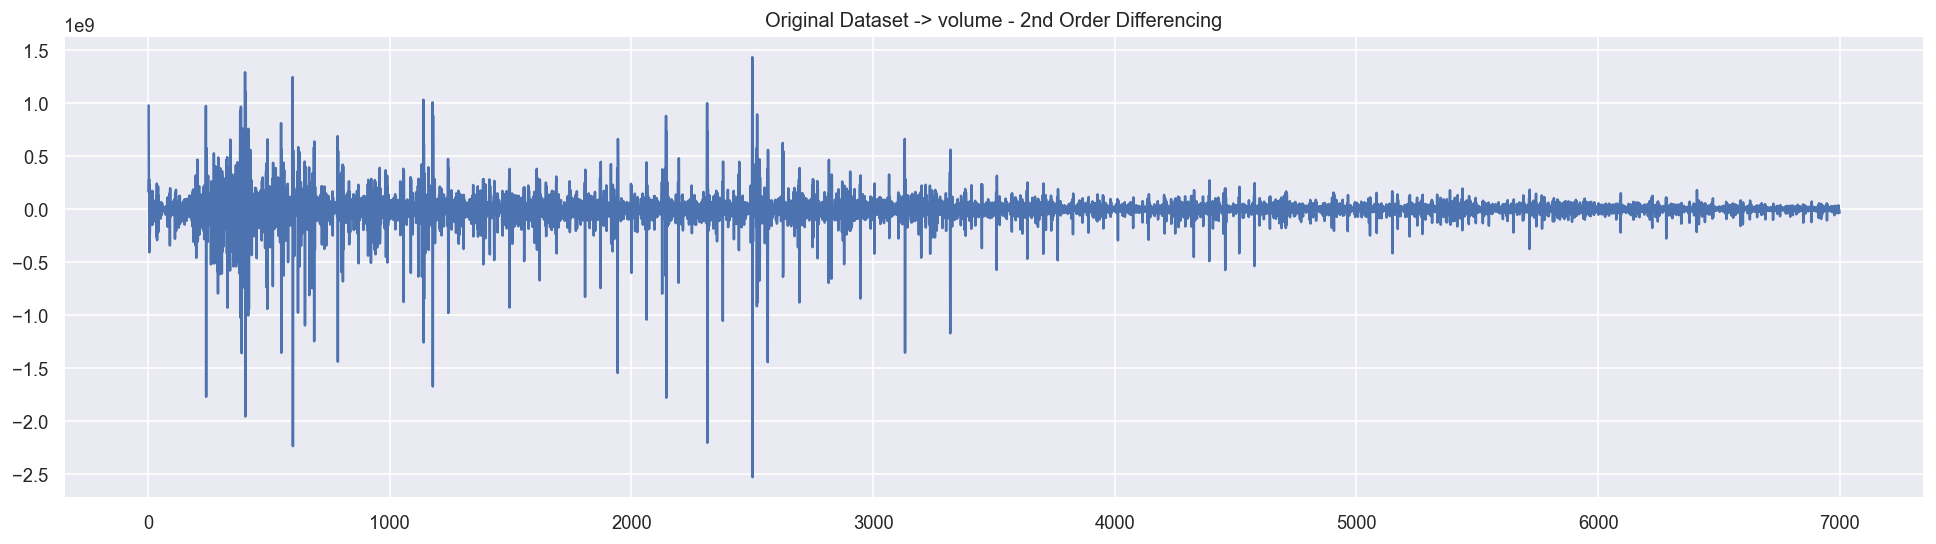

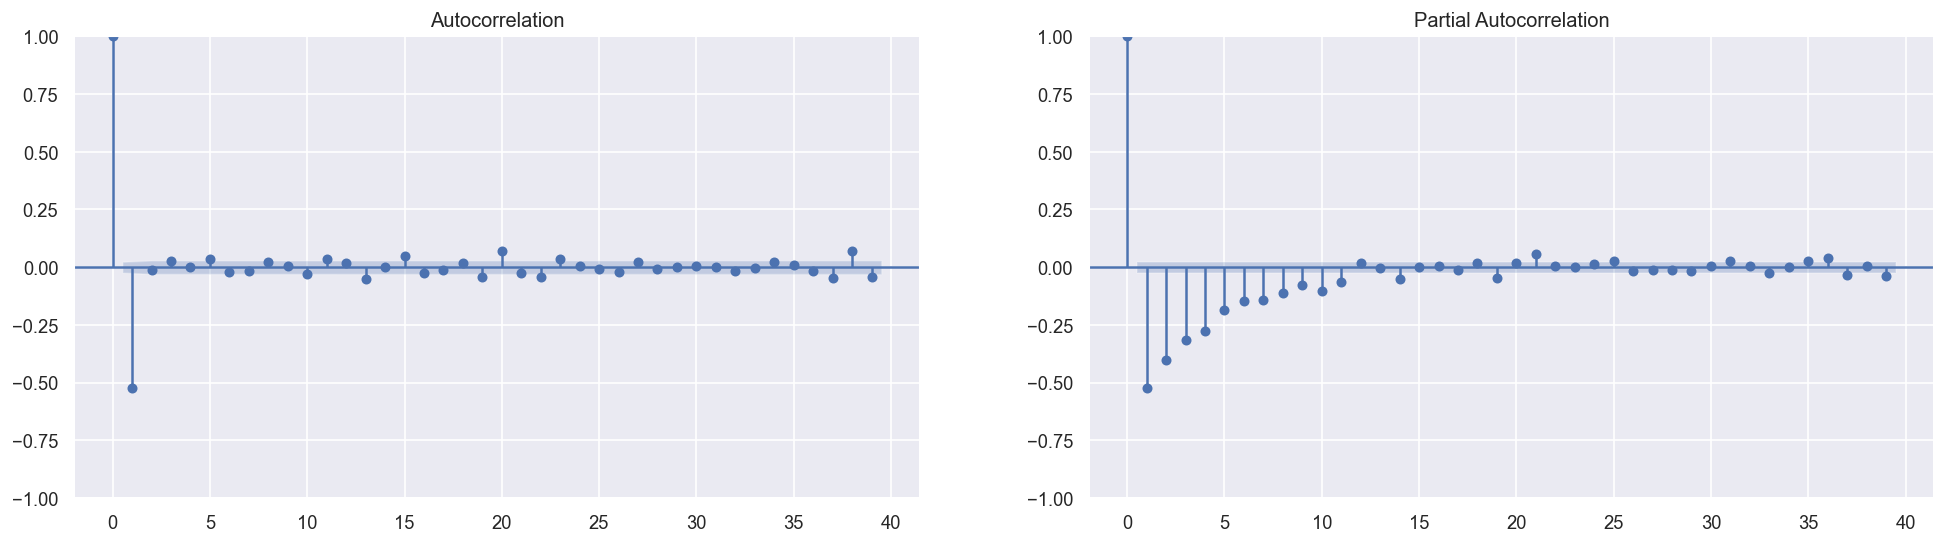

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -97416.313
Date:                Wed, 12 Mar 2025   AIC                         194840.627
Time:                        15:43:37   BIC                         194866.614
Sample:                             0   HQIC                        194849.744
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4634      0.016     29.383      0.000       0.432       0.494
ma.L1         -0.9243      0.017    -53.684      0.000      -0.958     

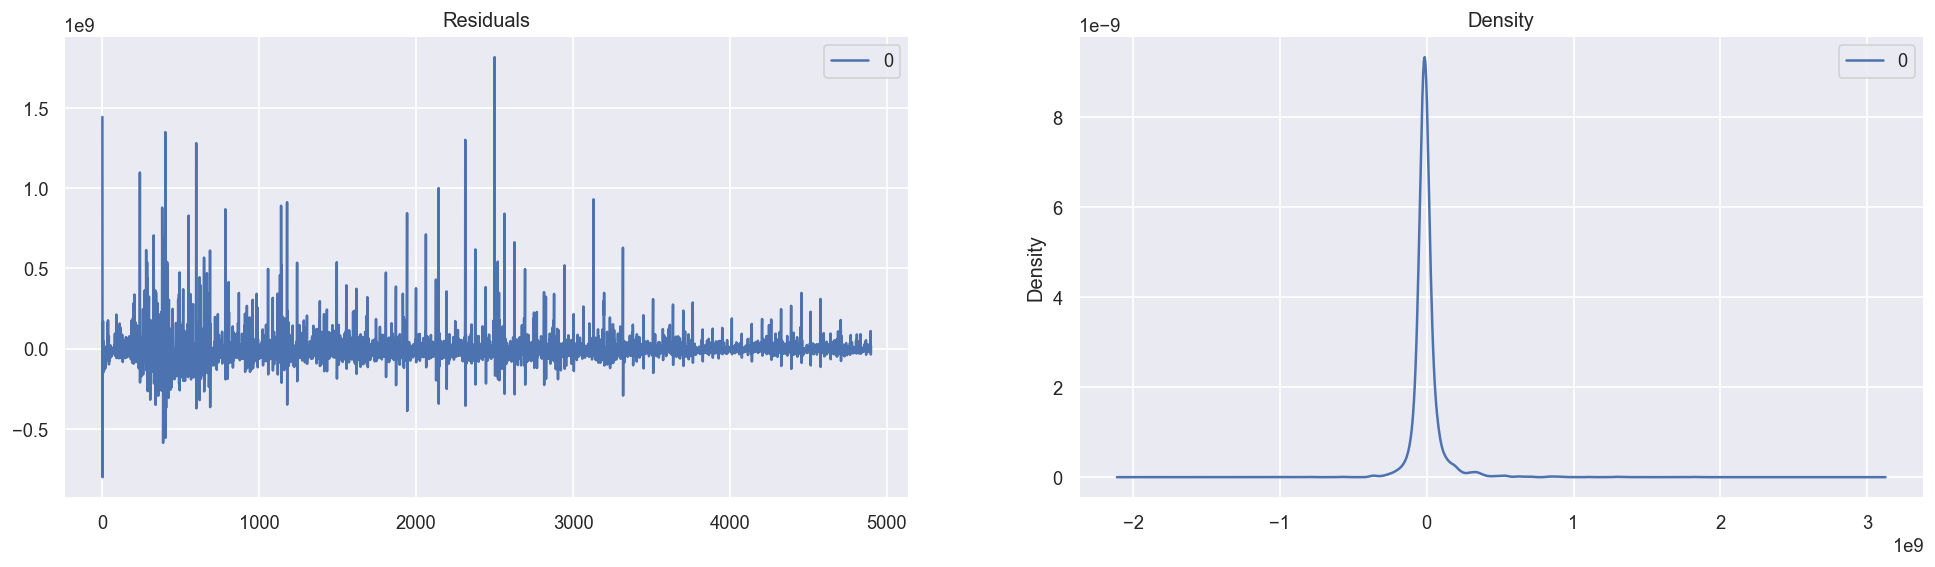

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


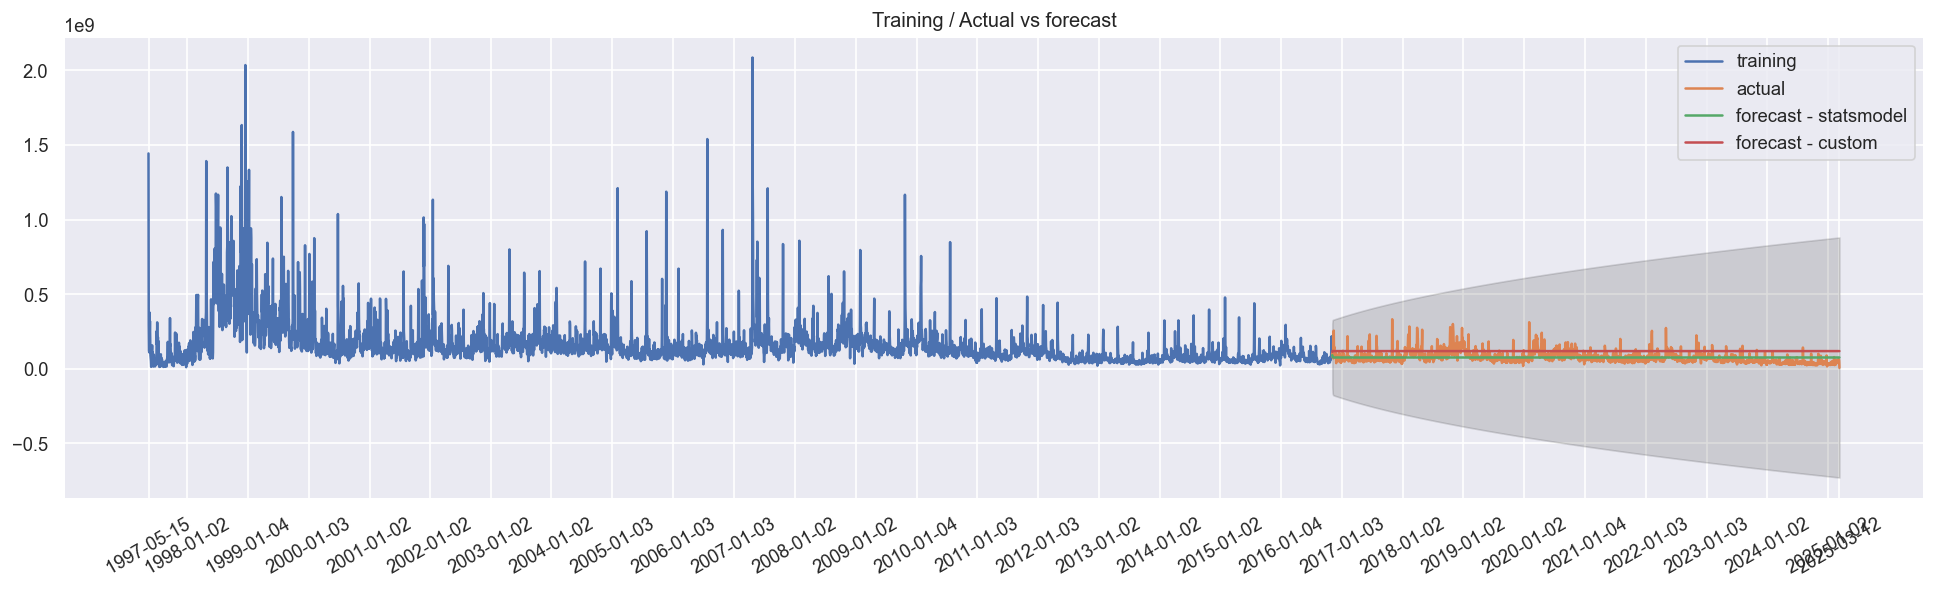

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -97423.051
Date:                Wed, 12 Mar 2025   AIC                         194852.101
Time:                        15:43:38   BIC                         194871.591
Sample:                             0   HQIC                        194858.939
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4925      0.007     70.589      0.000       0.479       0.506
ma.L1         -0.9608      0.003   -319.344      0.000      -0.967     

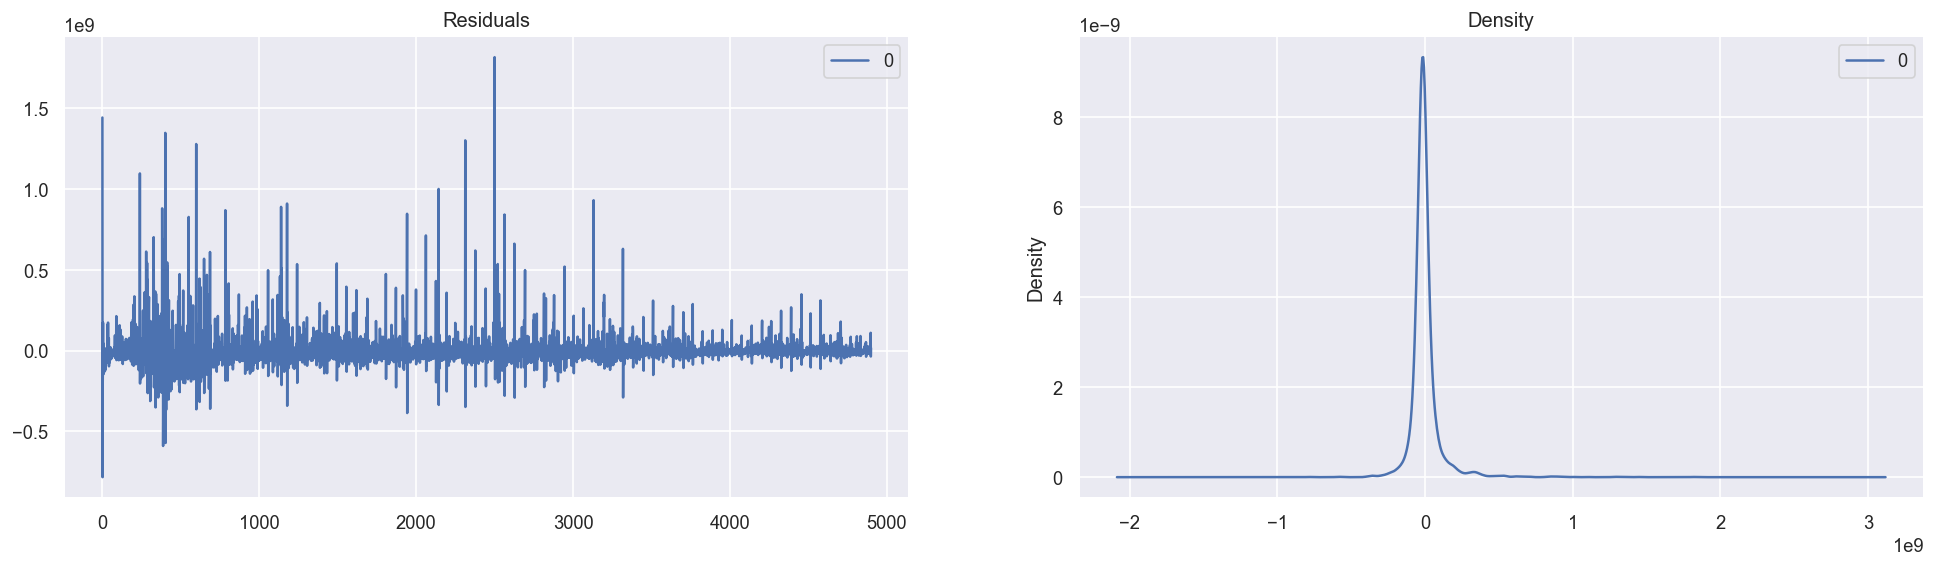

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


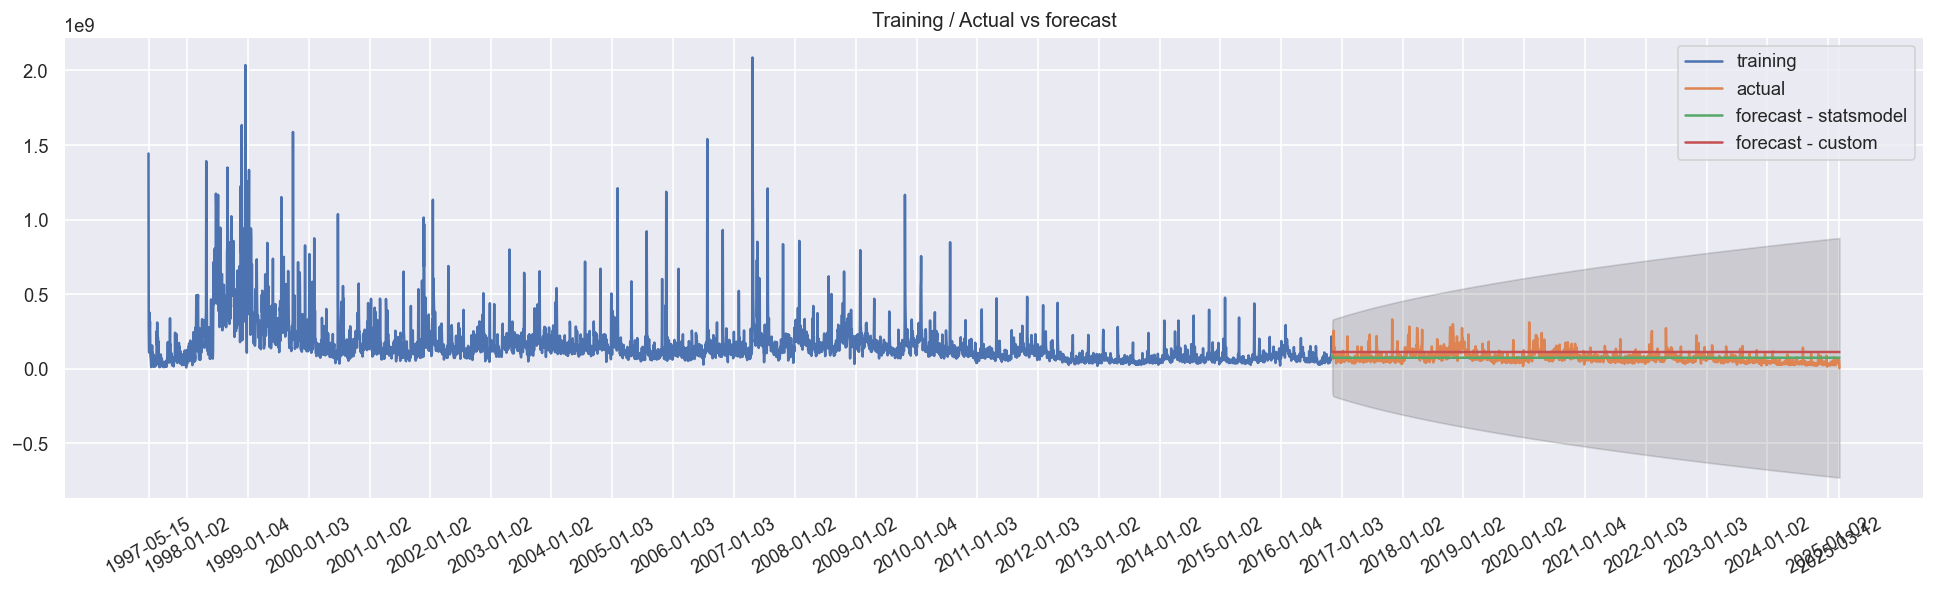

Train / Test based on:
order -> (3, 3, 3)
train_rate -> 0.7


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 3, 3)   Log Likelihood              -98009.177
Date:                Wed, 12 Mar 2025   AIC                         196032.354
Time:                        15:43:41   BIC                         196077.829
Sample:                             0   HQIC                        196048.309
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2791      0.009   -134.917      0.000      -1.298      -1.261
ar.L2         -0.5033      0.015    -33.618      0.000      -0.533      -0.474
ar.L3         -0.2236      0.010    -22.133      0.0

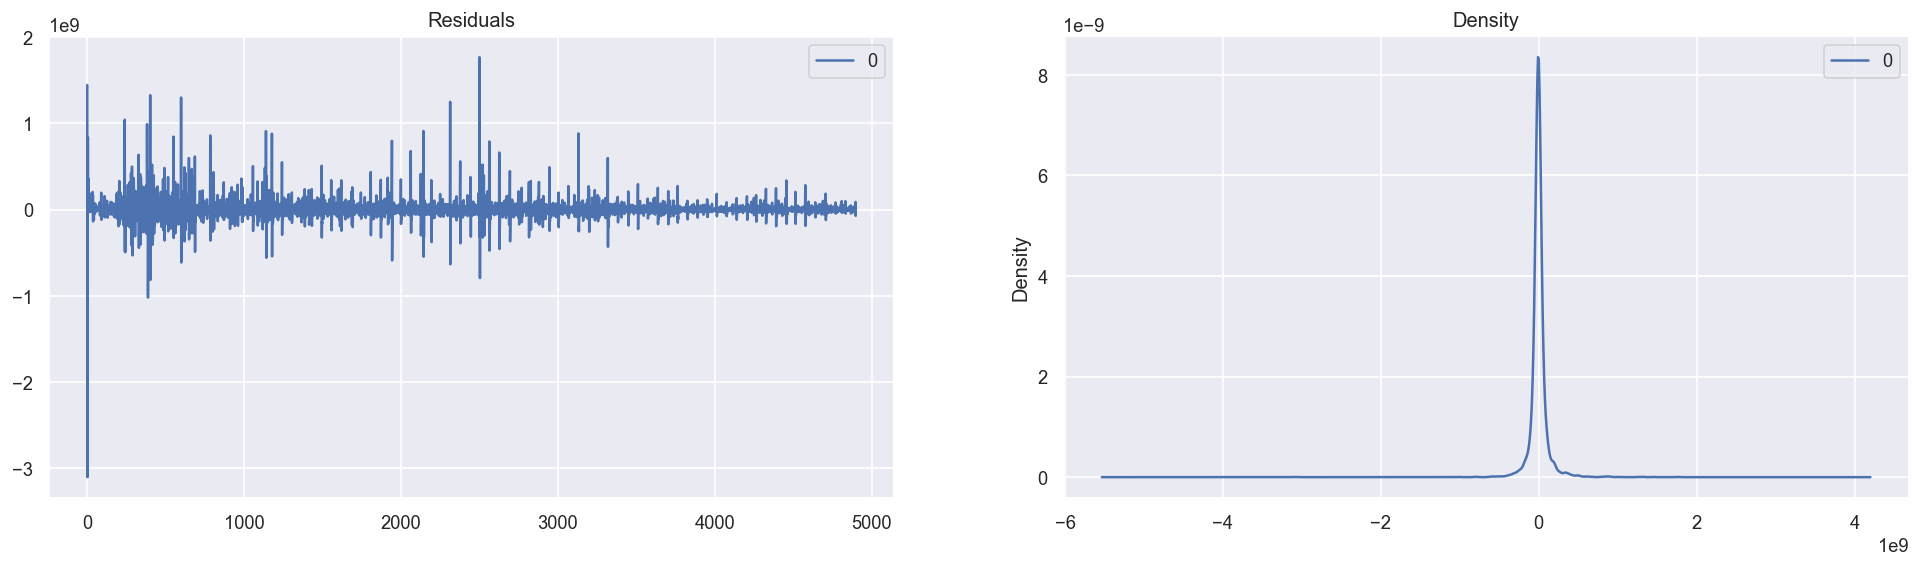

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


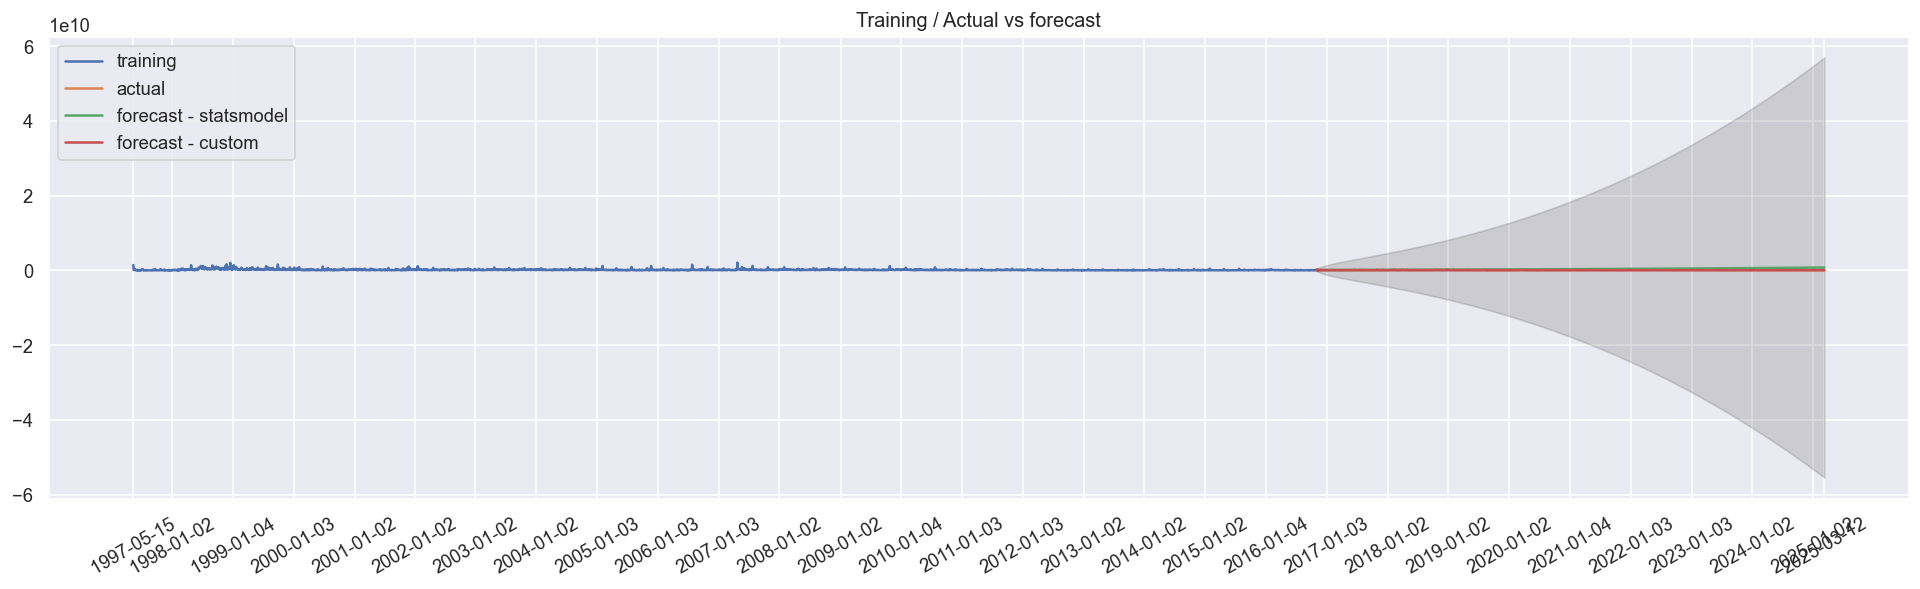

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 1)   Log Likelihood              -97820.613
Date:                Wed, 12 Mar 2025   AIC                         195651.225
Time:                        15:43:43   BIC                         195683.708
Sample:                             0   HQIC                        195662.622
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3250      0.008    -41.070      0.000      -0.340      -0.309
ar.L2         -0.2859      0.010    -29.203      0.000      -0.305     

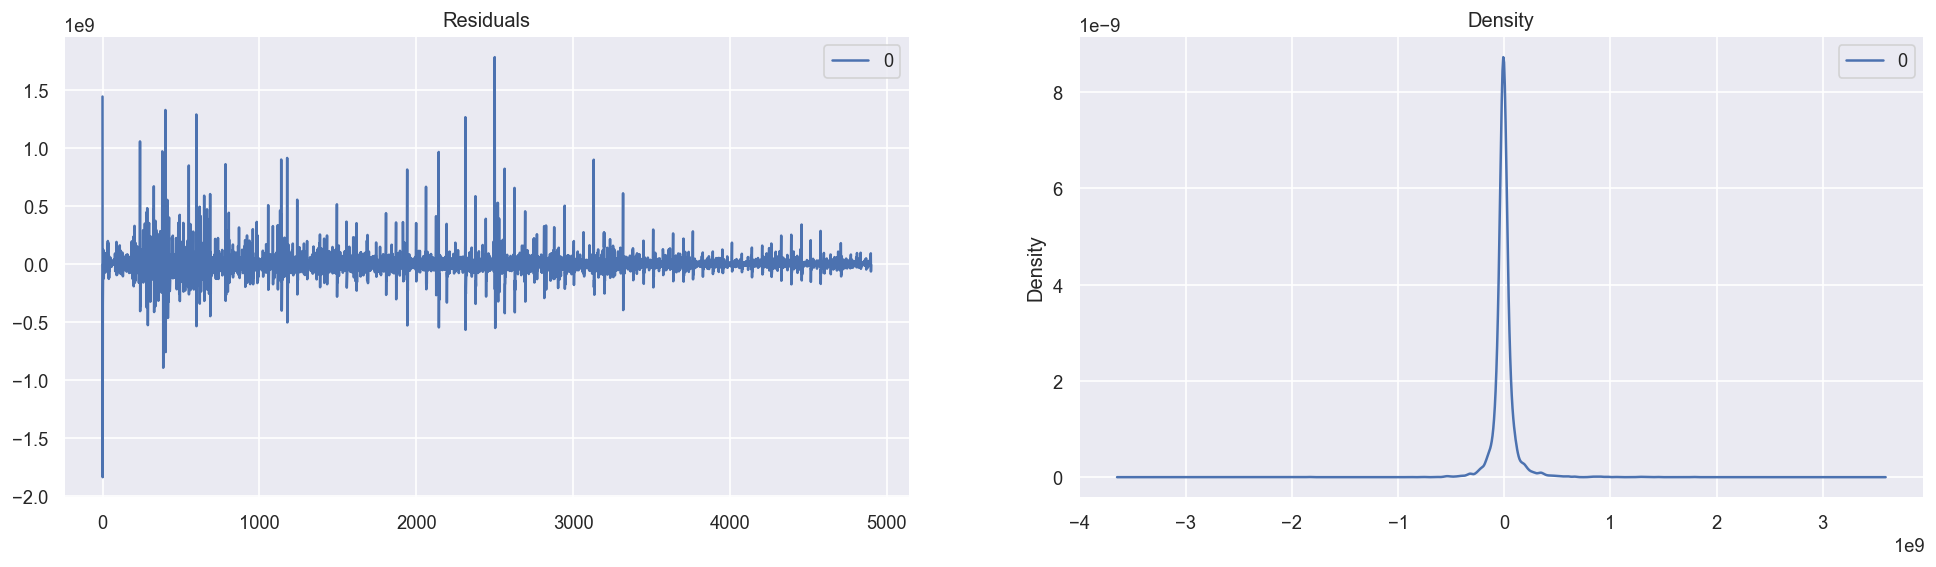

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


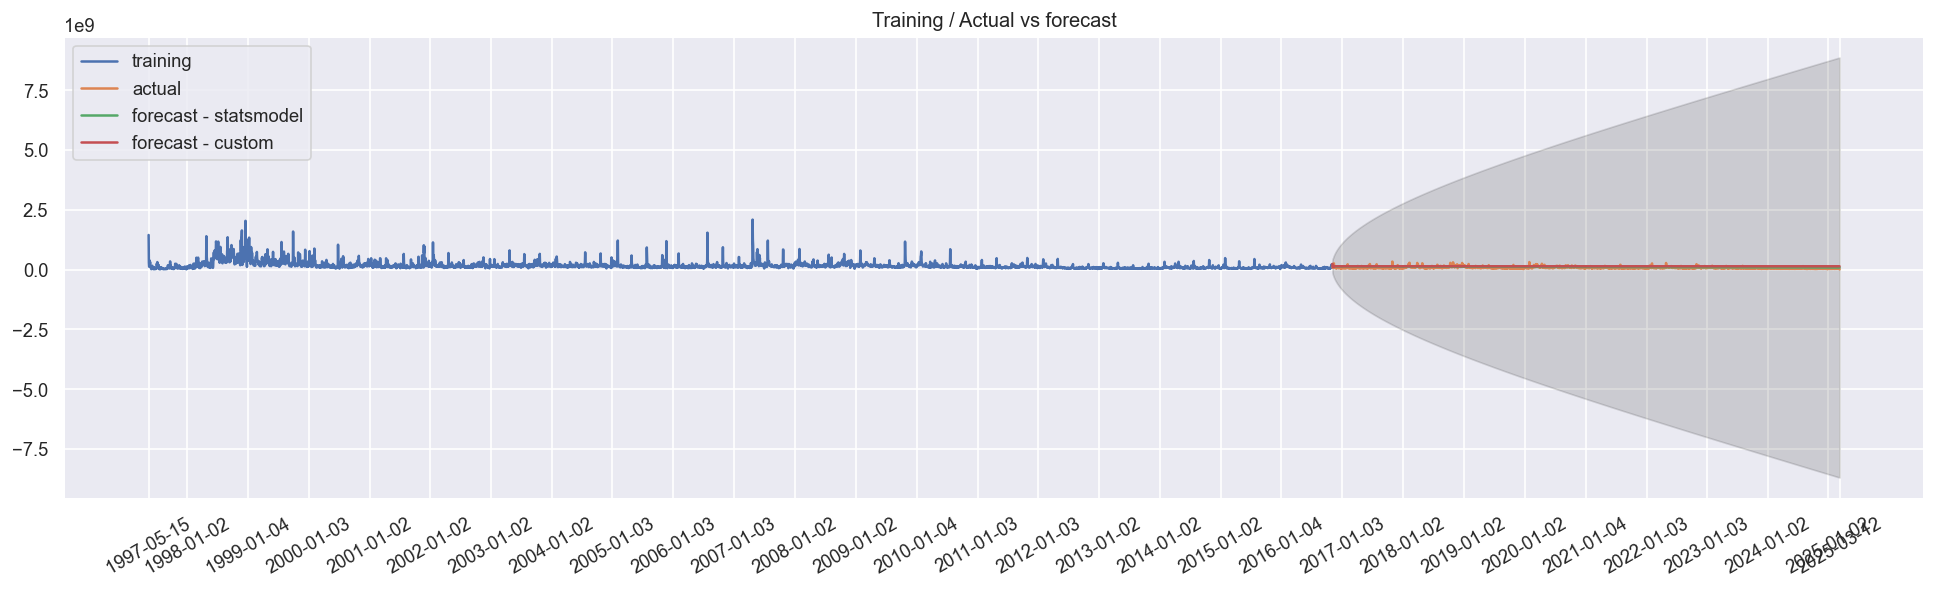

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.7


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(4, 1, 3)   Log Likelihood              -97407.946
Date:                Wed, 12 Mar 2025   AIC                         194831.893
Time:                        15:43:47   BIC                         194883.867
Sample:                             0   HQIC                        194850.128
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1468      0.192     -0.764      0.445      -0.524       0.230
ar.L2          0.6366      0.097      6.540      0.000       0.446       0.827
ar.L3         -0.1580      0.094     -1.677      0.0

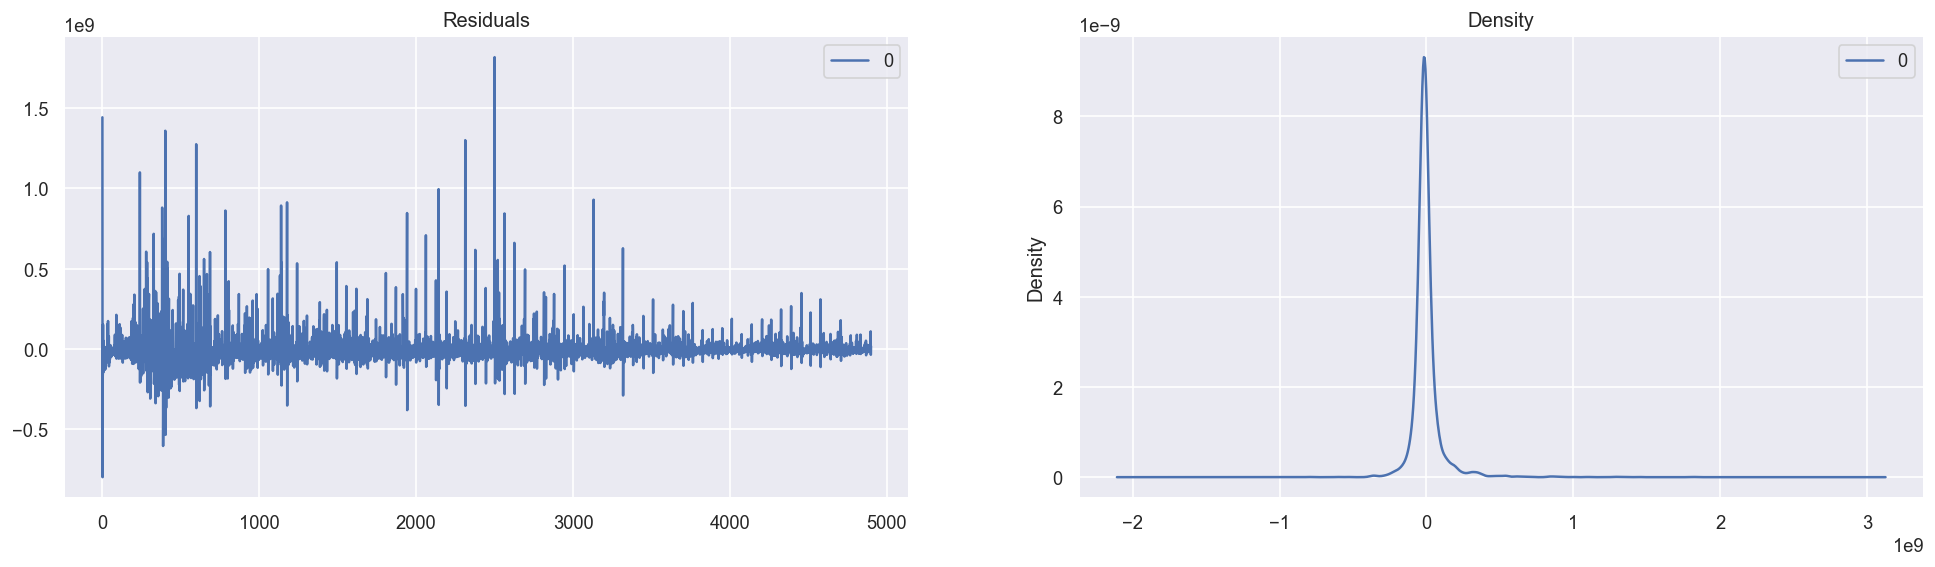

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


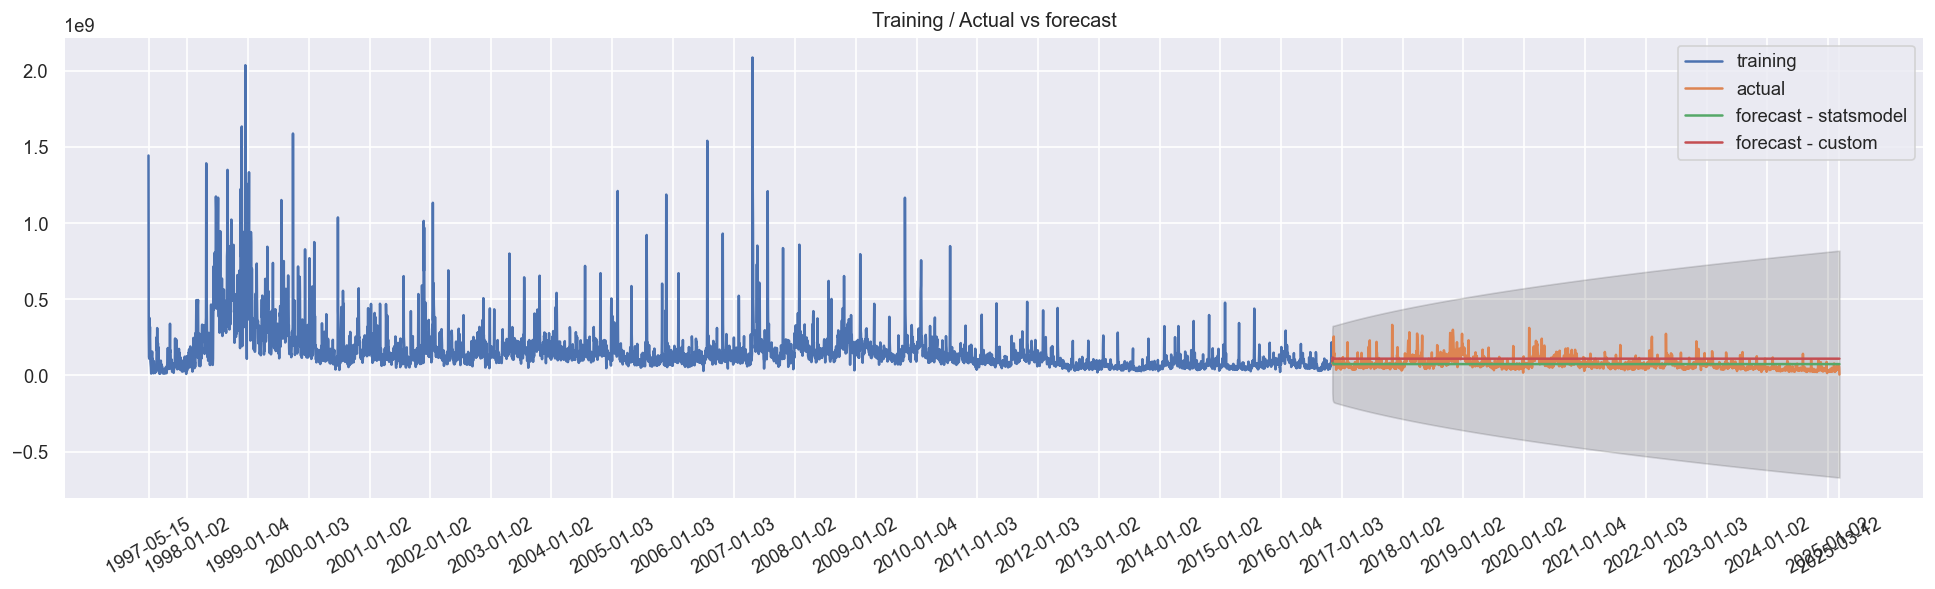

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -111462.115
Date:                Wed, 12 Mar 2025   AIC                         222934.231
Time:                        15:43:49   BIC                         222967.381
Sample:                             0   HQIC                        222945.783
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.007    -46.323      0.000      -0.338      -0.311
ar.L2         -0.2856      0.009    -32.958      0.000      -0.303     

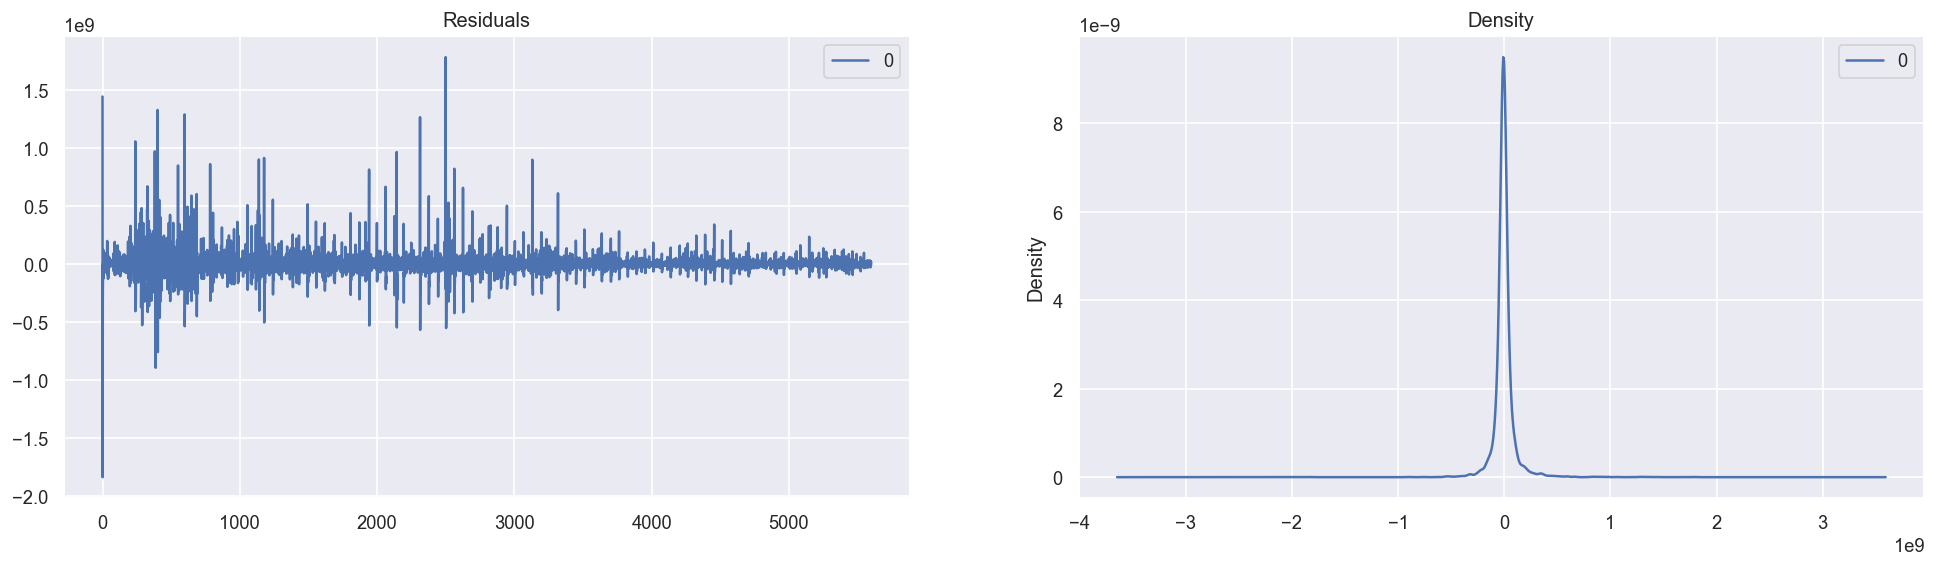

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


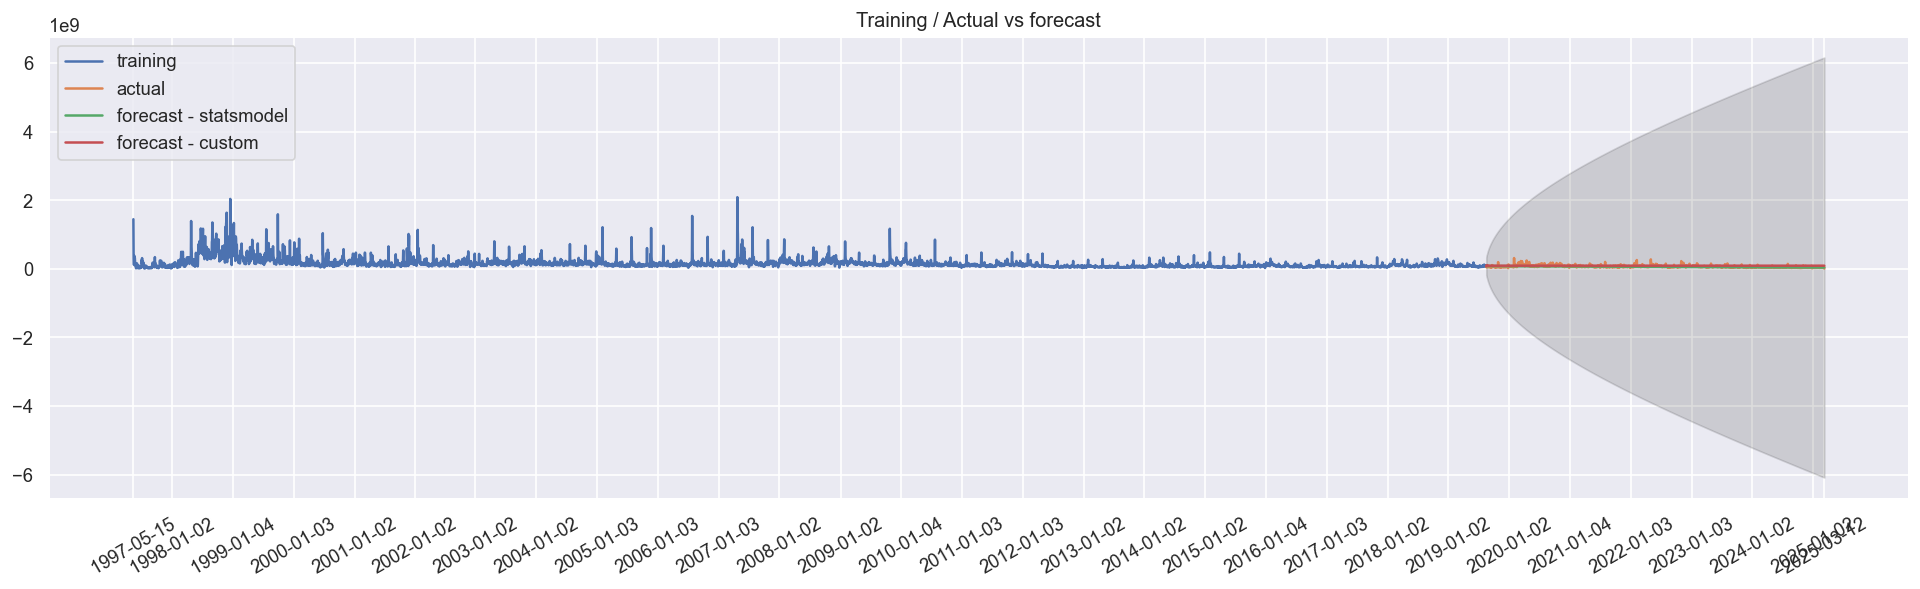

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.8


/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(4, 1, 3)   Log Likelihood             -110989.696
Date:                Wed, 12 Mar 2025   AIC                         221995.392
Time:                        15:43:53   BIC                         222048.434
Sample:                             0   HQIC                        222013.876
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1470      0.169     -0.872      0.383      -0.477       0.183
ar.L2          0.6362      0.085      7.474      0.000       0.469       0.803
ar.L3         -0.1571      0.083     -1.897      0.0

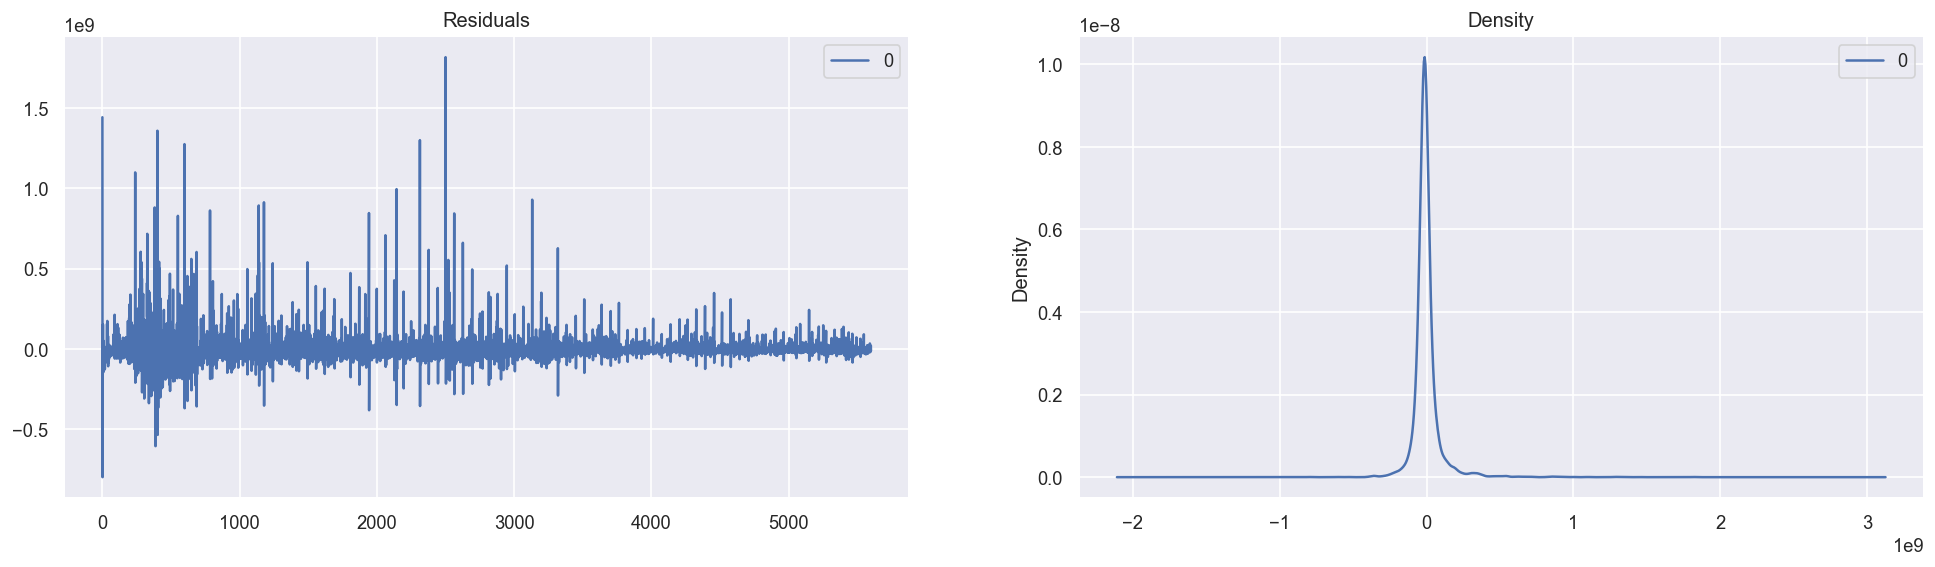

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


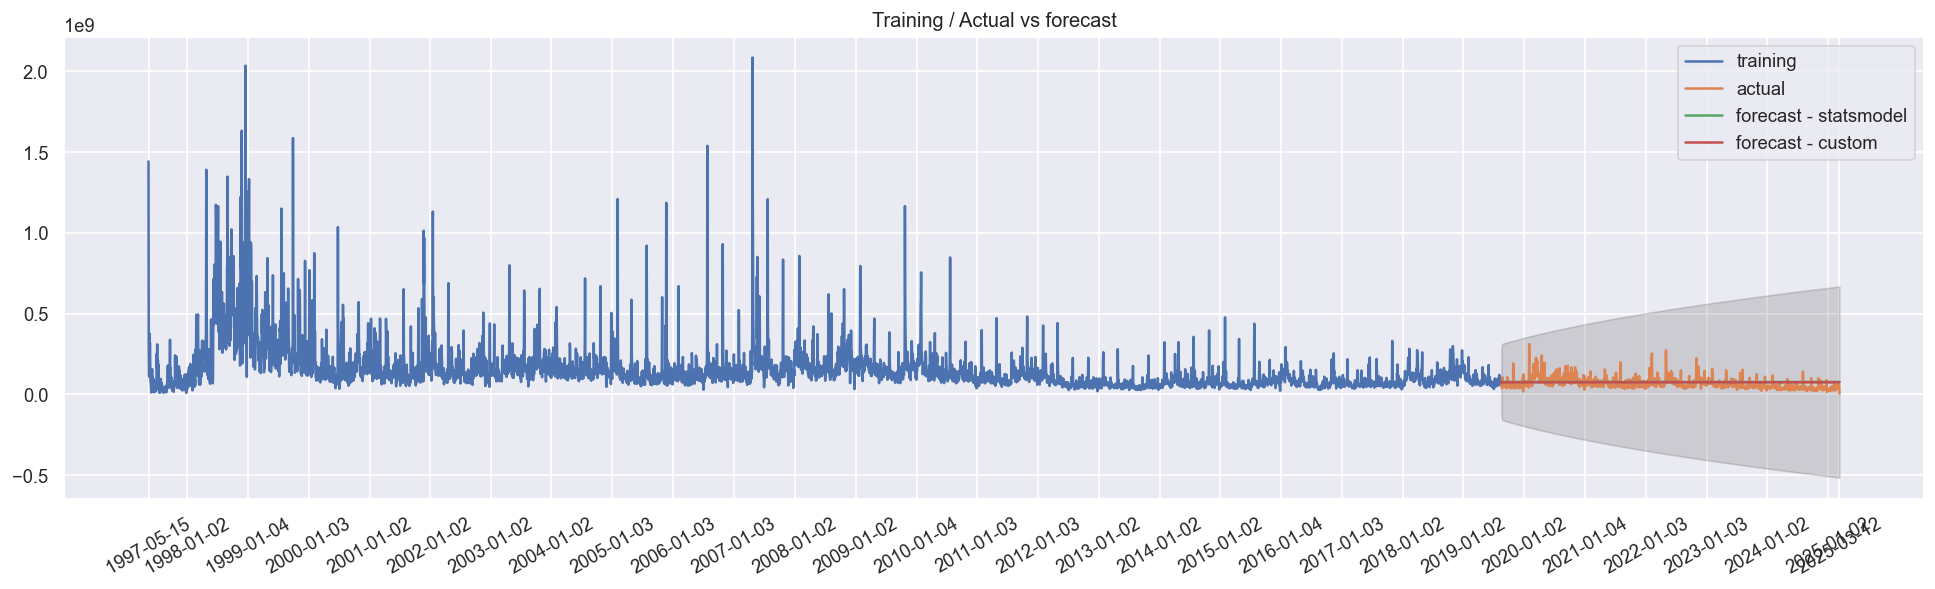

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6300
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -125058.373
Date:                Wed, 12 Mar 2025   AIC                         250126.745
Time:                        15:43:56   BIC                         250160.485
Sample:                             0   HQIC                        250138.434
                               - 6300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.006    -51.595      0.000      -0.337      -0.312
ar.L2         -0.2859      0.008    -36.767      0.000      -0.301     

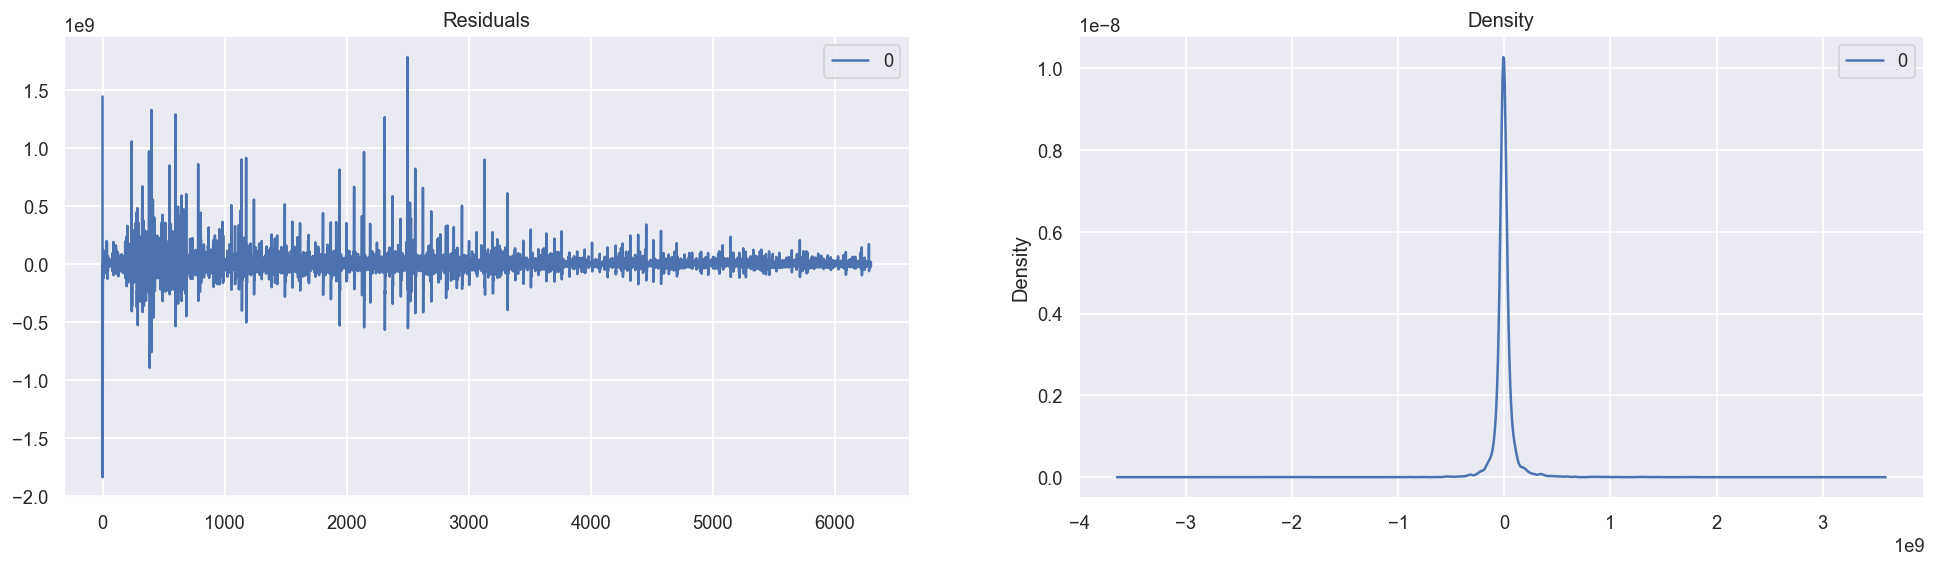

/Users/scohen6/projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


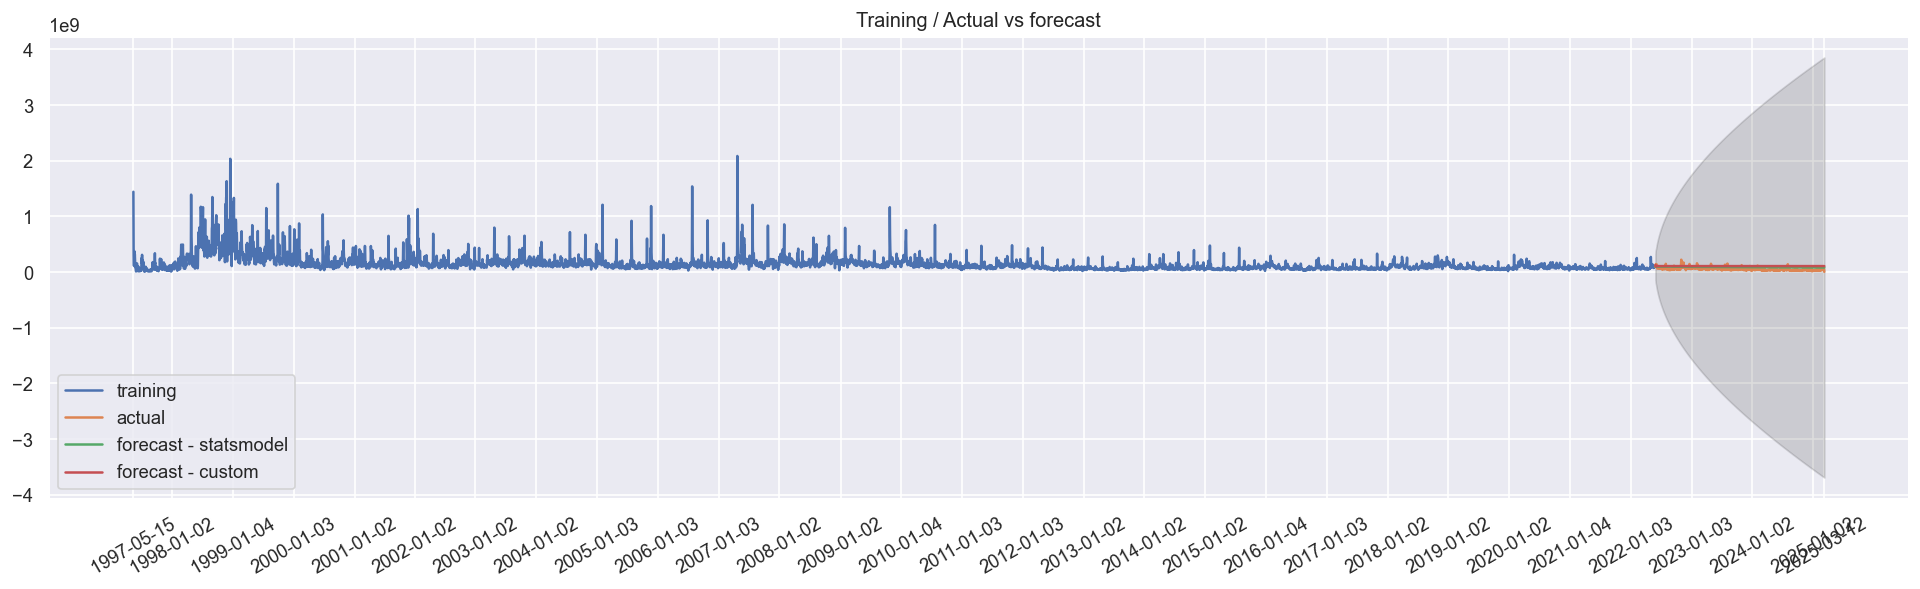

In [72]:
hyperparams = [{
    "order": (1, 1, 2),
    "train_rate": 0.7
},{
    "order": (1, 1, 1),
    "train_rate": 0.7
},{
    "order": (3, 3, 3),
     "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.7
},{
    "order": (4, 1, 3),
    "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.8
},{
    "order": (4, 1, 3),
    "train_rate": 0.8
},{
    "order": (3, 2 ,1),
     "train_rate": 0.9
}]

for dataset_type, dataset in datasets.items():
    date_labels = get_date_labels_amzn(dataset)

    #print(date_labels)
    
    plot_acf(dataset.value, f"Original Dataset -> {dataset_type}")
    print("==================================================================================================")
    for idx, hyperparam in enumerate(hyperparams):
        predicted_dataset = run_arima_train_test(dataset, hyperparam, date_labels)
        print("==================================================================================================")

# Use of generative AI

Please use the cell below to describe your use of generative AI in this assignment.
